# Ground truth for dependence labels — exact effect, dose, demand / storage split and composition

**Where this stands.** `epanet_e5` (v2) established, on both networks: the paired counterfactual is exact; the labels
are robust to design and seed, to time within the final window, to the hydraulic step and to the measurement model;
the study's significance is calibrated at exact zero; the stack's gate is not. Those checks are **not repeated** here
(no probe set, no 900 s step, no hour-average output, no study / stack / probe comparisons).

**What this notebook investigates** (target worlds only, pipeline setting: 3600 s, snapshots):

| section | question | new runs |
|---|---|---|
| **E7 · dose** (D) | Does a sensor's response to k's drift grow with the drift, or appear at the same size for any perturbation (generic sensitivity of pump / tank timing)? | the same drift at λ = `LAMBDAS` of its strength |
| **E2 · split** (X) | How much of each response goes through the hub (pumps, valves, tanks) vs demand transit, and does the study's switch fit get it right? | mediator-blocked twins (M1) on the real drift |
| **E1 · composition** (M) | Whose water passes each sensor — how mixed, how stable, and does it predict dependence? | none (flow-path decomposition of the runs above) |
| labels (L, A, S, T) | Size-free native label (Nr), shape (S), composite (C), dose-filtered shape; floor sensitivity; the target labels | — |
| sanity (P) | What each number means in the pipes (population figures, sensor cards, gallery, widget) | — |

**Changes from `epanet_e5` v2.** Pumps are not sensors: dropped from the placed sensors and from every label table.
The native label is **Nr** = |g_w| relative to the sensor's own-district response (N correlated 0.72–0.80 with link
flow). E2 uses the corrected gate (gain units, final window) and only M1 (M2 has no head reference whenever the
source pumps are closed). Branch checks use the exact downstream district sets. Heatmaps are drawn without
interpolation; undefined cells are grey.

**Runtime.** Per partition: 1 no-drift run, K drift worlds, 2K reduced-dose runs, 1 + 3K blocked twins (≈ 6K + 2
full-horizon runs) plus E1. Switch sections off in the setup cell to split the work.

In [1]:
%matplotlib inline
import warnings, logging, sys, pathlib, json, datetime, time, copy, ctypes, tempfile
from pathlib import Path
from collections import Counter
import numpy as np
import pandas as pd
import networkx as nx
import yaml
import ipywidgets as ipw
from matplotlib.colors import LogNorm, TwoSlopeNorm
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from scipy.stats import mannwhitneyu, spearmanr

REPO = next((p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents]
             if (p / "src" / "fedwater").is_dir()), None)
assert REPO is not None, "run this from inside the fedwater repo"
LAB_DIR = REPO / "notebooks" / "fedwater_lab_refactor"     # adjust to your layout
for p in (REPO / "src", LAB_DIR):
    if str(p) not in sys.path:
        sys.path.insert(0, str(p))
import wntr
from wntr.epanet import toolkit
from wntr.network.io import write_inpfile
from wntr.network.controls import Control, ControlAction
from fedwater.pipelines.network_prep.nodes import configure_network, apply_coupling     # read-only
from fedwater.pipelines.hydraulics.nodes import run_hydraulics, scratch_root, _remove, UNIT_BASE_SI
from fedwater.placement import signal_probe as sp
from fedwater.placement import store
from fedwater.reporting import Atlas

warnings.filterwarnings("ignore")
logging.getLogger("kedro").setLevel(logging.WARNING)
pd.set_option("display.width", 230, "display.max_columns", 60, "display.max_rows", 300)
plt.rcParams.update({"figure.dpi": 90, "font.size": 8})

EXPERIMENTS = None              # None -> <project>/data/09_experiments
STUDY = "ky72" \
"_districting_all_districts"                    # set explicitly per network
ATLAS = Atlas(root=EXPERIMENTS)
WORLDS = ATLAS.worlds(STUDY, ok_only=True).reset_index(drop=True)
BASE = REPO / "notebooks" / "outputs" / STUDY
OUT = BASE / "epanet_gt"
OUT.mkdir(parents=True, exist_ok=True)
SERIES = OUT / "series"
SERIES.mkdir(exist_ok=True)

# sections (the counterfactual pass always runs; each extra costs runs per drifting district)
RUN_DOSE = True                 # E7: the same drift at reduced strength (2 extra runs per world)
RUN_E2 = True                   # E2: demand / storage split on the real drift (3 extra runs per world + 1 per partition)
RUN_E1 = True                   # E1: flow-path composition (no extra runs; ~20 s per window)
SAVE_SERIES = True              # hourly series of the placed sensors (cards)
EXCLUDE_PUMPS = True            # pump links are not sensors: dropped from placed sensors and from every label table

# definitions
LAMBDAS = [0.03, 0.3]           # dose scan: D_lambda = D0 + lambda (D_k - D0), the real drift at reduced strength
BETA_MIN = 0.5                  # dose exponent above which a response is dose-driven (1: proportional, 0: dose-independent)
FLOOR = {"Nr": 0.05,            # native, relative to the sensor's own-district response (size-free)
         "S": 0.25,             # shape effect, sd of the weekly profile
         "C": 0.10}             # composite (kept for comparison)
OWN_MIN = {"N": 1e-3, "S": 0.05}
SWEEP = {"Nr": np.logspace(-3, 0.5, 15), "S": np.logspace(-2, 0.3, 13), "C": np.logspace(-2.5, 0.5, 13)}
M_FLOOR = 0.05                  # composition: a district "uses" a link's water when its share is at least this

# gates
GATE_REPRO = 1e-6               # re-simulated drift worlds vs stored flows (max |dq| / max |q|)
GATE_PRE = 1e-6                 # any run vs the no-drift city before its demand departs
GATE_BRANCH = 1e-3              # branch links: effect = sigma x downstream demand change (gain units)
GATE_E2_GAIN = 1e-3             # blocked twin: |g(twin total) - g(true total)| on the final window
GATE_E1_ROW = 1e-9              # E1: destination shares of every node sum to 1
GATE_E1_BRANCH = 1e-6           # E1: branch composition = downstream demand shares
VALVE_OPEN_SETTING = 1e8
LEVEL_TOL = 1e-3

DW = pd.read_parquet(BASE / "dependence" / "worlds.parquet")                 # target windows (i0, i1, f0, f1)
TOPO = pd.read_parquet(BASE / "dependence" / "topology.parquet")
LBf = pd.read_parquet(BASE / "dependence" / "labels.parquet")
PLC = pd.read_parquet(BASE / "dependence" / "placement.parquet")
SWB = pd.read_parquet(BASE / "dependence" / "switch_b.parquet")
SE = pd.read_parquet(BASE / "dependence_analysis" / "sensor_evidence.parquet")
print(f"study {STUDY}: {len(WORLDS)} ok worlds  ->  {OUT}")

study ky72_districting_all_districts: 12 ok worlds  ->  c:\Users\arthu\USPy\10_Mestrado\fedWater\notebooks\outputs\ky72_districting_all_districts\epanet_gt


### Harness

Same harness as `epanet_sim` v2 / `epanet_e5` v2: the EPANET toolkit step loop (snapshots, completion and
convergence checks) and the blocked twin (`blocked_model`, M1: tanks → fixed-head boundaries following the recorded
head, pipes EPANET closed at a tank limit held closed, pumps / valves / controlled pipes on their recorded status,
speed and setting). Helpers add E1 (`e1_destinations`, verbatim from `epanet_poc`), exact branch composition and the
dose exponent.

In [2]:
EN_ELEV, EN_HEAD, EN_PRESSURE, EN_TANKVOL = 0, 10, 11, 24     # EPANET 2.2 node codes
EN_FLOW, EN_STATUS, EN_SETTING = 8, 11, 12                       # EPANET 2.2 link codes


def build_model(w):
    """The world's simulation model, rebuilt the way the pipeline builds it (network_prep, read-only):
    raw bundle .inp -> configure_network (solver, units, time) -> apply_coupling. Demand is injected later."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def set_horizon(wn, hours, hyd_step=3600):
    # duration only; pattern and report steps stay as configure_network pinned them (1 h)
    wn.options.time.duration = int(hours) * 3600
    wn.options.time.hydraulic_timestep = int(hyd_step)
    return wn


def inject_demand(wn, demand):
    """Verbatim convention of run_hydraulics: base 1 L/s, pattern = the series in L/s; junctions without a
    column are pinned to zero."""
    cols = [c for c in demand.columns if c != "month"]
    for node in cols:
        j = wn.get_node(node)
        wn.add_pattern(f"P{node}", demand[node].to_list())
        j.demand_timeseries_list[0].base_value = UNIT_BASE_SI
        j.demand_timeseries_list[0].pattern_name = f"P{node}"
    for node in set(wn.junction_name_list) - set(cols):
        slot = wn.get_node(node).demand_timeseries_list[0]
        slot.base_value, slot.pattern_name = 0.0, None
    return wn


def mediators(wn):
    # every pump, and every link a control acts on (pumps, level-controlled valves and pipes)
    out = set(wn.pump_name_list)
    for _, c in wn.controls():
        for a in c.actions():
            obj, attr = a.target()
            if attr in ("status", "setting") and getattr(obj, "name", None) in wn.link_name_list:
                out.add(obj.name)
    return sorted(out)


def simulate(wn, demand, hours, hyd_step=3600, pmin_nodes=None, dtype=np.float64):
    """EPANET 2.2 run through the toolkit step loop: every intermediate step of the solve is visited, the
    solution is the one EpanetSimulator computes. Returns, per hour h (t = 3600 h):
      snap   flows at t (what the stored data hold), L/s        avg  time-average over [t, t+1h), L/s
      med_status / med_setting  mediator links at t             on_frac  pumps' time-average open fraction
      tank_head, tank_vol at t; pmin = min pressure at t over pmin_nodes (default: junctions that carry demand —
      a zero-demand node such as a pump suction can sit below zero by design); switches per pump over all steps.
    Every run reports `completed` (the solve reached the horizon) and the EPANET warning codes it met
    (`warnings`: code -> number of solver steps; 1 = unbalanced/unconverged, 2 = disconnected nodes,
    3/4/5 = pumps/valves cannot deliver, 6 = negative pressures). An unconverged step under UNBALANCED STOP
    halts EPANET silently: hours after the halt would read zero, so `completed` must be checked."""
    wn = inject_demand(set_horizon(copy.deepcopy(wn), hours, hyd_step), demand.iloc[:hours])
    links, tanks, pumps = list(wn.link_name_list), list(wn.tank_name_list), list(wn.pump_name_list)
    meds = mediators(wn)
    if pmin_nodes is None:
        dcols = [c for c in demand.columns if c != "month"]
        pmin_nodes = [c for c in dcols if float(np.abs(demand[c].iloc[:hours]).max()) > 0]
    juncs = [j for j in pmin_nodes if j in set(wn.junction_name_list)] or list(wn.junction_name_list)
    d = Path(tempfile.mkdtemp(prefix="fedwater_e024_", dir=scratch_root()))
    t0 = time.time()
    try:
        inp = str(d / "run.inp")
        write_inpfile(wn, inp, units=wn.options.hydraulic.inpfile_units, version=2.2)
        en = toolkit.ENepanet(version=2.2)
        en.ENopen(inp, str(d / "run.rpt"), str(d / "run.bin"))
        li = [en.ENgetlinkindex(x) for x in links]
        pi = [en.ENgetlinkindex(x) for x in pumps]
        mi = [en.ENgetlinkindex(x) for x in meds]
        ti = [en.ENgetnodeindex(x) for x in tanks]
        ji = [en.ENgetnodeindex(x) for x in juncs]
        lib, prj, val = en.ENlib, en._project, ctypes.c_double()
        get_l, get_n = lib.EN_getlinkvalue, lib.EN_getnodevalue

        def lv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_l(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        def nv(idx, code):
            out = np.empty(len(idx))
            for j, i in enumerate(idx):
                get_n(prj, i, code, ctypes.byref(val)); out[j] = val.value
            return out

        L, P, M, T = len(links), len(pumps), len(meds), len(tanks)
        snap, avg = np.zeros((hours, L), dtype), np.zeros((hours, L), dtype)
        acc, acc_h = np.zeros(L), 0                              # float64 accumulator of the current hour
        warn, t_end = Counter(), 0
        run_h, next_h = lib.EN_runH, lib.EN_nextH
        lT, lS = ctypes.c_long(), ctypes.c_long()
        on_frac, mstat, mset = np.zeros((hours, P)), np.zeros((hours, M)), np.zeros((hours, M))
        thead, tvol, pmin = np.zeros((hours, T)), np.zeros((hours + 1, T)), np.zeros(hours)
        switches, last, n_steps = np.zeros(P), None, 0
        en.ENopenH(); en.ENinitH(0)
        while True:
            code = run_h(prj, ctypes.byref(lT))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} at t = {lT.value} s")
            if code:
                warn[int(code)] += 1
            t = int(lT.value)
            t_end = t
            q = lv(li, EN_FLOW)
            st = lv(pi, EN_STATUS) if P else np.zeros(0)
            h = t // 3600
            if t % 3600 == 0 and h <= hours:
                if T:
                    tvol[h] = nv(ti, EN_TANKVOL)
                if h < hours:
                    snap[h] = q
                    if M:
                        mstat[h], mset[h] = lv(mi, EN_STATUS), lv(mi, EN_SETTING)
                    if T:
                        thead[h] = nv(ti, EN_HEAD)
                    pmin[h] = nv(ji, EN_PRESSURE).min()
            if last is not None:
                switches += st != last
            last = st
            code = next_h(prj, ctypes.byref(lS))
            if code >= 100:
                raise RuntimeError(f"EPANET error {code} after t = {t} s")
            dt = int(lS.value)
            if h < hours and dt > 0:
                if h != acc_h:
                    avg[acc_h] = acc / 3600.0
                    acc, acc_h = np.zeros(L), h
                acc += q * dt
                on_frac[h] += st * dt
            n_steps += 1
            if dt <= 0:
                break
        if acc_h < hours:
            avg[acc_h] = acc / 3600.0
        en.ENcloseH(); en.ENclose()
    finally:
        _remove(d)
    return {"links": links, "pumps": pumps, "meds": meds, "tanks": tanks, "snap": snap, "avg": avg,
            "completed": t_end >= hours * 3600, "t_end_h": t_end / 3600.0, "warnings": dict(warn),
            "on_frac": on_frac / 3600.0, "med_status": mstat, "med_setting": mset, "tank_head": thead,
            "tank_vol": tvol, "pmin": pmin, "switches": switches, "n_steps": n_steps,
            "seconds": time.time() - t0}


def tank_inflow(wn, flows, links):
    # net inflow (L/s) of every tank from its incident links' flows (.inp orientation)
    ix = {l: i for i, l in enumerate(links)}
    out = {}
    for t in wn.tank_name_list:
        q = np.zeros(len(flows))
        for ln in wn.get_links_for_node(t):
            s = 1.0 if wn.get_link(ln).end_node_name == t else -1.0
            q += s * flows[:, ix[ln]]
        out[t] = q
    return out


def blocked_model(wn, demand, traj, mode, hours):
    """Mediator-blocked twin of a configured model. All controls are removed; every mediator link follows
    the trajectory `traj` (its status / setting at each hour, as hourly time controls); every tank is replaced:
      M1  by a reservoir whose head follows traj's tank head (fixed-head boundary); where the tank sat at a level
          limit, the incident pipes EPANET had closed stay closed
      M2  by a junction whose demand is traj's tank net inflow (fixed-flow boundary)
    Pumps follow their status and speed, valves their status and setting, controlled pipes their status.
    Without tanks the blocked network holds no state, so each hour is an independent steady state and the
    snapshot at hour h depends only on that hour's demand, boundary and statuses.
    Returns (model, demand frame with the M2 tank columns added, info: hours without a head reference)."""
    d = wntr.network.to_dict(wn)
    d["controls"] = []
    tq = tank_inflow(wn, traj["snap"], traj["links"])
    dem = demand.iloc[:hours].copy()
    nodes = []
    for nd in d["nodes"]:
        if nd["node_type"] != "Tank":
            nodes.append(nd); continue
        t, k = nd["name"], traj["tanks"].index(nd["name"])
        base = {"name": t, "coordinates": nd.get("coordinates")}
        if mode == "M1":
            pat = f"HEAD_{t}"
            d["patterns"].append({"name": pat, "multipliers": list(map(float, traj["tank_head"][:hours, k]))})
            nodes.append({**base, "node_type": "Reservoir", "base_head": 1.0, "head_pattern_name": pat})
        else:
            nodes.append({**base, "node_type": "Junction", "elevation": nd["elevation"],
                          "demand_timeseries_list": [{"base_val": 0.0, "pattern_name": None, "category": None}]})
            dem[t] = tq[t][:hours]
    d["nodes"] = nodes
    wb = wntr.network.from_dict(d)
    ix = {m: i for i, m in enumerate(traj["meds"])}
    LS = wntr.network.LinkStatus
    if mode == "M1":
        # a reservoir has no level limits: where the trajectory's tank sat full or empty, EPANET had closed the
        # tank's links that would overfill / overdraw it; those closures are part of the trajectory, so the
        # incident pipes that carried no flow at such hours are held closed there
        lix = {l: i for i, l in enumerate(traj["links"])}
        for k, t in enumerate(traj["tanks"]):
            tn = wn.get_node(t)
            hd = traj["tank_head"][:hours, k]
            at_lim = (hd >= tn.elevation + tn.max_level - LEVEL_TOL) | (hd <= tn.elevation + tn.min_level + LEVEL_TOL)
            for ln in wn.get_links_for_node(t):
                if ln in ix:
                    continue                                   # mediator links follow their own trajectory
                shut = at_lim & (np.abs(traj["snap"][:hours, lix[ln]]) < 1e-6)
                if not shut.any():
                    continue
                lk = wb.get_link(ln)
                if shut[0]:
                    lk.initial_status = LS.Closed
                for h in range(1, hours):
                    if shut[h] != shut[h - 1]:
                        act = ControlAction(lk, "status", LS.Closed if shut[h] else LS.Open)
                        wb.add_control(f"lim_{ln}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
    for m in traj["meds"]:
        lk, s, z = wb.get_link(m), traj["med_status"][:hours, ix[m]], traj["med_setting"][:hours, ix[m]]
        kind = "pump" if m in wb.pump_name_list else "valve" if m in wb.valve_name_list else "pipe"

        # state per hour: 'closed' | 'open' | ('speed', s) for pumps | ('active', setting) for valves
        # (a valve fixed open reports no setting, i.e. a huge value)
        def state(h):
            if s[h] < 0.5:
                return "closed"
            if kind == "pump":
                return ("speed", round(float(z[h]), 6))
            if kind == "valve" and abs(z[h]) < VALVE_OPEN_SETTING:
                return ("active", float(z[h]))
            return "open"
        prev = state(0)
        if prev == "closed":
            lk.initial_status = LS.Closed
        elif prev == "open":
            lk.initial_status = LS.Open
        elif prev[0] == "speed":
            lk.initial_status, lk.initial_setting = LS.Open, prev[1]
        else:
            lk.initial_status, lk.initial_setting = LS.Active, prev[1]
        for h in range(1, hours):
            cur = state(h)
            if cur == prev:
                continue
            if cur == "closed":
                act = ControlAction(lk, "status", LS.Closed)
            elif cur == "open":
                act = ControlAction(lk, "status", LS.Open)
            elif cur[0] == "speed":
                act = ControlAction(lk, "base_speed", cur[1])     # a speed > 0 also opens the pump
            else:
                act = ControlAction(lk, "setting", cur[1])
            wb.add_control(f"blk_{m}_{h}", Control._time_control(wb, h * 3600, "SIM_TIME", False, act))
            prev = cur
    info = {"ill_posed_hours": head_reference_gaps(wb, traj, hours)}
    return wb, dem, info


def head_reference_gaps(wb, traj, hours):
    """Hours at which some junction of the blocked network has no open path to a fixed-head node (reservoir).
    A demand-driven solve is singular there: M2 (tanks -> fixed-flow junctions) loses its head reference
    whenever the links that connect the network to a reservoir are closed. Mediator links closed at the hour
    are removed; every other link counts as open (a check valve shut by reverse flow is not seen, so gaps can
    only be under-counted)."""
    ix = {m: i for i, m in enumerate(traj["meds"])}
    fixed, juncs = set(wb.reservoir_name_list), set(wb.junction_name_list)
    edges = [(wb.get_link(l).start_node_name, wb.get_link(l).end_node_name, l) for l in wb.link_name_list]
    always = [(u, v) for u, v, l in edges if l not in ix]
    med_e = [(u, v, ix[l]) for u, v, l in edges if l in ix]
    st = traj["med_status"][:hours] > 0.5
    gaps, cache = 0, {}
    for h in range(hours):
        key = st[h].tobytes()
        if key not in cache:
            G = nx.Graph()
            G.add_nodes_from(wb.node_name_list)
            G.add_edges_from(always)
            G.add_edges_from([(u, v) for u, v, k in med_e if st[h, k]])
            cache[key] = any((comp & juncs) and not (comp & fixed) for comp in map(set, nx.connected_components(G)))
        gaps += int(cache[key])
    return gaps

In [3]:
RUNLOG = []                                                        # every simulation of this notebook


def log_run(r, **meta):
    """Record a run's integrity (reached the horizon? unconverged steps?) and pass it through."""
    w = r.get("warnings", {})
    RUNLOG.append({**meta, "completed": bool(r["completed"]), "t_end_h": r["t_end_h"], "n_steps": r["n_steps"],
                   "unbalanced_steps": int(w.get(1, 0)), "warnings": json.dumps({str(k): v for k, v in w.items()}),
                   "seconds": round(r["seconds"], 1)})
    return r


def run_gate(section):
    """G-run: every simulation of `section` reached its horizon with no unconverged step."""
    rl = pd.DataFrame([x for x in RUNLOG if x.get("section") == section])
    if not len(rl):
        return {"gate": f"G-run {section}: completed, converged", "value": "no runs", "passed": False}
    bad = rl[~rl["completed"] | (rl["unbalanced_steps"] > 0)]
    return {"gate": f"G-run {section}: completed, converged", "value": f"{len(bad)} / {len(rl)} runs failing",
            "passed": bool(len(bad) == 0)}


def pump_on(q):
    # as dependence_compute: a pump is on when |q| exceeds 1e-6 of its largest |q| in the series
    q = np.asarray(q, float)
    return np.abs(q) > 1e-6 * max(np.abs(q).max(), 1e-12)


def link_table(wn):
    rows = [(ln, wn.get_link(ln).start_node_name, wn.get_link(ln).end_node_name, type(wn.get_link(ln)).__name__)
            for ln in wn.link_name_list]
    return pd.DataFrame(rows, columns=["link", "start", "end", "link_type"]).set_index("link")


def branch_downstream(wn, LT):
    # exact downstream junction sets of bridge links whose downstream side has no source (as in epanet_poc)
    G = nx.Graph()
    for ln, r in LT.iterrows():
        G.add_edge(r["start"], r["end"])
    pairs = Counter(frozenset((r["start"], r["end"])) for _, r in LT.iterrows())
    sources = set(wn.tank_name_list) | set(wn.reservoir_name_list)
    out = {}
    for u, v in nx.bridges(G):
        e = frozenset((u, v))
        if pairs[e] > 1:
            continue
        G.remove_edge(u, v)
        cu = nx.node_connected_component(G, u)
        G.add_edge(u, v)
        cv = set(G.nodes) - cu
        su, sv = bool(cu & sources), bool(cv & sources)
        if su != sv:
            dn = cv if su else cu
            for ln, r in LT.iterrows():
                if frozenset((r["start"], r["end"])) == e:
                    out[ln] = dn
    return out


def orient_of(Q):
    # sign of each column's mean flow; a zero mean counts as +1
    s = np.sign(np.asarray(Q, float).mean(axis=0))
    return np.where(s == 0, 1.0, s)


def gains_of(dQ, dD, sd, step0):
    """Exact paired gains of every column of dQ (T x L) on the drifting district's demand change dD (T):
    hourly  g_h = <dQ, dD> / ||dD||^2 ;  weekly profile  g_w = <P dQ, P dD> / ||P dD||^2 (the study's gain,
    with the paired difference in place of settled - init) ;  r2_t = 1 - ||dQ - g_h dD||^2 / ||dQ||^2
    (how much of the response is proportional to dD hour by hour). Unoriented (.inp sign)."""
    dQ, dD = np.asarray(dQ, float), np.asarray(dD, float)
    nD = float(dD @ dD)
    g_h = dQ.T @ dD / nD
    res = ((dQ - np.outer(dD, g_h)) ** 2).sum(axis=0)
    tot = (dQ ** 2).sum(axis=0)
    r2_t = np.where(tot > 1e-18, 1.0 - res / np.where(tot > 1e-18, tot, 1.0), np.nan)
    PQ = np.atleast_2d(sp.weekly_profile(dQ, sd, step0=step0))         # (L, 7 sd)
    PD = sp.weekly_profile(dD, sd, step0=step0)                         # (7 sd,)
    g_w = PQ @ PD / float(PD @ PD)
    return g_h, g_w, r2_t


def auc(pos, neg):
    pos, neg = np.asarray(pos, float), np.asarray(neg, float)
    pos, neg = pos[np.isfinite(pos)], neg[np.isfinite(neg)]
    return mannwhitneyu(pos, neg, alternative="two-sided").statistic / (len(pos) * len(neg)) \
        if len(pos) and len(neg) else np.nan


def spear(a, b):
    a, b = np.asarray(a, float), np.asarray(b, float)
    ok = np.isfinite(a) & np.isfinite(b)
    return spearmanr(a[ok], b[ok]).correlation if ok.sum() > 3 else np.nan


def rel_dev(A, B, floor_frac=None):
    """Per column: max |A - B| / max |B| (floor_frac None) or / mean |B| for columns whose mean |B| is above
    floor_frac x the median column mean (others NaN)."""
    d = np.abs(np.asarray(A, float) - np.asarray(B, float)).max(axis=0)
    if floor_frac is None:
        return d / np.maximum(np.abs(B).max(axis=0), 1e-12)
    m = np.abs(B).mean(axis=0)
    keep = m >= floor_frac * np.median(m[m > 0]) if (m > 0).any() else m > 0
    return np.where(keep, d / np.where(keep, m, 1.0), np.nan)


def home_of(m):
    l = LBf[LBf["districting"] == m].drop_duplicates("element")
    return pd.Series(l["home"].to_numpy(), index=l["element"].astype(str))


def storage_of(m):
    s = SE[SE["districting"] == m].drop_duplicates("element")
    return pd.Series(s["storage"].to_numpy(), index=s["element"].astype(str))


def profile(X, sd, lo):
    # weekly profile of every column of X (T x L) -> (L, 7 sd); a 1-D series -> (1, 7 sd)
    X = np.asarray(X, float)
    return np.atleast_2d(sp.weekly_profile(X if X.ndim > 1 else X[:, None], sd, step0=lo))


def zrows(A):
    # as dependence_compute: each row z-scored; constant rows -> NaN
    s = A.std(axis=1, keepdims=True)
    return (A - A.mean(axis=1, keepdims=True)) / np.where(s > 1e-12, s, np.nan)


def effect(Q1, Q0, D1k, D0k, sd, lo, orient):
    """Exact paired effect of the drift on every link, on one window (rows = hours of the window).
    Label metrics:
      g_w   native projection gain   <P dQ, P dD> / ||P dD||^2 (oriented)   extra L/s through the link per extra L/s
                                      of k's demand, in the part of the response that follows k's weekly pattern
      SE    shape effect             rms over the week of z(P Q1) - z(P Q0)  how far the weekly shape a client sees
                                      after per-client scaling moves, in standard deviations
    Diagnostics: RE = mean|dQ| / mean|Q0| (hour-level change, includes switching reshuffles); MG mean gain;
      r2_t = share of the hourly response proportional to dD; sys_share = mean_h |P Q1 - P Q0| / mean_t |dQ|
      (1: the change repeats every week, ~0: it averages out over weeks); amplitude ratio; exact shape gain."""
    Q1, Q0 = np.asarray(Q1, float), np.asarray(Q0, float)
    dQ, dD = Q1 - Q0, np.asarray(D1k, float) - np.asarray(D0k, float)
    L = dQ.shape[1]
    mq, mdq = np.abs(Q0).mean(axis=0), np.abs(dQ).mean(axis=0)
    nan = np.full(L, np.nan)
    if float(dD @ dD) < 1e-18:                                 # no drift in this window: the effect is exactly zero
        z = np.where(mdq > 0, np.nan, 0.0)                      # exactly 0 where nothing changed, else undefined
        return {"RE": mdq / np.where(mq > 0, mq, np.nan), "MG": nan, "SE": np.where(mdq > 0, np.nan, 0.0),
                "g_h": z, "g_w": z, "g_w_raw": z, "r2_t": nan, "amp": nan, "g_shape": nan, "sys_share": nan,
                "mean_abs_flow": mq, "orient": orient}
    mdd, md0 = float(dD.mean()), float(np.abs(D0k).mean())
    RE = mdq / np.where(mq > 0, mq, np.nan)
    MG = orient * dQ.mean(axis=0) / mdd if abs(mdd) >= 0.01 * md0 else nan
    P1, P0 = profile(Q1, sd, lo), profile(Q0, sd, lo)
    Z = zrows(P1) - zrows(P0)
    SE = np.sqrt(np.nanmean(Z ** 2, axis=1))
    SE = np.where(np.isnan(SE) & (mdq == 0), 0.0, SE)
    sys_share = np.abs(P1 - P0).mean(axis=1) / np.where(mdq > 0, mdq, np.nan)
    g_h, g_w, r2t = gains_of(dQ, dD, sd, lo)
    amp = np.sqrt((dQ ** 2).sum(axis=0)) / max(np.sqrt(float(dD @ dD)), 1e-12)
    dz = zrows(profile(D1k, sd, lo)) - zrows(profile(D0k, sd, lo))
    nz = float(np.nansum(dz ** 2))
    g_shape = (np.nan_to_num(Z) @ np.nan_to_num(dz).T)[:, 0] / nz if nz > 1e-12 else nan
    return {"RE": RE, "MG": MG, "SE": SE, "g_h": g_h * orient, "g_w": g_w * orient, "g_w_raw": g_w,
            "r2_t": r2t, "amp": amp, "g_shape": g_shape * orient, "sys_share": sys_share, "mean_abs_flow": mq,
            "orient": orient}


def monthly(Q1, Q0, D1k, D0k, sd, sm, orient, links):
    """The label metrics month by month over the whole horizon (rows: months x links)."""
    out = []
    for mo in range(len(Q0) // sm):
        a, b = mo * sm, (mo + 1) * sm
        ef = effect(Q1[a:b], Q0[a:b], D1k[a:b], D0k[a:b], sd, a, orient)
        out.append(pd.DataFrame({"element": links, "month": mo, "g_w": ef["g_w"], "SE": ef["SE"], "RE": ef["RE"],
                                 "dD_mean": float((np.asarray(D1k[a:b]) - np.asarray(D0k[a:b])).mean())}))
    return pd.concat(out, ignore_index=True)


def study_basis(Qk, Q0, Dk, wI, wF, sd):
    """The study's settled - init gain, recomputed, and split exactly in two with the counterfactual:
    g_tot = <P_F Qk - P_I Qk, dD> / ||dD||^2 = g_effect + g_noise, with g_noise the same quantity on the
    no-drift world (what the drift-free city does between the two windows) and g_effect the drift's part.
    Shape: the study's z-scored version on Qk (g_shape_rec) and on Q0 (g_shape_noise); not additive."""
    (i0, i1), (f0, f1) = wI, wF
    dI, dF = profile(Dk[i0:i1], sd, i0), profile(Dk[f0:f1], sd, f0)
    dDn = dF - dI
    nD = float((dDn ** 2).sum())
    dz = zrows(dF) - zrows(dI)
    nz = float((dz ** 2).sum())
    out = {}
    for tag, Q in (("rec", Qk), ("noise", Q0)):
        pI, pF = profile(Q[i0:i1], sd, i0), profile(Q[f0:f1], sd, f0)
        out[f"g_{tag}"] = ((pF - pI) @ dDn.T)[:, 0] / nD
        out[f"g_shape_{tag}"] = ((zrows(pF) - zrows(pI)) @ dz.T)[:, 0] / nz
    out["g_effect"] = out["g_rec"] - out["g_noise"]
    return out


# ---- E1: flow-path composition (verbatim from epanet_poc, validated there) ----------------------------------
def e1_destinations(F, Dm, LT, districts, node2d, tanks, reservoirs, hours, sd=24, eps=1e-9):
    """Flow-path destination decomposition (complete mixing at nodes, as EPANET's water quality model).

    Each hour: water leaving node n ends in a junction demand of district k, in a FILLING tank
    ("storage:<T>"), in a reservoir it flows back into ("reservoir:<R>"), or — where the hydraulic solution
    does not balance a node to solver precision — in "unaccounted" (the excess inflow of that node), so the
    accounting always closes and the solver imbalance is measured instead of silently losing water. With phi_n the destination shares of n's water and O_n its total outflow (edges + demand
    + tank sink):  O_n phi_n = demand_n e_{district(n)} + sink_n e_{storage(n)} + sum_{n->v} q phi_v.
    A link carries the shares of its downstream node. Solved as a sparse linear system (handles any flow
    pattern, not only acyclic ones). Accumulated flow-weighted over the given hours, overall and per
    hour-of-week. Returns (shares L x K, volume L, how_shares L x 7sd x K, row-sum deviation per hour).
    """
    from scipy.sparse import csr_matrix, diags
    from scipy.sparse.linalg import splu
    cols = [c for c in F.columns if c in LT.index]
    nodes = sorted(set(LT.loc[cols, "start"]) | set(LT.loc[cols, "end"]))
    ix = {n: i for i, n in enumerate(nodes)}
    dests = list(districts) + [f"storage:{t}" for t in tanks] + [f"reservoir:{r}" for r in reservoirs] + ["unaccounted"]
    di = {d: i for i, d in enumerate(dests)}
    st = LT.loc[cols, "start"].map(ix).to_numpy()
    en = LT.loc[cols, "end"].map(ix).to_numpy()
    jcols = [n for n in Dm.columns if n in ix]
    jidx = np.array([ix[n] for n in jcols])
    jdst = np.array([di.get(node2d.get(n), -1) for n in jcols])
    tix = [(ix[t], di[f"storage:{t}"]) for t in tanks if t in ix]
    rix = [(ix[r], di[f"reservoir:{r}"]) for r in reservoirs if r in ix]
    special = set(i for i, _ in tix) | set(i for i, _ in rix)
    junc_like = np.array([i not in special for i in range(len(nodes))])
    k_un = di["unaccounted"]
    N, K, L = len(nodes), len(dests), len(cols)
    Fv, Dv = F[cols].to_numpy(float), Dm[jcols].to_numpy(float)
    P = 7 * sd
    acc, vol = np.zeros((L, K)), np.zeros(L)
    acc_h, vol_h = np.zeros((L, P, K)), np.zeros((L, P))
    dev = []
    for t in hours:
        f, d = Fv[t], Dv[t]
        act = np.abs(f) > eps
        fwd = f > 0
        u = np.where(fwd, st, en)[act]
        v = np.where(fwd, en, st)[act]
        q = np.abs(f)[act]
        O = np.zeros(N)
        np.add.at(O, u, q)
        qin = np.zeros(N)
        np.add.at(qin, v, q)
        S = np.zeros((N, K))
        dn = np.zeros(N)
        dn[jidx] = d
        ok = jdst >= 0
        S[jidx[ok], jdst[ok]] += d[ok]
        O += dn
        for ti, tk in tix + rix:                                # a filling tank / receiving reservoir keeps water
            sink = max(qin[ti] - (O[ti] - dn[ti]), 0.0)
            S[ti, tk] += sink
            O[ti] += sink
        excess = np.where(junc_like, np.clip(qin - O, 0.0, None), 0.0)   # inflow a junction does not pass on
        S[:, k_un] += excess
        O += excess
        dead = O <= eps
        # a dead node (no outflow, no demand) has no outgoing edges, so its row is empty: diagonal 1, phi = 0
        A = diags(np.where(dead, 1.0, O)) - csr_matrix((q, (u, v)), shape=(N, N))
        Phi = splu(A.tocsc()).solve(S)                          # N x K
        rs = Phi.sum(axis=1)[~dead]
        dev.append(float(np.max(np.abs(rs - 1.0))) if len(rs) else 0.0)
        li = np.where(act)[0]
        contrib = q[:, None] * Phi[v]
        acc[li] += contrib
        vol[li] += q
        h = t % P
        acc_h[li, h] += contrib
        vol_h[li, h] += q
    with np.errstate(invalid="ignore", divide="ignore"):
        shares = acc / vol[:, None]
        how = acc_h / vol_h[:, :, None]
    return (pd.DataFrame(shares, index=cols, columns=dests), pd.Series(vol, index=cols),
            how, np.array(dev), dests)



def branch_shares(D, cols_by_dist, down, hours):
    """Exact composition of a branch link: its water is exactly the demand downstream, so its share of
    district d is sum_t sum_{n in down, n in d} D_n(t) / sum_t sum_{n in down} D_n(t)."""
    out = {}
    tot = 0.0
    for d, cols in cols_by_dist.items():
        c = [n for n in cols if n in down]
        out[d] = float(D[c].iloc[hours].to_numpy(float).sum()) if c else 0.0
        tot += out[d]
    return {d: v / tot for d, v in out.items()} if tot > 0 else {d: np.nan for d in out}


def dose_exponent(lams, amps):
    """Slope of log(response amplitude) on log(dose): 1 = proportional to the drift, 0 = the same response
    whatever the drift's size (a perturbation-triggered response). NaN when the response is zero."""
    x, y = np.log(np.asarray(lams, float)), np.asarray(amps, float)
    ok = y > 0
    if ok.sum() < 2:
        return np.nan
    return float(np.polyfit(x[ok], np.log(y[ok]), 1)[0])

### Definitions and gates

On the final window (the study's settled window), with $\Delta Q_s=Q^{(k)}_s-Q^{(0)}_s$ and $P$ the weekly profile:

| quantity | definition | reads as |
|---|---|---|
| **Nr** | $\lvert g_w\rvert_{s,k}/\lvert g_w\rvert_{s,j}$, $g_w=\langle P\Delta Q_s,P\Delta D_k\rangle/\lVert P\Delta D_k\rVert^2$, $j$ = own district | k moves this sensor natively Nr times as much as its own district does (size-free) |
| **S** | $\mathrm{rms}_h[z(PQ^{(k)}_s)-z(PQ^{(0)}_s)]$ | the weekly shape a client sees moves by S sd |
| **C** | $\sqrt{N_r\,S_r}$ | both together, relative to own (kept for comparison) |
| **β** (E7) | slope of $\log A(\lambda)$ on $\log\lambda$, $A=\mathrm{rms}_t\,\Delta Q_s$, runs with $D_\lambda=D^{(0)}+\lambda(D^{(k)}-D^{(0)})$, λ ∈ {`LAMBDAS`, 1} | 1: the response grows with the drift; 0: the same response at any drift size |
| **storage share** (E2) | $\lvert g_{ie0}\rvert/(\lvert g_{de0}\rvert+\lvert g_{ie0}\rvert)$, $g_{de0}$ = gain of $B(D^{(k)},\text{traj}_0)-B(D^{(0)},\text{traj}_0)$ | part of the response that needs the hub to react |
| **S with hub held** (E2) | S of $B(D^{(k)},\text{traj}_0)$ vs $B(D^{(0)},\text{traj}_0)$ | shape effect from demand transit alone |
| **m_k** (E1) | share of k's demand in the water passing the sensor (no-drift city, init window, flow-weighted) | how much of k's water the sensor carries |
| **Δm_k** (E1) | $m_k$(drift world) − $m_k$(no-drift), final window | how k's drift changes whose water passes |

| gate | rule |
|---|---|
| G-E5a/b/c/d, G-run | splice exact; re-simulation = stored; identical before the drift; branch physics (as in `epanet_e5`) |
| G-E7a / b | reduced-dose runs identical before the drift; branches respond exactly λ × the full effect |
| G-E2a | twin total = true total, $\lvert g(B(D^{(k)},\text{traj}_k)-B(D^{(0)},\text{traj}_0))-g(Q^{(k)}-Q^{(0)})\rvert\le10^{-3}$ |
| G-E2c / h | no storage channel on branches; every hour has a head reference |
| G-E1a / b | destination shares sum to 1 at every node; branch composition = exact downstream demand shares |

In [4]:
def build_model(w):
    """The target world's model, rebuilt as the pipeline builds it (validated by epanet_sim's E0)."""
    wn = copy.deepcopy(w.network_model)
    wn, _ = configure_network(wn, {"name": w.row["network"]}, w.params["hydraulics"], w.params["time"])
    wn, _ = apply_coupling(wn, w.catalog.load("districts"), w.params["coupling"], w.params["seed"])
    return wn


def _cols(df):
    df.columns = [c if c == "month" else str(c) for c in df.columns]
    return df.reset_index(drop=True)


def load_target(m, g):
    """The study's worlds of partition m: demand, stored flows, model and the study's windows."""
    out = []
    dwx = DW.set_index("world")
    for _, r in g.iterrows():
        w = ATLAS.world(r["sim_hash"])
        h8 = r["sim_hash"][:8]
        out.append({"k": r["drift_district"], "id": h8, "D": _cols(w.catalog.load("demand_series")),
                    "F": _cols(w.catalog.load("flows")), "wn": build_model(w),
                    "wI": (int(dwx.at[h8, "i0"]), int(dwx.at[h8, "i1"])),
                    "wF": (int(dwx.at[h8, "f0"]), int(dwx.at[h8, "f1"]))})
    dy = ATLAS.world(g.iloc[0]["sim_hash"]).catalog.load("districts")
    return out, dy, 24 // int(ATLAS.world(g.iloc[0]["sim_hash"]).params["time"].get("resolution_h", 1))


def splice(worlds, names, node2d):
    """No-drift demand: each district's columns from a world in which it does not drift. G-E5a: every world
    in which district d does not drift carries the same d-columns, and columns outside every district are the
    same in all worlds (the demand generator is keyed by seed, month and node)."""
    D0 = worlds[0]["D"].copy()
    rows = []
    cols = [c for c in D0.columns if c != "month"]
    other = [c for c in cols if c not in node2d]
    for d in names:
        dc = [c for c in cols if node2d.get(c) == d]
        donors = [x for x in worlds if x["k"] != d]
        ref = donors[0]["D"][dc].to_numpy(float)
        diff = max((float(np.abs(x["D"][dc].to_numpy(float) - ref).max()) for x in donors[1:]), default=0.0)
        rows.append({"district": d, "columns": len(dc), "donors": len(donors), "max |diff| between donors": diff})
        D0[dc] = donors[0]["D"][dc].to_numpy()
    if other:
        diff = max(float(np.abs(x["D"][other].to_numpy(float) - D0[other].to_numpy(float)).max()) for x in worlds)
        rows.append({"district": "(no district)", "columns": len(other), "donors": len(worlds),
                     "max |diff| between donors": diff})
    return D0, rows

In [5]:
REC = {k: [] for k in ("link", "month", "gate", "splice", "branch", "dose", "dose_gate", "e2", "e2_gate", "e1",
                       "e1_gate", "carries", "mediators")}
PERIOD_OF, PUMPS, PLACED, issues = {}, {}, {}, []
_t0 = time.time()
for m, g in WORLDS.groupby("districting"):
    try:
        worlds, dy, sd = load_target(m, g)
        names = list(dy["districts"])
        node2d = {str(n): d for d, ns in dy["districts"].items() for n in ns}
        if sorted(x["k"] for x in worlds) != sorted(names):
            raise ValueError(f"expected one world per district, got {[x['k'] for x in worlds]}")
        H = len(worlds[0]["D"])
        D0, srows = splice(worlds, names, node2d)
        REC["splice"] += [{**r, "districting": m} for r in srows]
        if max(r["max |diff| between donors"] for r in srows) > 0.0:
            raise ValueError("G-E5a: non-drifting demand differs between worlds — no exact counterfactual")
        wn0 = worlds[0]["wn"]
        sm = sd * int(ATLAS.world(g.iloc[0]["sim_hash"]).params["time"]["days_per_month"])
        kc = {d: [c for c in D0.columns if node2d.get(c) == d] for d in names}
        LT = link_table(wn0)
        DOWN = branch_downstream(wn0, LT)
        PUMPS[m] = list(wn0.pump_name_list)
        placed = sorted(set(PLC[PLC["districting"] == m]["element"].astype(str)))
        PLACED[m] = [e for e in placed if not (EXCLUDE_PUMPS and e in PUMPS[m])]
        jcols = [c for c in D0.columns if c != "month"]
        tanks, resv = list(wn0.tank_name_list), list(wn0.reservoir_name_list)
        # which branch carries which district's water (exact): the physics truth for every branch check
        for l, dn in DOWN.items():
            for d in names:
                REC["carries"].append({"districting": m, "element": l, "k": d, "carries": any(c in dn for c in kc[d])})

        r0 = log_run(simulate(wn0, D0, H, dtype=np.float32), section="pass", districting=m, run="no-drift")
        links = r0["links"]
        lix = {l: j for j, l in enumerate(links)}
        br = [l for l in links if l in DOWN]
        sig = np.array([1.0 if LT.at[l, "end"] in DOWN[l] else -1.0 for l in br])
        keep = [l for l in PLACED[m] if l in lix]
        kix = [lix[l] for l in keep]
        F0 = pd.DataFrame(r0["snap"], columns=links)
        if SAVE_SERIES:
            np.savez_compressed(SERIES / f"{m}__nodrift.npz", links=np.array(keep), pumps=np.array(PUMPS[m]),
                                Q=r0["snap"][:, kix], U=np.stack([pump_on(r0["snap"][:, lix[p]]) for p in PUMPS[m]], 1)
                                if PUMPS[m] else np.zeros((H, 0)),
                                **{f"D_{d}": D0[kc[d]].sum(axis=1).to_numpy(np.float32) for d in names})
        if RUN_E1:                                     # composition of the no-drift city, init window (shared)
            i0, i1 = worlds[0]["wI"]
            sh, vol, how, dev, dests = e1_destinations(F0, D0[jcols], LT, names, node2d, tanks, resv, range(i0, i1), sd)
            REC["e1"].append(sh.assign(volume=vol).reset_index(names="element").assign(
                districting=m, world="no-drift", k=None, window="init"))
            REC["e1_gate"].append({"districting": m, "world": "no-drift", "k": None, "window": "init",
                                   "max row deviation": float(np.max(dev)) if len(dev) else 0.0,
                                   "max unaccounted share": float(np.nanmax(sh["unaccounted"].where(
                                       vol >= 1e-3 * np.median(vol[vol > 0]))))})
            for l in br:                               # E1 branch composition vs exact downstream shares
                ex = branch_shares(D0, kc, DOWN[l], range(i0, i1))
                if np.isfinite(list(ex.values())).all() and l in sh.index:
                    dsum = float(sh.loc[l, names].sum())
                    REC["e1_gate"].append({"districting": m, "world": "no-drift", "window": "init", "branch": l,
                                           "branch max |m - exact|": max(abs(sh.loc[l, d] / dsum - ex[d]) for d in names)
                                           if dsum > 0 else np.nan})
            if SAVE_SERIES:
                np.savez_compressed(SERIES / f"{m}__e1_nodrift_init.npz", links=np.array(keep), dests=np.array(dests),
                                    how=how[[list(sh.index).index(l) for l in keep]] if keep else np.zeros((0, 7 * sd, len(dests))))
        if RUN_E2:
            wb, dem, info0 = blocked_model(wn0, D0, r0, "M1", H)
            b00 = log_run(simulate(wb, dem, H, pmin_nodes=jcols, dtype=np.float32), section="E2", districting=m,
                          run="blocked(0, traj0)")
            ixb = [b00["links"].index(l) for l in links]
            for j_, md in enumerate(r0["meds"]):
                st_ = r0["med_status"][:, j_]
                REC["mediators"].append({"districting": m, "mediator": md, "status_changes": int(np.diff(st_ > 0.5).sum()),
                                         "open_frac": float((st_ > 0.5).mean())})
            idel = LBf[LBf["districting"] == m].drop_duplicates("id").set_index("id")["element"].astype(str)
            sb = SWB[SWB["districting"] == m].drop_duplicates(["id", "pump"]).copy()
            sb["element"] = sb["id"].map(idel)
            Bm = sb.pivot_table(index="element", columns="pump", values="b").reindex(links)

        for wd in worlds:
            k, (i0, i1), (f0, f1) = wd["k"], wd["wI"], wd["wF"]
            periods = {"init": (i0, i1), "transition": (i1, f0), "final": (f0, f1)}
            PERIOD_OF[(m, k)] = periods
            rk = log_run(simulate(wd["wn"], wd["D"], H, dtype=np.float32), section="pass", districting=m, run=k)
            Fs = wd["F"][links].to_numpy(float)[:H]
            dif = np.abs(wd["D"][kc[k]].to_numpy(float) - D0[kc[k]].to_numpy(float)).max(axis=1)
            t_div = int(np.argmax(dif > 0)) if (dif > 0).any() else H
            pre = rel_dev(rk["snap"][:t_div].astype(float), r0["snap"][:t_div].astype(float)) if t_div else np.zeros(1)
            REC["gate"].append({"districting": m, "k": k, "repro max rel": float(np.nanmax(rel_dev(rk["snap"].astype(float), Fs))),
                                "drift starts (h)": t_div, "pre-drift max rel": float(np.nanmax(pre)),
                                "final window": f"{f0}-{f1}"})
            D1k, D0k = wd["D"][kc[k]].sum(axis=1).to_numpy(float), D0[kc[k]].sum(axis=1).to_numpy(float)
            orient = orient_of(r0["snap"][f0:f1].astype(float))
            for per, (a, b) in periods.items():
                if b - a >= 7 * sd:
                    ef = effect(rk["snap"][a:b], r0["snap"][a:b], D1k[a:b], D0k[a:b], sd, a, orient)
                    REC["link"].append(pd.DataFrame({"element": links, **ef}).assign(districting=m, k=k, period=per))
            dK = (wd["D"][kc[k]].to_numpy(float) - D0[kc[k]].to_numpy(float))[f0:f1]
            dd = D1k[f0:f1] - D0k[f0:f1]
            if br:
                Bk = np.array([[1.0 if c in DOWN[l] else 0.0 for c in kc[k]] for l in br])
                exp_ = (dK @ Bk.T) * sig
                got = (rk["snap"][f0:f1] - r0["snap"][f0:f1])[:, [lix[l] for l in br]].astype(float)
                REC["branch"].append(pd.DataFrame({"element": br, "g_exact": exp_.T @ dd / float(dd @ dd),
                                                   "g_sim": got.T @ dd / float(dd @ dd)}).assign(districting=m, k=k))
            REC["month"].append(monthly(rk["snap"], r0["snap"], D1k, D0k, sd, sm, orient, links).assign(districting=m, k=k))
            amp1 = np.sqrt(((rk["snap"][f0:f1].astype(float) - r0["snap"][f0:f1]) ** 2).mean(axis=0))
            if SAVE_SERIES:
                np.savez_compressed(SERIES / f"{m}__{k}.npz", links=np.array(keep), pumps=np.array(PUMPS[m]),
                                    Q=rk["snap"][:, kix], U=np.stack([pump_on(rk["snap"][:, lix[p]]) for p in PUMPS[m]], 1)
                                    if PUMPS[m] else np.zeros((H, 0)), D=D1k.astype(np.float32),
                                    periods=np.array([i0, i1, f0, f1]), sm=np.array(sm), sd=np.array(sd))

            # ---- E7: the same drift at reduced strength ----------------------------------------------------
            if RUN_DOSE:
                amps, dser = {1.0: amp1}, {}
                for lam in LAMBDAS:
                    Dl = D0.copy()
                    Dl[kc[k]] = D0[kc[k]].to_numpy(float) + lam * (wd["D"][kc[k]].to_numpy(float) - D0[kc[k]].to_numpy(float))
                    rl = log_run(simulate(wn0, Dl, H, dtype=np.float32), section="E7", districting=m, run=f"{k} x{lam}")
                    D1l = Dl[kc[k]].sum(axis=1).to_numpy(float)
                    ef = effect(rl["snap"][f0:f1], r0["snap"][f0:f1], D1l[f0:f1], D0k[f0:f1], sd, f0, orient)
                    amps[lam] = np.sqrt(((rl["snap"][f0:f1].astype(float) - r0["snap"][f0:f1]) ** 2).mean(axis=0))
                    REC["dose"].append(pd.DataFrame({"element": links, "lam": lam, "amp": amps[lam], "g_w": ef["g_w"],
                                                     "SE": ef["SE"], "r2_t": ef["r2_t"]}).assign(districting=m, k=k))
                    pre_l = rel_dev(rl["snap"][:t_div].astype(float), r0["snap"][:t_div].astype(float)) if t_div else np.zeros(1)
                    gb = np.nan
                    if br:
                        gl = (rl["snap"][f0:f1] - r0["snap"][f0:f1])[:, [lix[l] for l in br]].astype(float)
                        gb = float(np.abs(gl.T @ dd / float(dd @ dd) - lam * (exp_.T @ dd / float(dd @ dd))).max())
                    REC["dose_gate"].append({"districting": m, "k": k, "lam": lam, "pre-drift max rel": float(np.nanmax(pre_l)),
                                             "branch max |g - lam g_exact|": gb})
                    if SAVE_SERIES:
                        dser[f"Q_{lam}"] = rl["snap"][:, kix]
                    del rl
                REC["dose"].append(pd.DataFrame({"element": links, "lam": 1.0, "amp": amp1}).assign(districting=m, k=k))
                if SAVE_SERIES and dser:
                    np.savez_compressed(SERIES / f"{m}__{k}__dose.npz", links=np.array(keep), **dser)

            # ---- E2: demand / storage split on the real drift ------------------------------------------------
            if RUN_E2:
                wb, dem, _ = blocked_model(wn0, wd["D"], r0, "M1", H)
                b0d = log_run(simulate(wb, dem, H, pmin_nodes=jcols, dtype=np.float32), section="E2", districting=m,
                              run=f"blocked({k}, traj0)")
                wb, dem, _ = blocked_model(wn0, D0, rk, "M1", H)
                b10 = log_run(simulate(wb, dem, H, pmin_nodes=jcols, dtype=np.float32), section="E2", districting=m,
                              run=f"blocked(0, traj {k})")
                wb, dem, info1 = blocked_model(wn0, wd["D"], rk, "M1", H)
                b1d = log_run(simulate(wb, dem, H, pmin_nodes=jcols, dtype=np.float32), section="E2", districting=m,
                              run=f"blocked({k}, traj {k})")
                Wf = slice(f0, f1)
                S00, S0d = b00["snap"][:, ixb][Wf].astype(float), b0d["snap"][:, ixb][Wf].astype(float)
                S10, S1d = b10["snap"][:, ixb][Wf].astype(float), b1d["snap"][:, ixb][Wf].astype(float)
                R0, Rk = r0["snap"][Wf].astype(float), rk["snap"][Wf].astype(float)
                gw = lambda X: gains_of(X, dd, sd, f0)[1]
                g_tot, g_de0, g_de1, g_twin = gw(Rk - R0), gw(S0d - S00), gw(S1d - S10), gw(S1d - S00)
                ef_d = effect(S0d, S00, D1k[f0:f1], D0k[f0:f1], sd, f0, orient)
                gam = {}
                for p in Bm.columns:
                    if p in lix:
                        U0 = pump_on(r0["snap"][:, lix[p]]).astype(float)[Wf]
                        U1 = pump_on(rk["snap"][:, lix[p]]).astype(float)[Wf]
                        gam[p] = float(gains_of((U1 - U0)[:, None], dd, sd, f0)[1][0])
                gv = np.array([gam.get(p, 0.0) for p in Bm.columns])
                pred = np.where(Bm.notna().any(axis=1).to_numpy(), np.nan_to_num(Bm.to_numpy(float)) @ gv, np.nan)
                REC["e2"].append(pd.DataFrame({"element": links, "g_tot": g_tot, "g_de0": g_de0, "g_de1": g_de1,
                                               "g_ie0": g_tot - g_de0, "g_ie1": g_tot - g_de1, "g_sto_pred": pred,
                                               "S_de0": ef_d["SE"]}).assign(districting=m, k=k))
                REC["e2_gate"].append({"districting": m, "k": k,
                                       "max |g(twin total) - g(total)|": float(np.abs(g_twin - g_tot).max()),
                                       "max |flow error| twin vs drift world (L/s)": float(np.abs(S1d - Rk).max()),
                                       "max |flow error| twin vs no-drift (L/s)": float(np.abs(S00 - R0).max()),
                                       "branch max |g_ie0|": float(np.abs((g_tot - g_de0)[[lix[l] for l in br]]).max()) if br else np.nan,
                                       "hours without head reference": int(info1["ill_posed_hours"])})
                if SAVE_SERIES:
                    np.savez_compressed(SERIES / f"{m}__{k}__e2.npz", links=np.array(keep),
                                        Qd=b0d["snap"][:, ixb][:, kix], Q0=b00["snap"][:, ixb][:, kix])
                del b0d, b10, b1d

            # ---- E1: composition of the drift world and of the no-drift city, final window ------------------
            if RUN_E1:
                for tag, R in (("no-drift", F0), (k, pd.DataFrame(rk["snap"], columns=links))):
                    Dsrc = D0 if tag == "no-drift" else wd["D"]
                    sh, vol, how, dev, dests = e1_destinations(R, Dsrc[jcols], LT, names, node2d, tanks, resv, range(f0, f1), sd)
                    REC["e1"].append(sh.assign(volume=vol).reset_index(names="element").assign(
                        districting=m, world=tag, k=k, window="final"))
                    REC["e1_gate"].append({"districting": m, "world": tag, "k": k, "window": "final",
                                           "max row deviation": float(np.max(dev)) if len(dev) else 0.0,
                                           "max unaccounted share": float(np.nanmax(sh["unaccounted"].where(
                                               vol >= 1e-3 * np.median(vol[vol > 0]))))})
                    if SAVE_SERIES:
                        np.savez_compressed(SERIES / f"{m}__{k}__e1_{'nodrift' if tag == 'no-drift' else 'drift'}.npz",
                                            links=np.array(keep), dests=np.array(dests),
                                            how=how[[list(sh.index).index(l) for l in keep]] if keep else np.zeros((0, 7 * sd, len(dests))))
            del rk
            print(f"\r  {m} {k}  ({(time.time() - _t0) / 60:.1f} min)            ", end="", flush=True)
        del worlds, r0, F0
        if RUN_E2:
            del b00
    except Exception as exc:
        issues.append({"districting": m, "issue": f"{type(exc).__name__}: {exc}"[:300]})
print()
if issues:
    display(Markdown("**Partitions not analysed**")); display(pd.DataFrame(issues))

configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
  fast_greedy District_D  (30.9 min)            configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active in this model.
  girvan_newman District_D  (58.2 min)            configure_network: 3 tank(s), 1 pump(s) [POWER:1], 0 valve(s), 2 control(s) are active

In [6]:
cat_ = lambda key: pd.concat(REC[key], ignore_index=True) if REC[key] and isinstance(REC[key][0], pd.DataFrame) \
    else pd.DataFrame(REC[key])
E5L, E5M, E5G, E5SP, E5B = cat_("link"), cat_("month"), cat_("gate"), cat_("splice"), cat_("branch")
DOSE, DOSG, E2L, E2G, E1L, E1G = cat_("dose"), cat_("dose_gate"), cat_("e2"), cat_("e2_gate"), cat_("e1"), cat_("e1_gate")
CARR, MEDS = cat_("carries"), cat_("mediators")
for name, df in (("gt_link", E5L), ("gt_monthly", E5M), ("gt_gate", E5G), ("gt_splice", E5SP), ("gt_branch", E5B),
                 ("e7_dose", DOSE), ("e7_gate", DOSG), ("e2_link", E2L), ("e2_gate", E2G), ("e1_composition", E1L),
                 ("e1_gate", E1G), ("branch_carries", CARR), ("e2_mediators", MEDS)):
    if len(df):
        df.to_parquet(OUT / f"{name}.parquet", index=False)
pd.DataFrame(RUNLOG).to_parquet(OUT / "runs.parquet", index=False)

G = [{"gate": "G-E5a splice: non-drifting demand identical across worlds", "value": f"{E5SP['max |diff| between donors'].max():.1e}",
      "passed": bool(E5SP["max |diff| between donors"].max() == 0.0)},
     run_gate("pass"),
     {"gate": "G-E5b re-simulated drift worlds = stored flows", "value": f"{E5G['repro max rel'].max():.1e}",
      "passed": bool(E5G["repro max rel"].max() <= GATE_REPRO)},
     {"gate": "G-E5c drift world = no-drift city before the drift", "value": f"{E5G['pre-drift max rel'].max():.1e}",
      "passed": bool(E5G["pre-drift max rel"].max() <= GATE_PRE)},
     {"gate": "G-E5d branches: effect = sigma x downstream demand change", "value": f"{(E5B['g_sim'] - E5B['g_exact']).abs().max():.1e}",
      "passed": bool((E5B["g_sim"] - E5B["g_exact"]).abs().max() <= GATE_BRANCH)}]
if RUN_DOSE:
    G += [run_gate("E7"),
          {"gate": "G-E7a reduced-dose runs = no-drift city before the drift", "value": f"{DOSG['pre-drift max rel'].max():.1e}",
           "passed": bool(DOSG["pre-drift max rel"].max() <= GATE_PRE)},
          {"gate": "G-E7b branches respond exactly lambda x the full effect", "value": f"{DOSG['branch max |g - lam g_exact|'].max():.1e}",
           "passed": bool(DOSG["branch max |g - lam g_exact|"].max() <= GATE_BRANCH)}]
if RUN_E2:
    G += [run_gate("E2"),
          {"gate": "G-E2a twin total = true total (gain units, final window)", "value": f"{E2G['max |g(twin total) - g(total)|'].max():.1e}",
           "passed": bool(E2G["max |g(twin total) - g(total)|"].max() <= GATE_E2_GAIN)},
          {"gate": "G-E2c no storage channel on branches", "value": f"{E2G['branch max |g_ie0|'].max():.1e}",
           "passed": bool(E2G["branch max |g_ie0|"].max() <= GATE_BRANCH)},
          {"gate": "G-E2h every hour has a head reference", "value": int(E2G["hours without head reference"].max()),
           "passed": bool(E2G["hours without head reference"].max() == 0)}]
if RUN_E1:
    bg = E1G["branch max |m - exact|"] if "branch max |m - exact|" in E1G else pd.Series(dtype=float)
    G += [{"gate": "G-E1a destination shares of every node sum to 1", "value": f"{E1G['max row deviation'].max():.1e}",
           "passed": bool(E1G["max row deviation"].max() <= GATE_E1_ROW)},
          {"gate": "G-E1b branch composition = downstream demand shares", "value": f"{bg.max():.1e}" if bg.notna().any() else "n/a",
           "passed": bool(bg.notna().any() and bg.max() <= GATE_E1_BRANCH)}]
GT = pd.DataFrame(G)
display(GT)
display(Markdown("per world")); display(E5G)
if RUN_E2:
    display(Markdown("E2 per world (the flow errors are absolute, L/s; the gate is on the gain)")); display(E2G)
if RUN_E1:
    display(Markdown(f"E1 — largest share of water no hydraulic balance can place ('unaccounted', links above the flow floor): "
                     f"{E1G['max unaccounted share'].max():.2e}"))
CORE_OK = bool(GT[GT["gate"].str.contains("G-E5|G-run pass")]["passed"].all())
DOSE_OK = RUN_DOSE and bool(GT[GT["gate"].str.contains("E7")]["passed"].all())
E2_OK = RUN_E2 and bool(GT[GT["gate"].str.contains("E2")]["passed"].all())
E1_OK = RUN_E1 and bool(GT[GT["gate"].str.contains("E1")]["passed"].all())
display(Markdown(f"**core {'passes' if CORE_OK else 'FAILS'} · E7 {'passes' if DOSE_OK else 'fails / off'} · "
                 f"E2 {'passes' if E2_OK else 'fails / off'} · E1 {'passes' if E1_OK else 'fails / off'}** — "
                 "a section whose gates fail is skipped below."))

,gate,value,passed
0,G-E5a splice: non-drifting demand identical ac...,0.0e+00,True
1,"G-run pass: completed, converged",0 / 15 runs failing,True
2,G-E5b re-simulated drift worlds = stored flows,2.2e-07,True
3,G-E5c drift world = no-drift city before the d...,0.0e+00,True
4,G-E5d branches: effect = sigma x downstream de...,2.5e-09,True
5,"G-run E7: completed, converged",0 / 24 runs failing,True
6,G-E7a reduced-dose runs = no-drift city before...,0.0e+00,True
7,G-E7b branches respond exactly lambda x the fu...,3.7e-09,True
8,"G-run E2: completed, converged",0 / 39 runs failing,True
9,"G-E2a twin total = true total (gain units, fin...",1.5e-07,True


per world

,districting,k,repro max rel,drift starts (h),pre-drift max rel,final window
0,fast_greedy,District_A,2.216961e-07,6048,0.0,25704-33768
1,fast_greedy,District_B,2.191449e-07,6048,0.0,17640-33768
2,fast_greedy,District_C,2.205884e-07,6048,0.0,16128-33768
3,fast_greedy,District_D,2.226218e-07,6048,0.0,16632-33768
4,girvan_newman,District_A,2.195181e-07,6048,0.0,27216-35280
5,girvan_newman,District_B,2.186144e-07,6048,0.0,15624-35280
6,girvan_newman,District_C,2.192040e-07,6048,0.0,23184-35280
7,girvan_newman,District_D,2.201136e-07,6048,0.0,13608-35280
8,spectral,District_A,2.226135e-07,6048,0.0,25200-33264
9,spectral,District_B,2.199078e-07,6048,0.0,25200-33264


E2 per world (the flow errors are absolute, L/s; the gate is on the gain)

,districting,k,max |g(twin total) - g(total)|,max |flow error| twin vs drift world (L/s),max |flow error| twin vs no-drift (L/s),branch max |g_ie0|,hours without head reference
0,fast_greedy,District_A,9.211465e-09,0.000160,0.000030,9.283190e-11,0
1,fast_greedy,District_B,1.268667e-07,0.000514,0.000080,1.486214e-10,0
2,fast_greedy,District_C,6.829056e-09,0.000129,0.000080,7.152012e-11,0
3,fast_greedy,District_D,8.256970e-09,0.000023,0.000080,6.693439e-10,0
4,girvan_newman,District_A,3.533859e-09,0.000130,0.000123,1.378773e-11,0
5,girvan_newman,District_B,3.522945e-08,0.000852,0.000123,7.853909e-11,0
6,girvan_newman,District_C,1.491131e-08,0.000058,0.000123,6.296509e-11,0
7,girvan_newman,District_D,8.625889e-09,0.000142,0.000123,1.501850e-10,0
8,spectral,District_A,2.534413e-08,0.000043,0.000054,9.493776e-11,0
9,spectral,District_B,3.127945e-08,0.000130,0.000054,8.780597e-11,0


E1 — largest share of water no hydraulic balance can place ('unaccounted', links above the flow floor): 2.76e-04

**core passes · E7 passes · E2 passes · E1 passes** — a section whose gates fail is skipped below.

## Labels

One table (`labels.parquet`): every link × drifting district × period with Nr, S, C, β, the E2 channels and the
composition. Below, how the label metrics relate on the off-diagonal cells.

In [7]:
assert CORE_OK, "a core gate failed"
# one table: every link x drifting district x period, with the exact effect, its own-relative versions, the dose
# exponent, the demand / storage split and the composition. Pumps (not sensors) and dead links are dropped.
tp = TOPO.drop_duplicates("element").set_index("element")["topo"]
LB = E5L.copy()
LB["topo"] = LB["element"].map(tp).fillna("other")
LB["home"] = [home_of(m).get(e) for m, e in zip(LB["districting"], LB["element"])]
LB["own"] = LB["home"] == LB["k"]
LB["storage"] = [storage_of(m).get(e, np.nan) for m, e in zip(LB["districting"], LB["element"])]
LB["placed"] = [e in set(PLACED.get(m, [])) for m, e in zip(LB["districting"], LB["element"])]
LB["pump"] = [e in set(PUMPS.get(m, [])) for m, e in zip(LB["districting"], LB["element"])]
fin = LB[LB["period"] == "final"]
med = fin.groupby(["districting", "k"])["mean_abs_flow"].transform(lambda x: np.median(x[x > 0]))
dead = set(map(tuple, fin.loc[fin["mean_abs_flow"] < 1e-3 * med, ["districting", "k", "element"]].to_numpy()))
LB["dead"] = [(m, k, e) in dead for m, k, e in zip(LB["districting"], LB["k"], LB["element"])]
key = ["districting", "period", "element"]
own = LB[LB["own"]].set_index(key)[["g_w", "SE"]].rename(columns={"g_w": "own_g", "SE": "own_SE"})
LB = LB.join(own, on=key)
LB["N"] = LB["g_w"].abs()
LB["S"] = LB["SE"]
LB["Nr"] = LB["N"] / LB["own_g"].abs().where(LB["own_g"].abs() >= OWN_MIN["N"])
LB["Sr"] = LB["S"] / LB["own_SE"].where(LB["own_SE"] >= OWN_MIN["S"])
LB["C"] = np.sqrt(LB["Nr"] * LB["Sr"])
LB.loc[LB["N"] == 0, ["Nr", "C"]] = 0.0                      # no change at all (e.g. init): exactly zero, not undefined
if DOSE_OK:
    A = DOSE.pivot_table(index=["districting", "k", "element"], columns="lam", values="amp")
    lam_ = sorted(A.columns)
    beta = pd.Series([dose_exponent(lam_, r) for r in A.to_numpy(float)], index=A.index, name="beta")
    ratio = (A[lam_[0]] / A[1.0] / lam_[0]).rename("floor_ratio")        # 1: proportional; 1/lambda_min: dose-free
    LB = LB.join(beta, on=["districting", "k", "element"]).join(ratio, on=["districting", "k", "element"])
if E2_OK:
    e2 = E2L.set_index(["districting", "k", "element"])
    sc = e2["g_de0"].abs() + e2["g_ie0"].abs()
    LB = LB.join(pd.DataFrame({"sto_share": e2["g_ie0"].abs() / sc.where(sc > 0), "S_de0": e2["S_de0"],
                               "g_ie0": e2["g_ie0"], "g_de0": e2["g_de0"], "g_sto_pred": e2["g_sto_pred"], "g_tot": e2["g_tot"],
                               "interaction": (e2["g_de1"] - e2["g_de0"]).abs() / sc.where(sc > 0)}),
                 on=["districting", "k", "element"])
if E1_OK:
    dists = sorted(c for c in E1L.columns if c.startswith("District"))
    sto_c = [c for c in E1L.columns if c.startswith("storage:")]
    E1L["storage_water"] = E1L[sto_c].sum(axis=1) if sto_c else 0.0
    ds = E1L[dists].sum(axis=1)
    for d in dists:
        E1L[f"m_{d}"] = E1L[d] / ds.where(ds > 0)
    base = E1L[(E1L["world"] == "no-drift") & (E1L["window"] == "init")].set_index(["districting", "element"])
    LB["m_k"] = [base[f"m_{k}"].get((m, e), np.nan) if f"m_{k}" in base else np.nan
                 for m, e, k in zip(LB["districting"], LB["element"], LB["k"])]
    LB["m_home"] = [base[f"m_{h}"].get((m, e), np.nan) if isinstance(h, str) and f"m_{h}" in base else np.nan
                    for m, e, h in zip(LB["districting"], LB["element"], LB["home"])]
    nd = E1L[(E1L["world"] == "no-drift") & (E1L["window"] == "final")].set_index(["districting", "k", "element"])
    dw = E1L[(E1L["world"] != "no-drift") & (E1L["window"] == "final")].set_index(["districting", "k", "element"])
    dm = pd.DataFrame({"dm_k": dw.apply(lambda r: r[f"m_{r.name[1]}"], axis=1) - nd.apply(lambda r: r[f"m_{r.name[1]}"], axis=1),
                       "dm_L1": 0.5 * (dw[[f"m_{d}" for d in dists]] - nd[[f"m_{d}" for d in dists]]).abs().sum(axis=1)})
    LB = LB.join(dm, on=["districting", "k", "element"])
if EXCLUDE_PUMPS:
    LB = LB[~LB["pump"]]
LB = LB[~LB["dead"] & LB["home"].notna()]
LB.to_parquet(OUT / "labels.parquet", index=False)
LF = LB[LB["period"] == "final"]
rows = []
for m, g in LF[~LF["own"]].groupby("districting"):
    row = {"districting": m, "cells": len(g), "rho(Nr,S)": spear(g["Nr"], g["S"]), "rho(N,S)": spear(g["N"], g["S"]),
           "rho(C,S)": spear(g["C"], g["S"]), "rho(N, link flow)": spear(g["N"], g["mean_abs_flow"]),
           "rho(Nr, link flow)": spear(g["Nr"], g["mean_abs_flow"]),
           **{f"{x} >= {FLOOR[x]:g}": float((g[x] >= FLOOR[x]).mean()) for x in ("Nr", "S", "C")}}
    if DOSE_OK:
        row["median beta (responding S)"] = float(g[g["S"] >= FLOOR["S"]]["beta"].median())
    if E1_OK:
        row["rho(m_k, S)"] = spear(g["m_k"], g["S"])
    rows.append(row)
display(Markdown("**Label metrics, off-diagonal cells, final window.** N's correlation with the link's flow is its size "
                 "bias; Nr divides it out."))
display(pd.DataFrame(rows).round(3))

**Label metrics, off-diagonal cells, final window.** N's correlation with the link's flow is its size bias; Nr divides it out.

,districting,cells,"rho(Nr,S)","rho(N,S)","rho(C,S)","rho(N, link flow)","rho(Nr, link flow)",Nr >= 0.05,S >= 0.25,C >= 0.1,median beta (responding S),"rho(m_k, S)"
0,fast_greedy,1800,0.745,0.742,0.801,0.822,0.620,0.534,0.625,0.567,0.516,0.698
1,girvan_newman,1800,0.769,0.786,0.864,0.795,0.590,0.539,0.515,0.562,0.460,0.741
2,spectral,1800,0.830,0.819,0.886,0.793,0.612,0.563,0.603,0.571,1.311,0.807


## A · Client-pair matrices

Share of client $j$'s links (all, and placed sensors without pumps) whose label responds to $k$, per metric at its
default floor — including the shape label counted only when dose-driven (β ≥ `BETA_MIN`); then the median label over
the placed sensors (continuous, no floor).

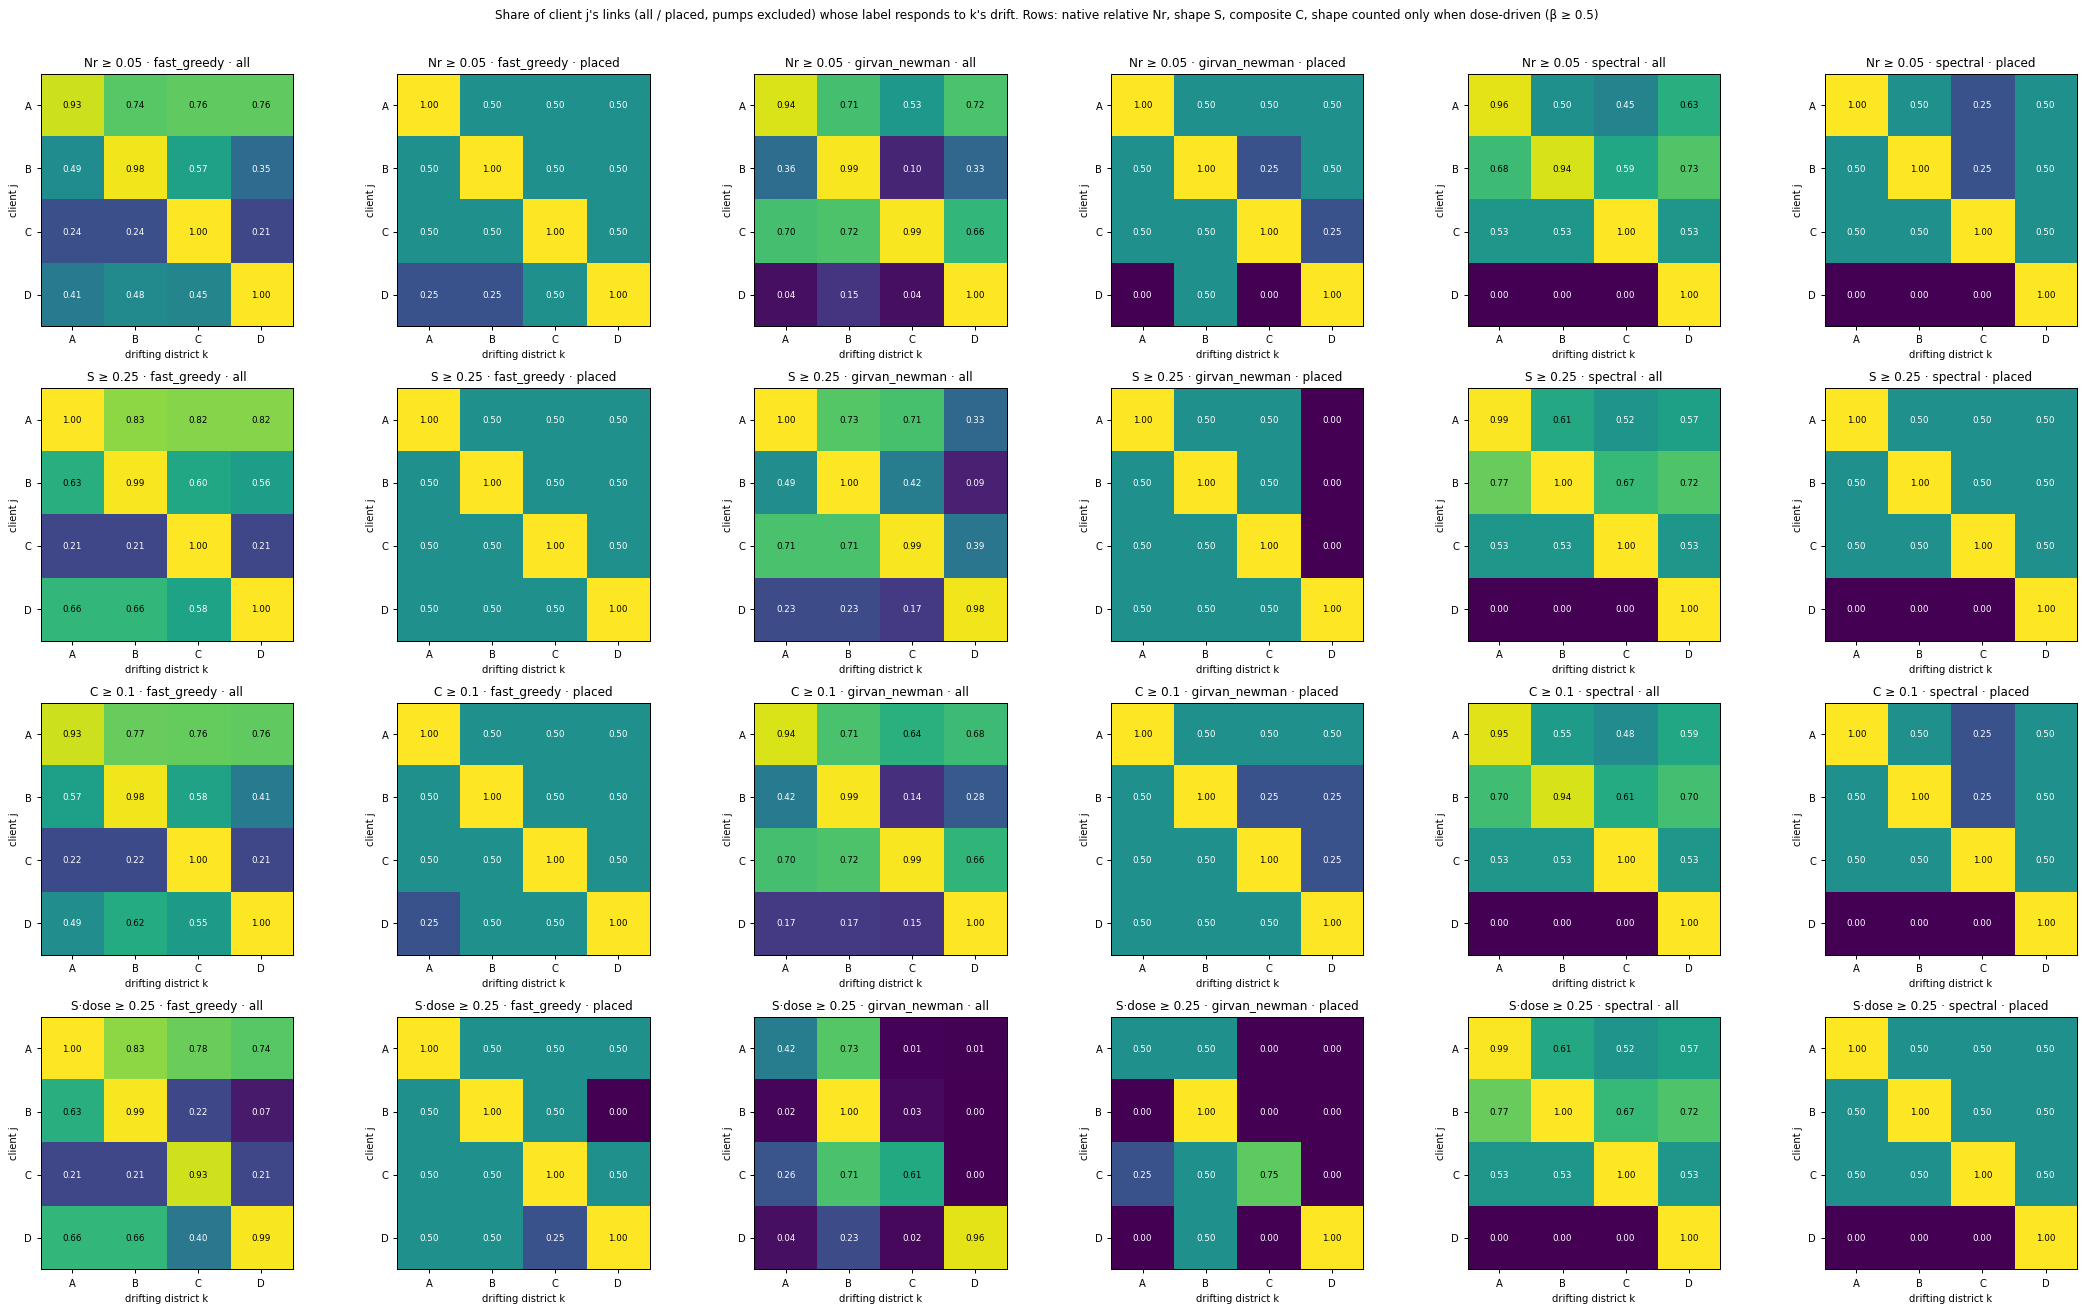

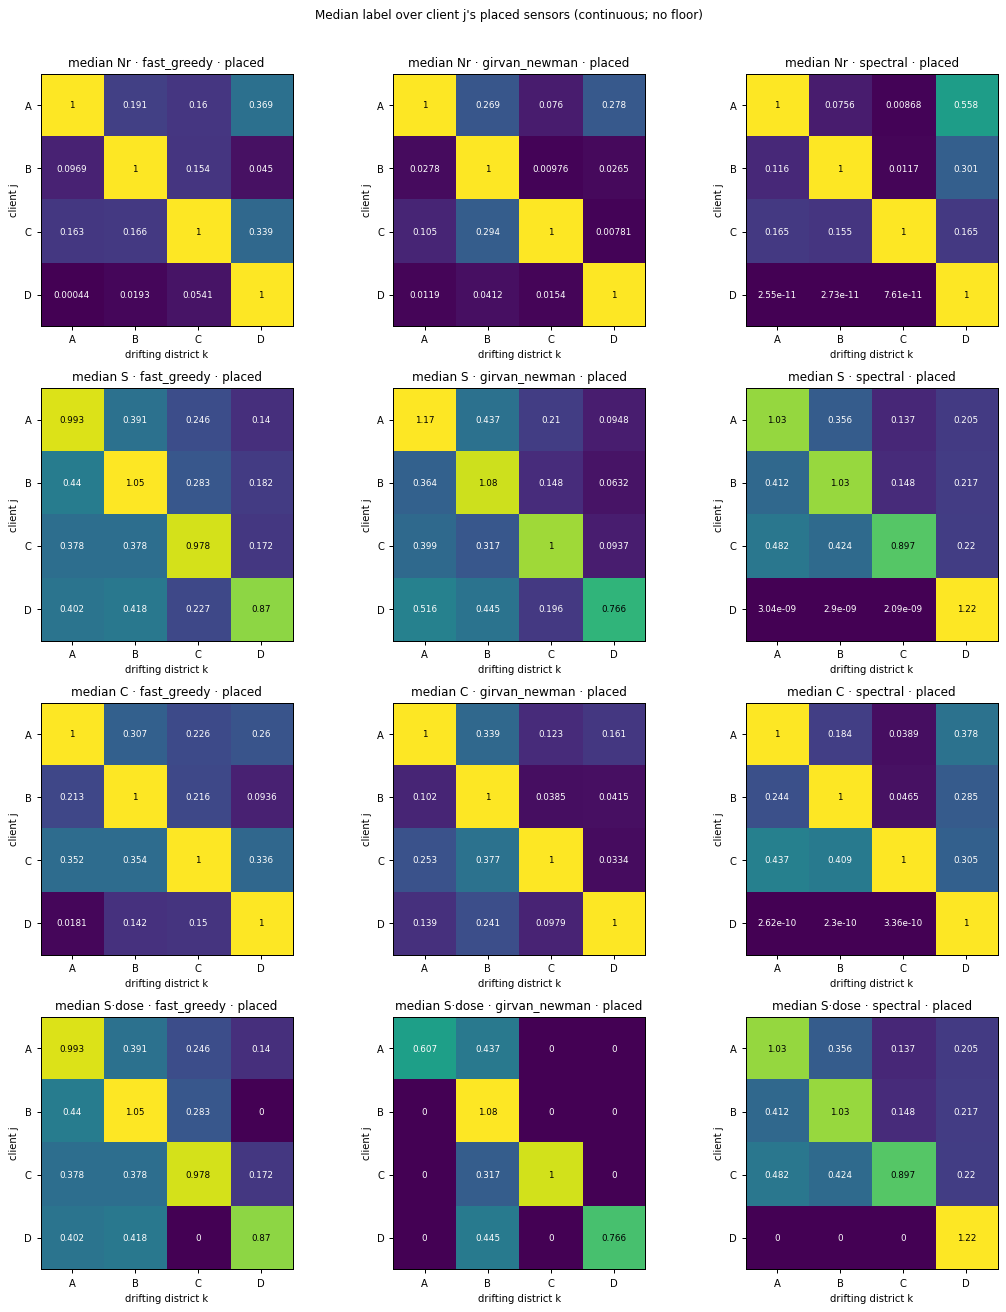

In [8]:
# A. client-pair matrices (final window): share of client j's links that respond to k, and the continuous version
METRICS = ["Nr", "S", "C"] + (["S·dose"] if DOSE_OK else [])
LFx = LF.copy()
if DOSE_OK:
    LFx["S·dose"] = LFx["S"].where(LFx["beta"] >= BETA_MIN, 0.0)       # shape effect counted only if dose-driven
    FLOOR["S·dose"] = FLOOR["S"]
MAT = []
for m, g in LFx.groupby("districting"):
    for scope, q_ in (("all", g), ("placed", g[g["placed"]])):
        for x in METRICS:
            r_ = q_.assign(r=q_[x] >= FLOOR[x]).groupby(["home", "k"]).agg(
                share=("r", "mean"), n=("r", "size"), median=(x, "median")).reset_index()
            MAT.append(r_.assign(districting=m, scope=scope, metric=x, floor=FLOOR[x]))
MAT = pd.concat(MAT, ignore_index=True).rename(columns={"home": "j"})
MAT.to_parquet(OUT / "matrix.parquet", index=False)


def matrix_grid(df, value, title, scopes=("all", "placed"), vmax=1.0, fmt="{:.2f}"):
    parts = sorted(df["districting"].unique())
    cols = [(m, sc) for m in parts for sc in scopes]
    fig, axes = plt.subplots(len(METRICS), len(cols), figsize=(4 * len(cols), 3.7 * len(METRICS)), squeeze=False)
    for i, x in enumerate(METRICS):
        for j, (m, sc) in enumerate(cols):
            ax = axes[i, j]
            A = df[(df["districting"] == m) & (df["scope"] == sc) & (df["metric"] == x)].pivot(
                index="j", columns="k", values=value)
            if not len(A):
                ax.axis("off"); continue
            V = A.to_numpy(float)
            top = vmax if vmax else max(np.nanmax(V), 1e-9)
            ax.imshow(V, vmin=0, vmax=top, cmap="viridis")
            ax.set_xticks(range(A.shape[1]), [c.replace("District_", "") for c in A.columns])
            ax.set_yticks(range(A.shape[0]), [c.replace("District_", "") for c in A.index])
            for (a_, b_), v in np.ndenumerate(V):
                if np.isfinite(v):
                    ax.text(b_, a_, fmt.format(v), ha="center", va="center", fontsize=7, color="w" if v < 0.6 * top else "k")
            ax.set(xlabel="drifting district k", ylabel="client j",
                   title=(f"{x} ≥ {FLOOR[x]:g}" if value == "share" else f"median {x}") + f" · {m} · {sc}")
    fig.suptitle(title); fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()


matrix_grid(MAT, "share", "Share of client j's links (all / placed, pumps excluded) whose label responds to k's drift. "
            "Rows: native relative Nr, shape S, composite C" + (", shape counted only when dose-driven (β ≥ "
                                                                 f"{BETA_MIN})" if DOSE_OK else ""))
matrix_grid(MAT, "median", "Median label over client j's placed sensors (continuous; no floor)", scopes=("placed",),
            vmax=None, fmt="{:.3g}")

## S · Sensitivity to the relevance floor

Each metric swept over its floor: cells responding (own / other / placed / loops), the district-blind share, branches
that carry none of $k$'s water yet respond (physics: must be 0), and agreement with the study's significance.

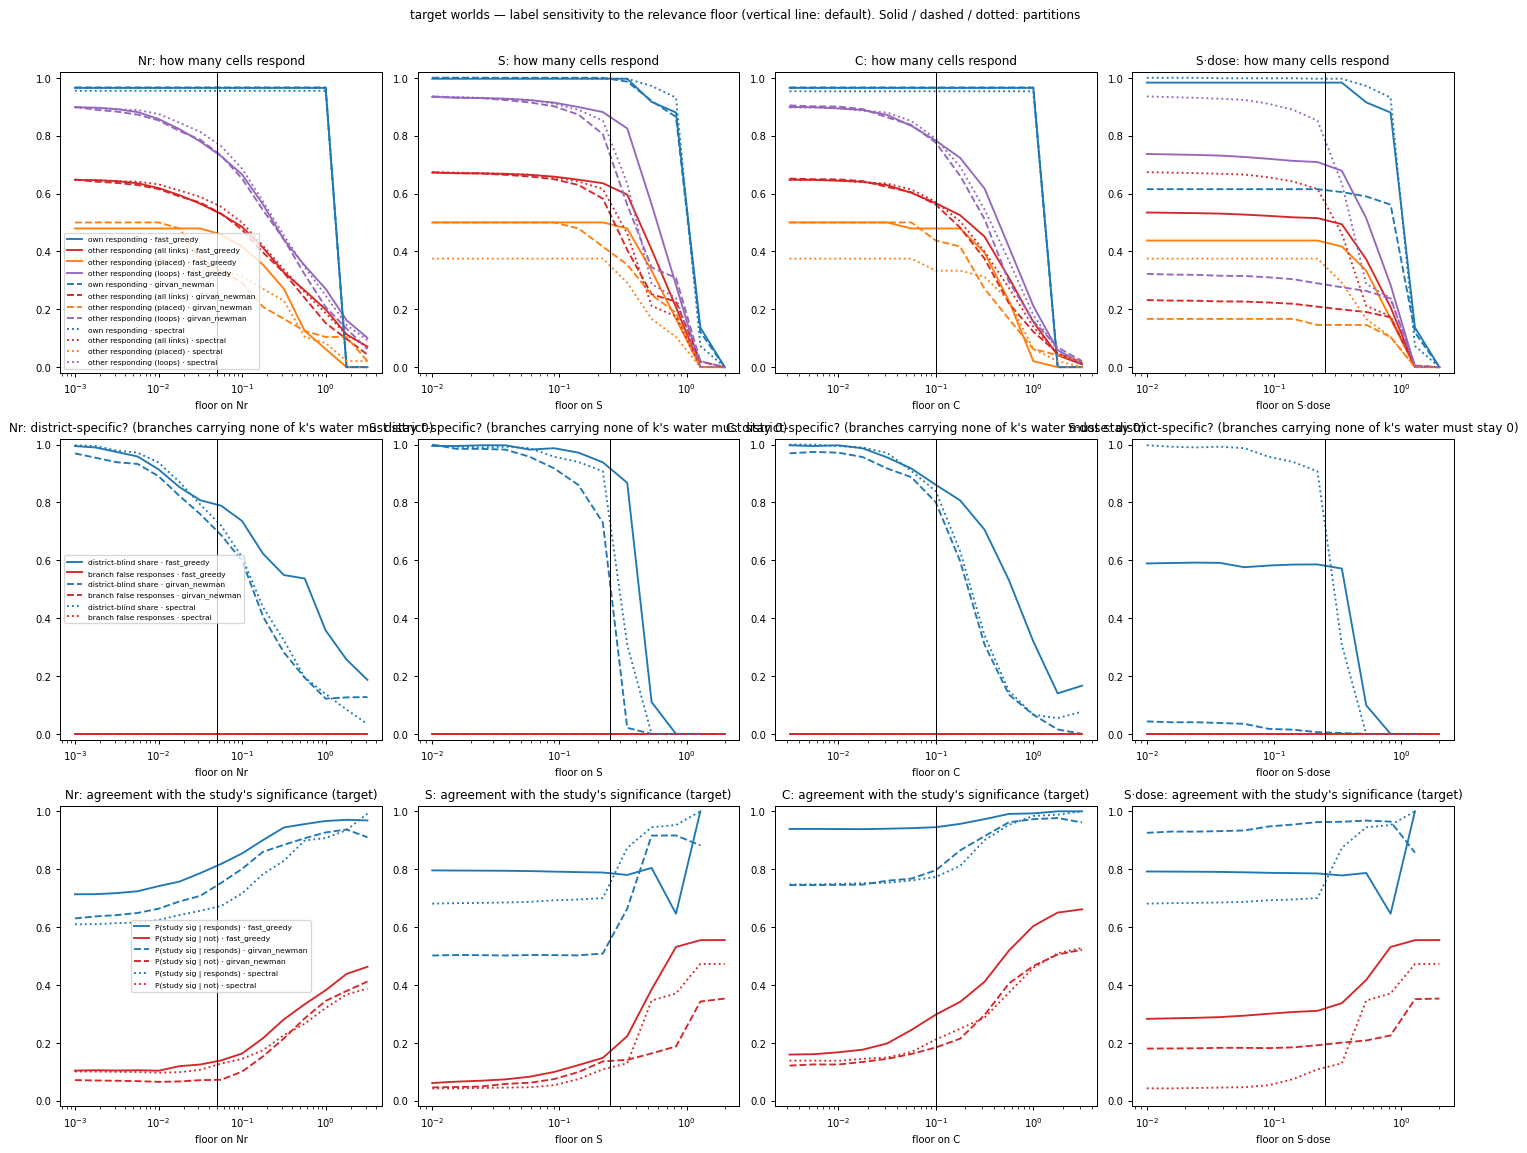

Read: a floor is defensible where the off-diagonal share is on a plateau (labels do not depend on the exact value), the district-blind share is low (the label separates districts) and branches never respond.

,set,districting,metric,eps,own responding,other responding (all links),other responding (placed),other responding (loops),district-blind share,branch false responses,P(study sig | responds),P(study sig | not)
0,target,fast_greedy,C,0.100,0.965,0.567,0.479,0.783,0.861,0.0,0.945,0.297
1,target,girvan_newman,C,0.100,0.967,0.562,0.438,0.776,0.801,0.0,0.796,0.184
2,target,spectral,C,0.100,0.953,0.571,0.333,0.789,0.839,0.0,0.773,0.211
3,target,fast_greedy,Nr,0.056,0.965,0.529,0.458,0.729,0.789,0.0,0.818,0.139
4,target,girvan_newman,Nr,0.056,0.967,0.531,0.333,0.731,0.687,0.0,0.753,0.072
5,target,spectral,Nr,0.056,0.955,0.554,0.333,0.764,0.720,0.0,0.673,0.128
6,target,fast_greedy,S,0.220,0.997,0.636,0.500,0.881,0.939,0.0,0.788,0.148
7,target,girvan_newman,S,0.220,1.000,0.582,0.417,0.805,0.730,0.0,0.509,0.136
8,target,spectral,S,0.220,0.997,0.616,0.375,0.852,0.907,0.0,0.700,0.108
9,target,fast_greedy,S·dose,0.220,0.983,0.515,0.438,0.709,0.586,0.0,0.785,0.310


In [9]:
# S. sensitivity of the labels to the relevance floor
se_ = SE.assign(element=SE["element"].astype(str)).rename(columns={"drift": "k"})[
    ["districting", "k", "element", "sig_tot", "sig_shape"]]
SW = LFx.merge(se_, on=["districting", "k", "element"], how="left").merge(
    CARR, on=["districting", "k", "element"], how="left")
study_flag = {"Nr": SW["sig_tot"], "S": SW["sig_shape"], "S·dose": SW["sig_shape"],
              "C": SW["sig_tot"].astype("boolean") | SW["sig_shape"].astype("boolean")}
rows = []
for x in METRICS:
    SW["_sig"] = study_flag[x]
    s_ = "target"
    for m, g in SW.groupby("districting"):
        off, on = g[~g["own"]], g[g["own"]]
        for eps in SWEEP["S" if x == "S·dose" else x]:
            r_off = off[x] >= eps
            per_link = off.assign(r=r_off).groupby("element").agg(n_resp=("r", "sum"), n=("r", "size"))
            anyk = per_link["n_resp"] > 0
            row = {"set": s_, "districting": m, "metric": x, "eps": eps,
                   "own responding": float((on[x] >= eps).mean()),
                   "other responding (all links)": float(r_off.mean()),
                   "other responding (placed)": float(r_off[off["placed"]].mean()) if off["placed"].any() else np.nan,
                   "other responding (loops)": float(r_off[off["topo"] == "loop"].mean()),
                   "district-blind share": float((per_link["n_resp"] == per_link["n"])[anyk].mean()) if anyk.any() else np.nan,
                   "branch false responses": float(r_off[(off["topo"] == "branch") & (off["carries"] == False)].mean())}
            if s_ == "target":
                sg = off["_sig"].astype("boolean")
                ok = sg.notna()
                row["P(study sig | responds)"] = float(sg[ok & r_off].mean()) if (ok & r_off).any() else np.nan
                row["P(study sig | not)"] = float(sg[ok & ~r_off].mean()) if (ok & ~r_off).any() else np.nan
            rows.append(row)
SENS = pd.DataFrame(rows)
SENS.to_parquet(OUT / "sensitivity.parquet", index=False)

panels = [("own responding", "other responding (all links)", "other responding (placed)", "other responding (loops)"),
          ("district-blind share", "branch false responses"),
          ("P(study sig | responds)", "P(study sig | not)")]
ptitle = ["how many cells respond", "district-specific? (branches carrying none of k's water must stay 0)",
          "agreement with the study's significance (target)"]
for s_ in sorted(SENS["set"].unique()):
    fig, axes = plt.subplots(3, len(METRICS), figsize=(16, 13), squeeze=False)
    for j, x in enumerate(METRICS):
        for i, cols in enumerate(panels):
            ax = axes[i, j]
            for (m, q_), ls in zip(SENS[(SENS["set"] == s_) & (SENS["metric"] == x)].groupby("districting"),
                                   ("-", "--", ":")):
                for c, cc in zip(cols, ("#1f77b4", "#d62728", "#ff7f0e", "#9467bd")):
                    if c in q_ and q_[c].notna().any():
                        ax.plot(q_["eps"], q_[c], ls=ls, color=cc, label=f"{c} · {m}")
            ax.axvline(FLOOR[x], color="k", lw=0.8)
            ax.set(xscale="log", ylim=(-0.02, 1.02), xlabel=f"floor on {x}",
                   title=f"{x}: {ptitle[i]}")
            if j == 0:
                ax.legend(fontsize=6)
    fig.suptitle(f"{s_} worlds — label sensitivity to the relevance floor (vertical line: default). "
                 "Solid / dashed / dotted: partitions")
    fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()
display(Markdown("Read: a floor is defensible where the off-diagonal share is on a plateau (labels do not depend on the "
                 "exact value), the district-blind share is low (the label separates districts) and branches never respond."))
display(SENS.groupby(["metric", "districting"]).apply(
    lambda q: q.iloc[(q["eps"] - FLOOR[q.name[0]]).abs().argsort()[:1]]).reset_index(drop=True).round(3))

## P · Sanity: what the numbers mean in the pipes

Population: how proportional ($r^2_t$), systematic and dose-driven (β) each response is; every off-diagonal cell in the
Nr–S plane coloured by β. **Sensor cards** add to v2: the demand channel alone (E2) next to the full effect, the same
drift at reduced strength scaled back by 1/λ (curves that coincide = proportional), and where the sensor's water goes
hour by hour with and without the drift (E1). The gallery picks placed sensors by their numbers (own branch, own loop,
strongest composite, least / most dose-driven responder, native- / shape-dominated); the widget opens any placed sensor.

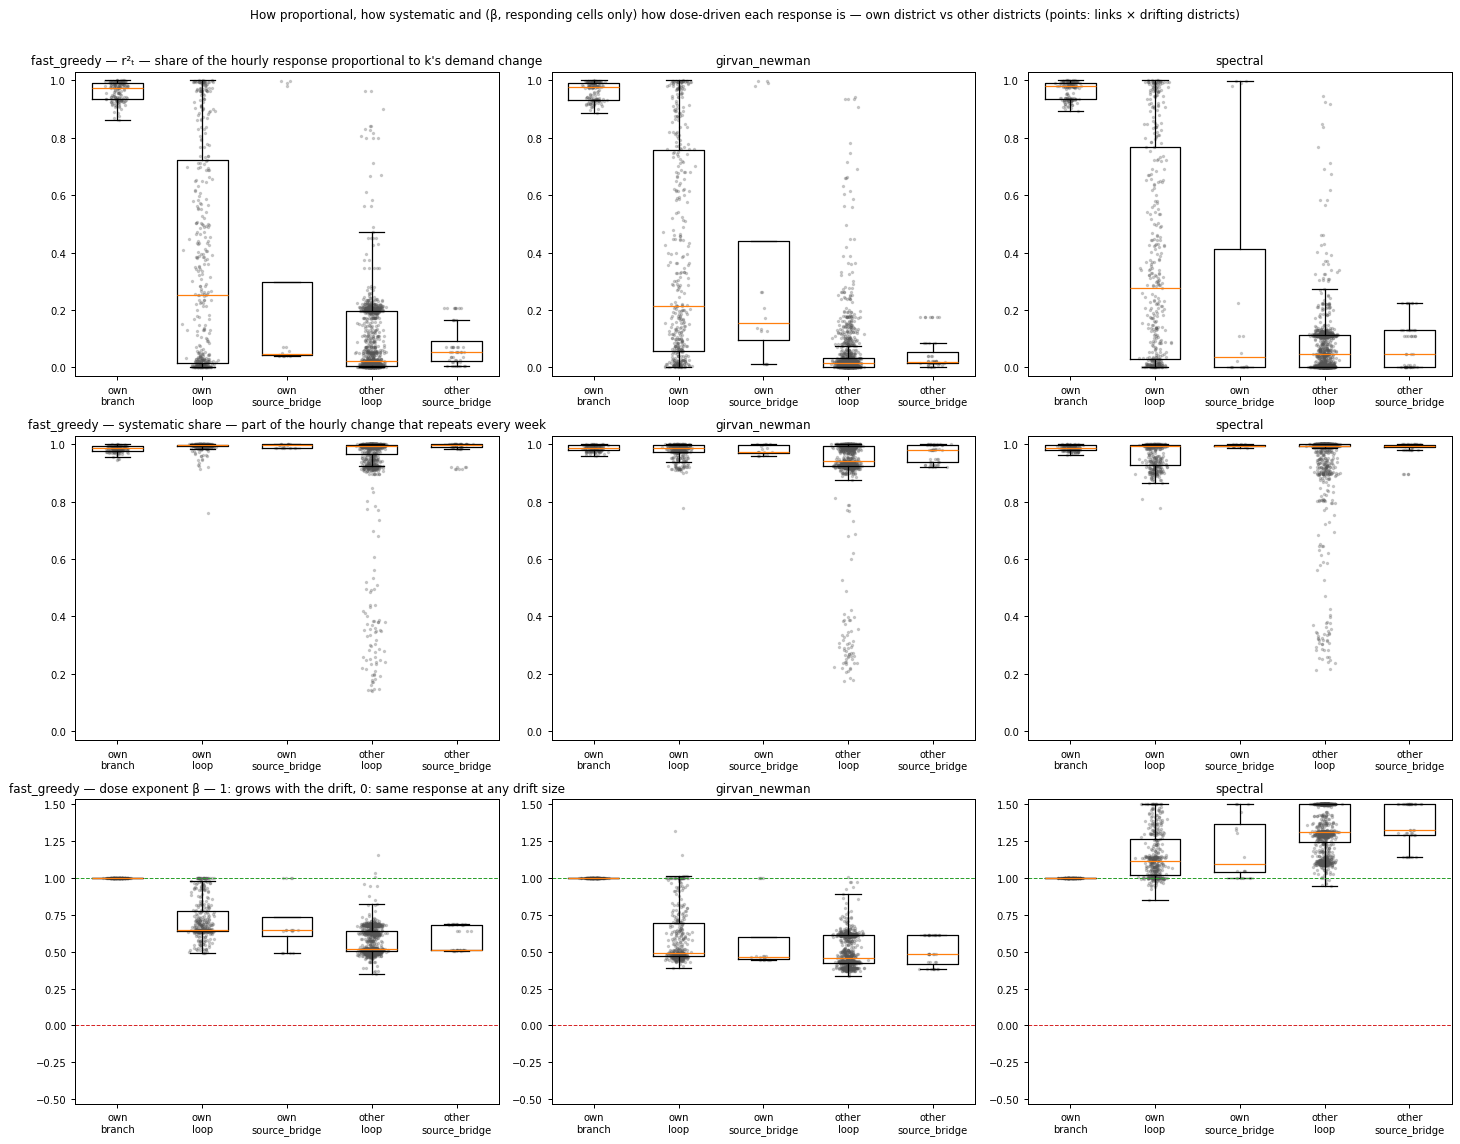

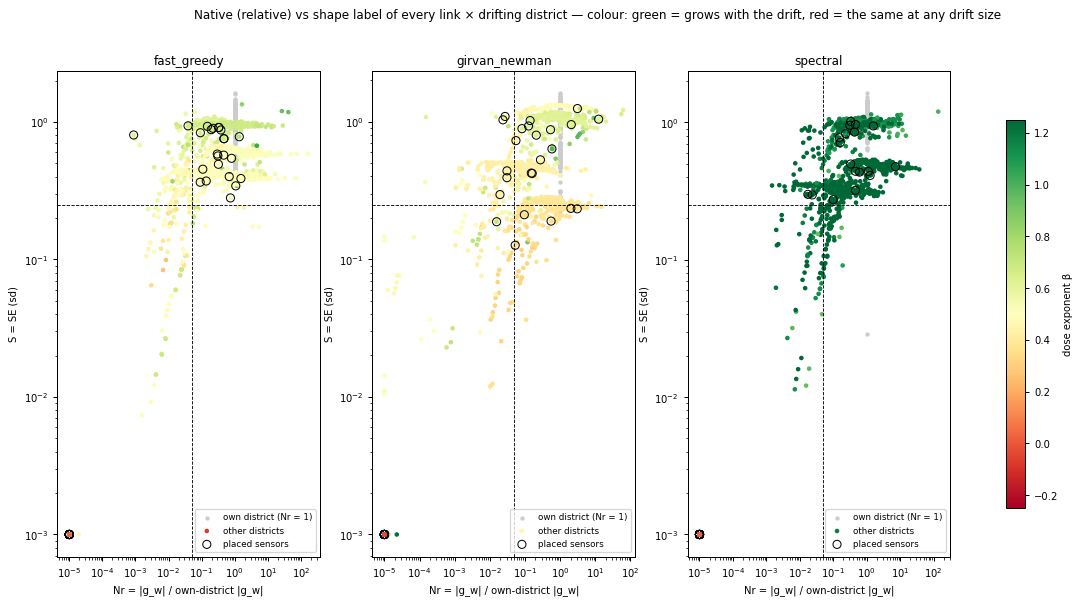

#### own district, branch: exact and proportional

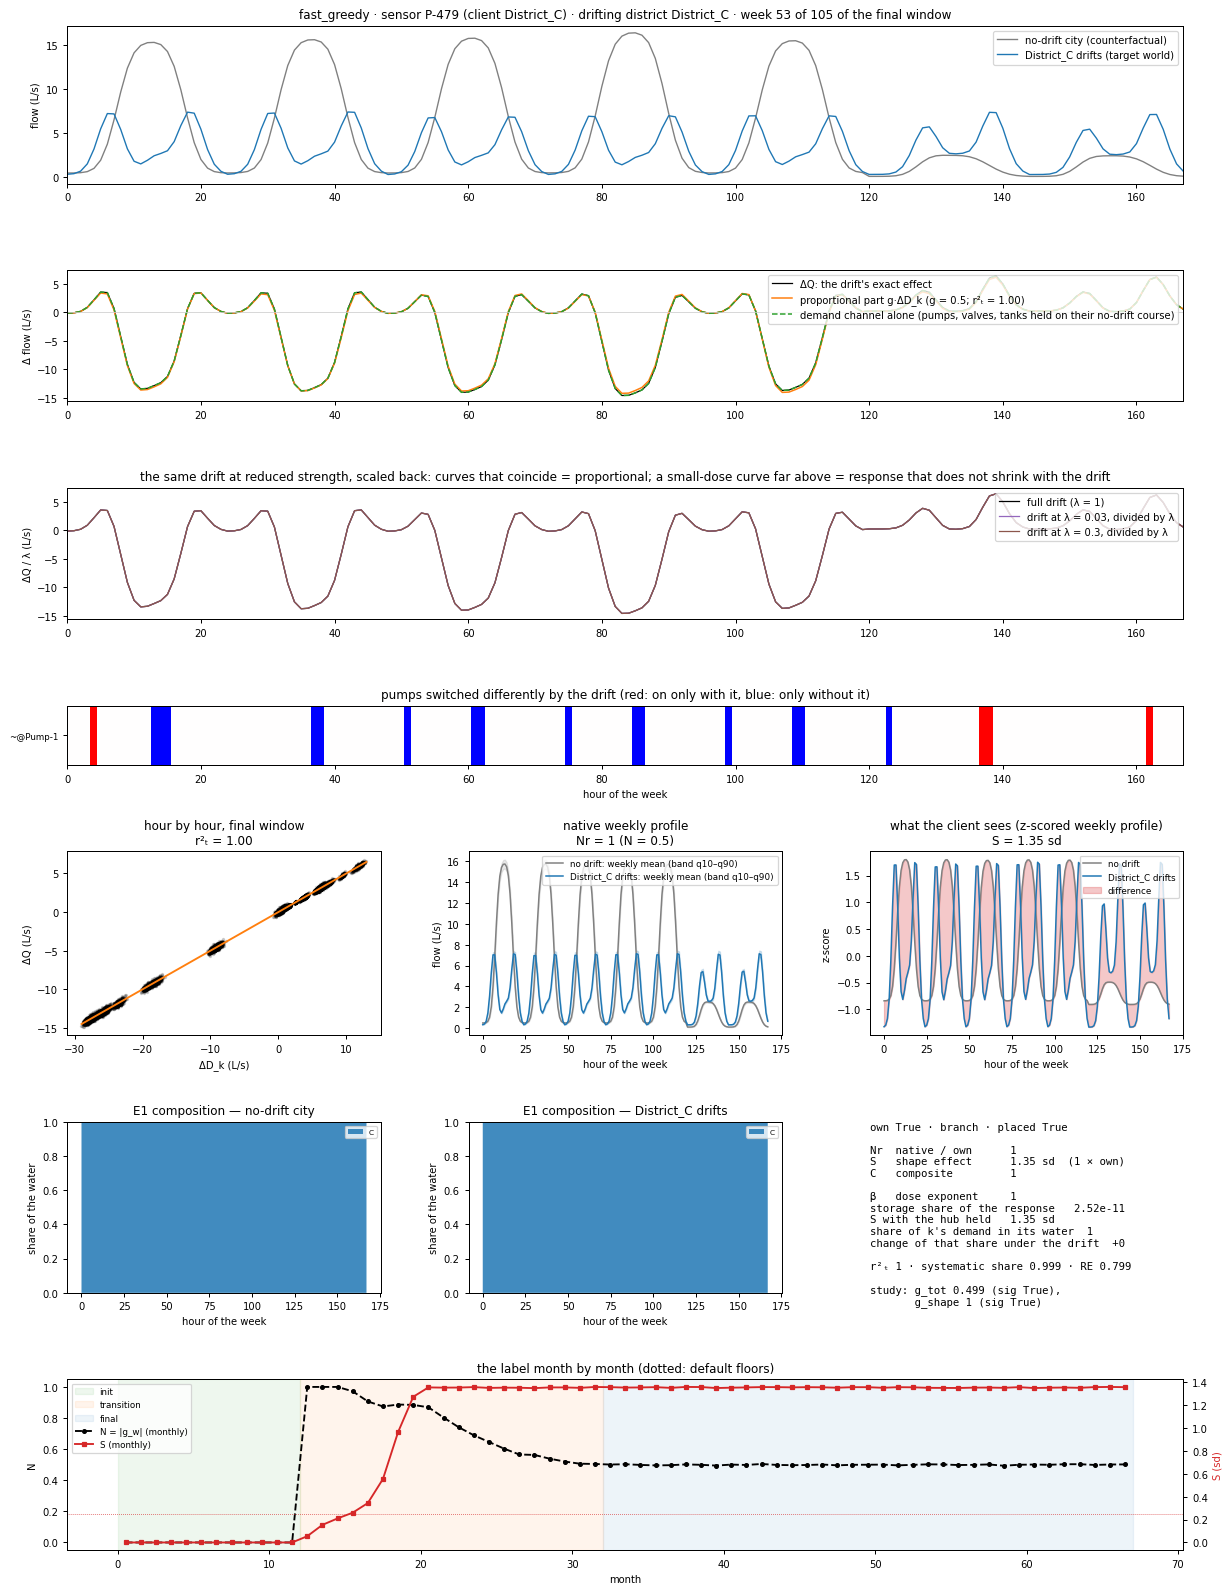

#### own district, loop / source bridge

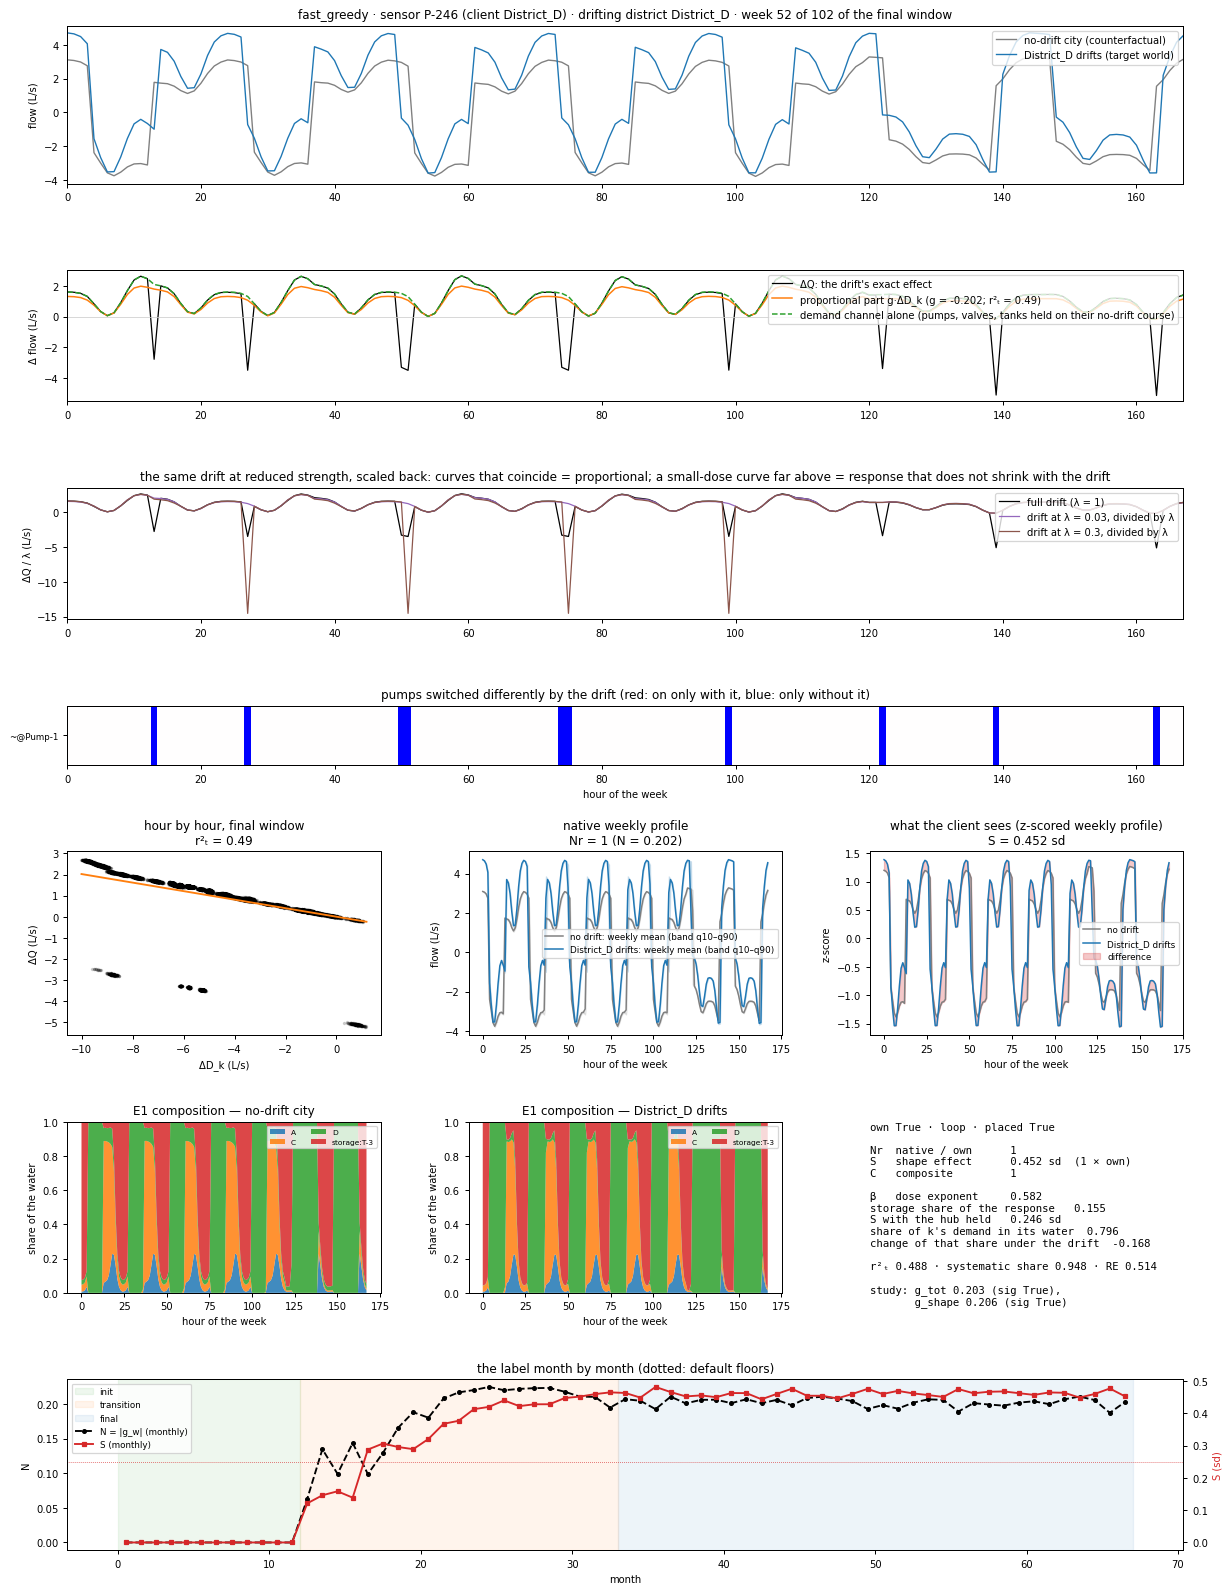

#### other district: strongest composite

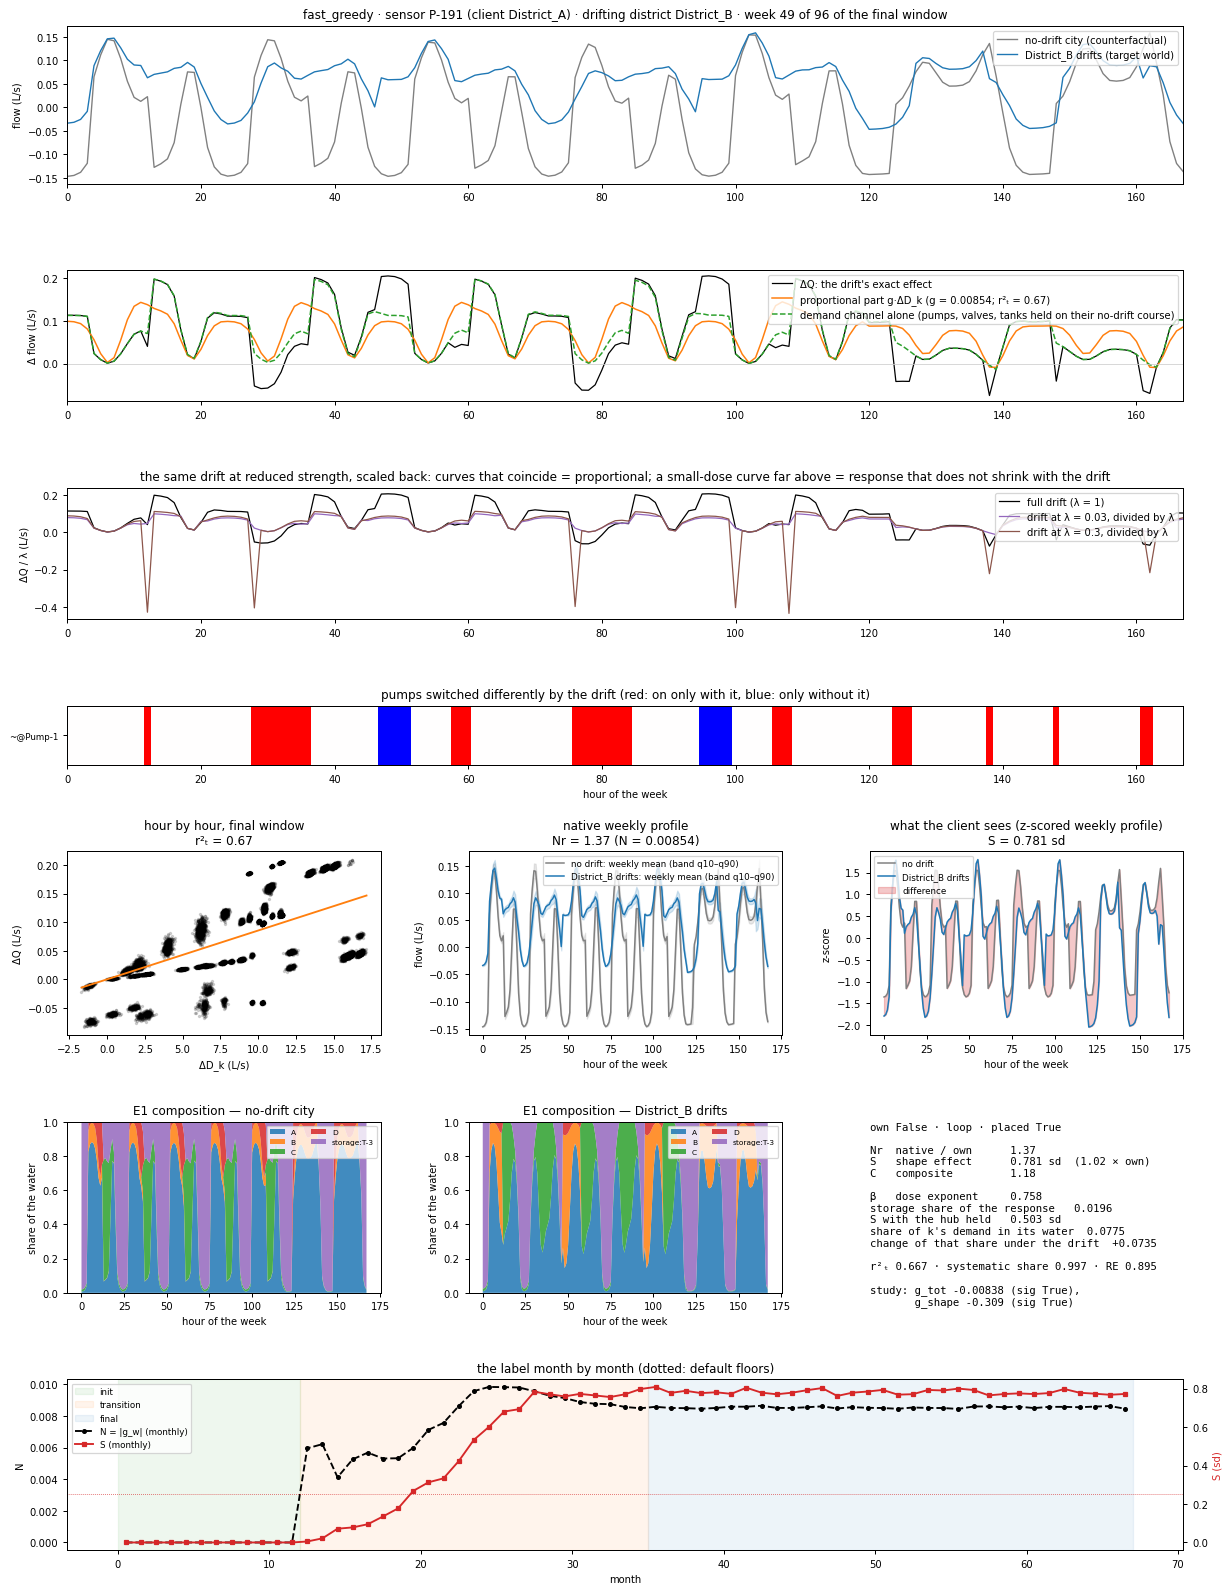

#### other district: responds, least dose-driven (smallest β)

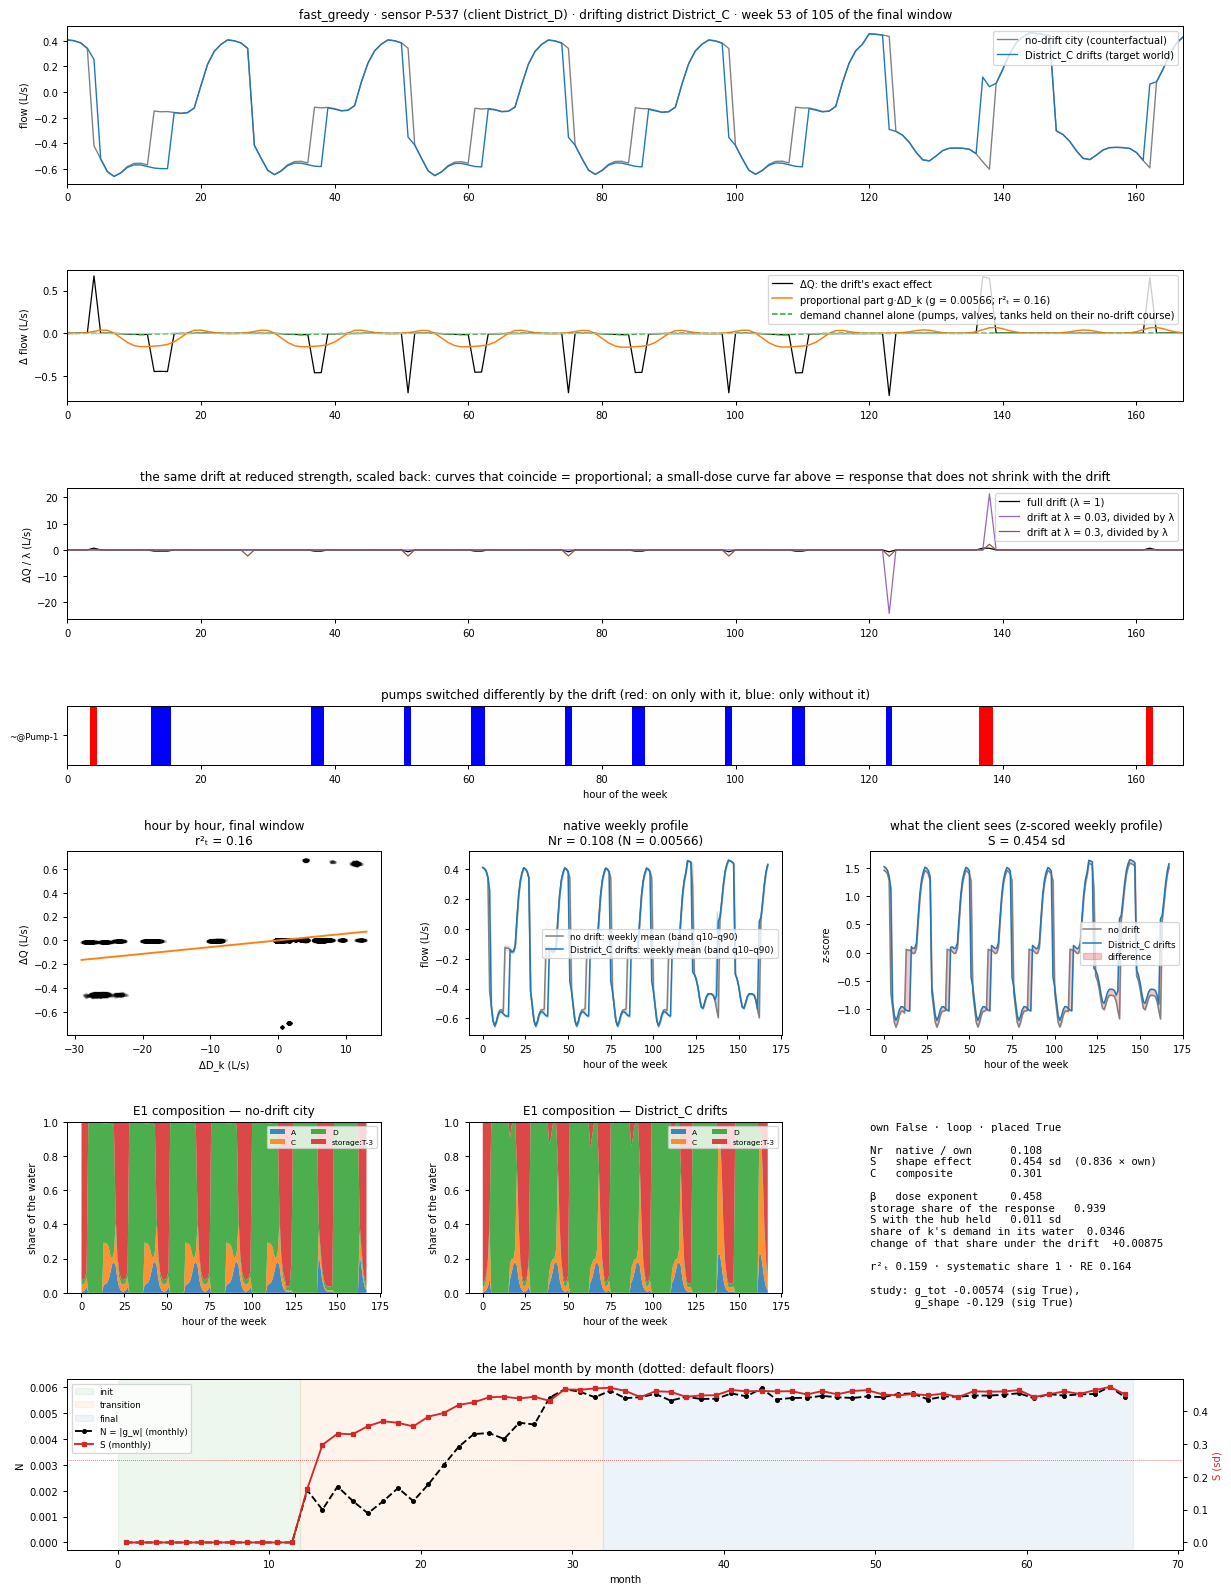

#### other district: responds, most dose-driven (largest β)

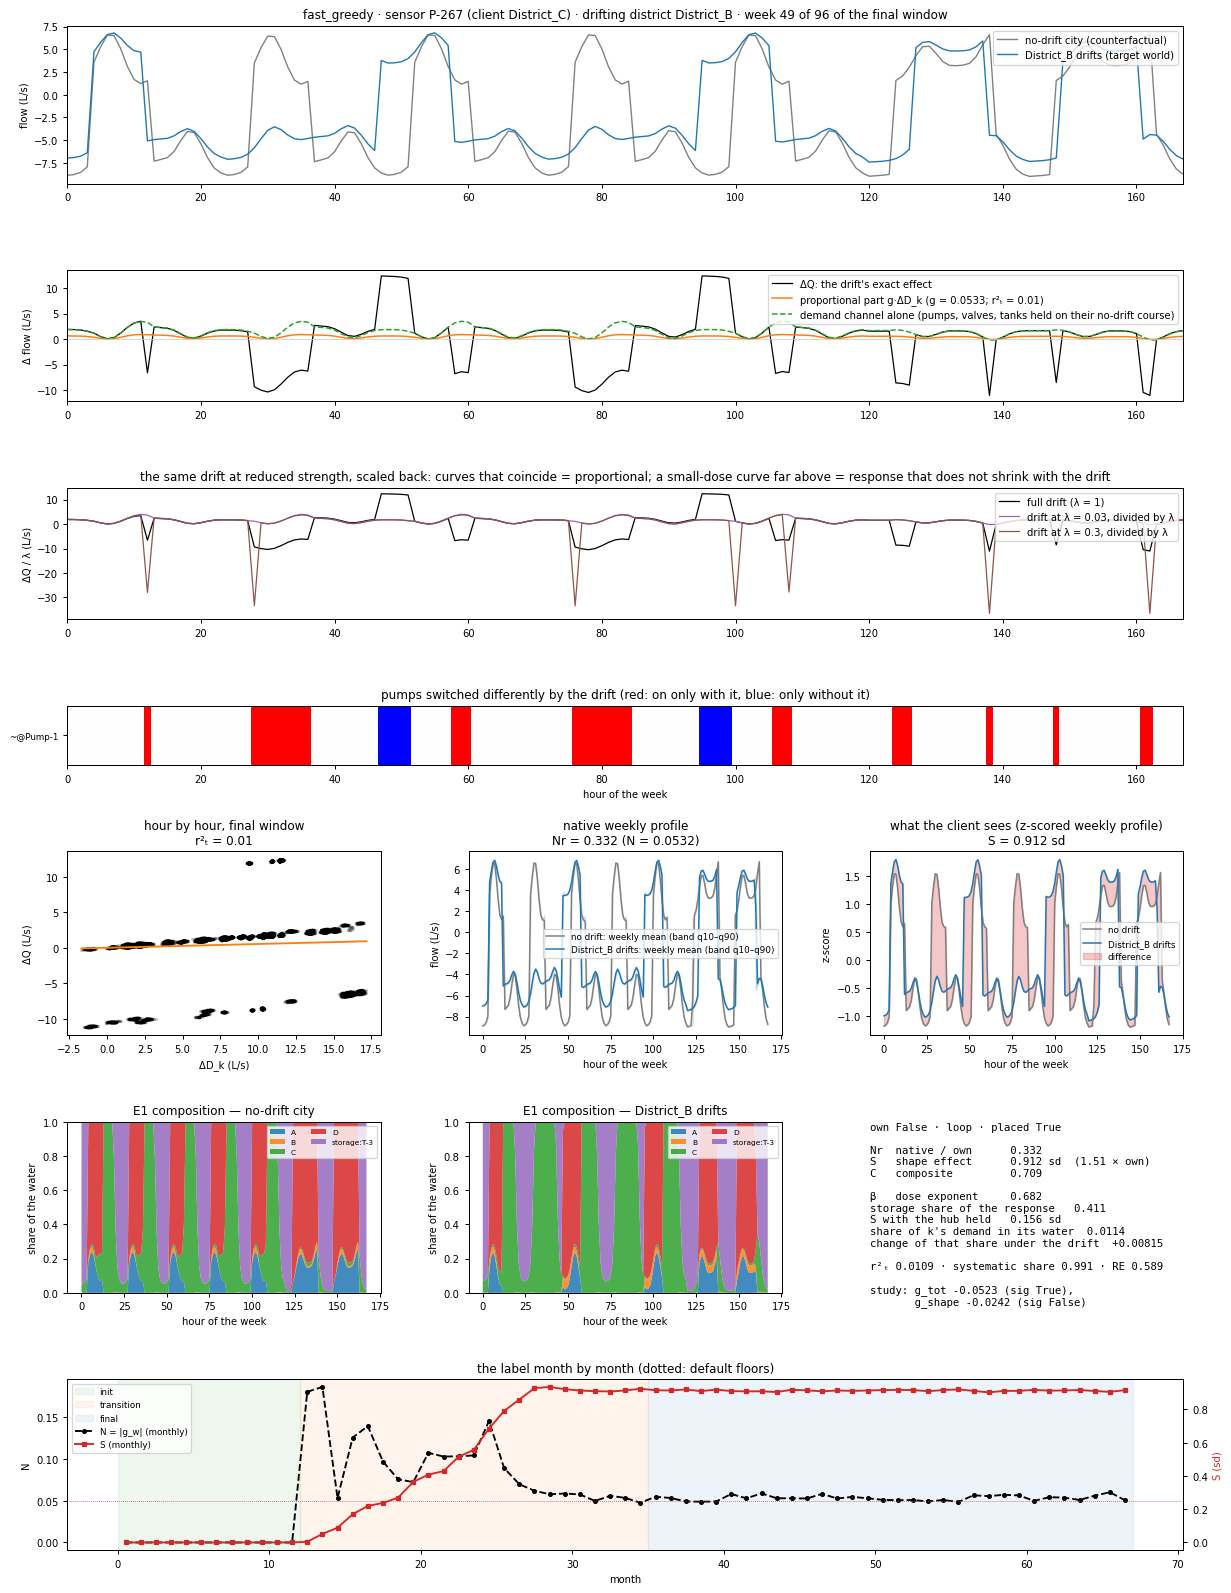

#### other district: most native-dominated (no native-only case)

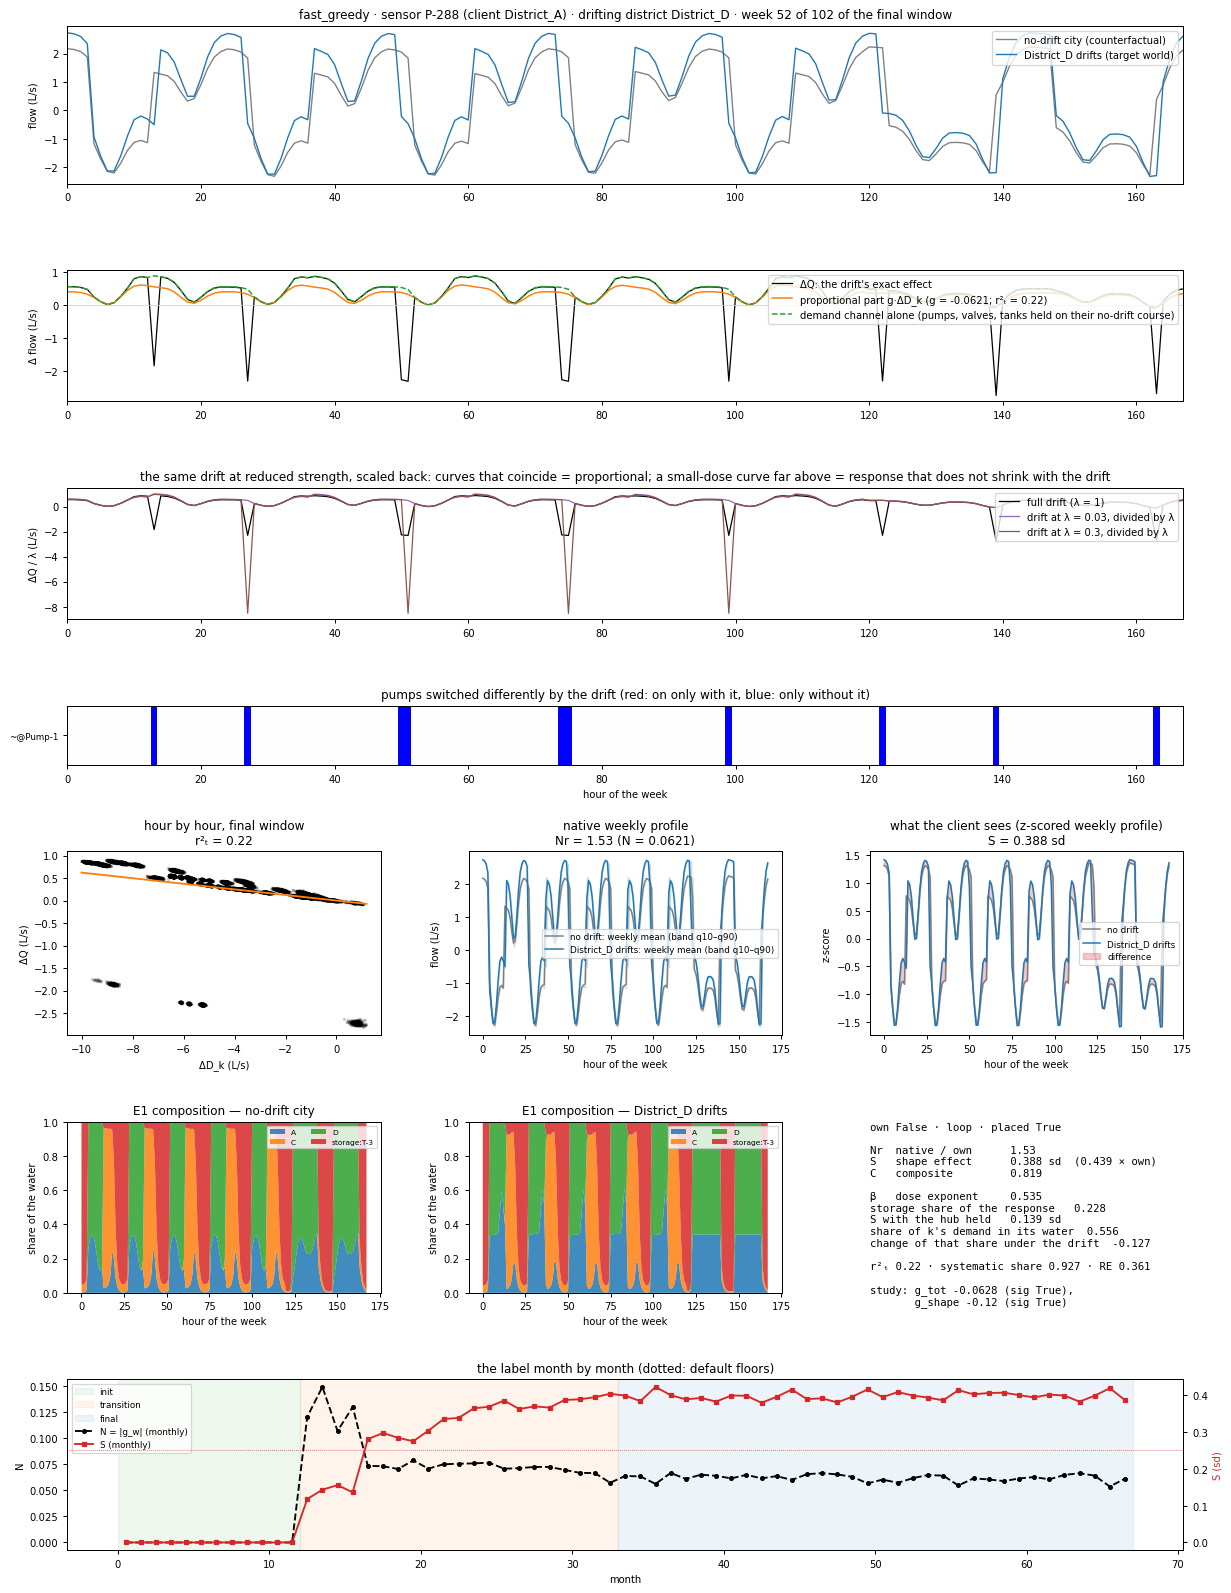

#### other district: shape only

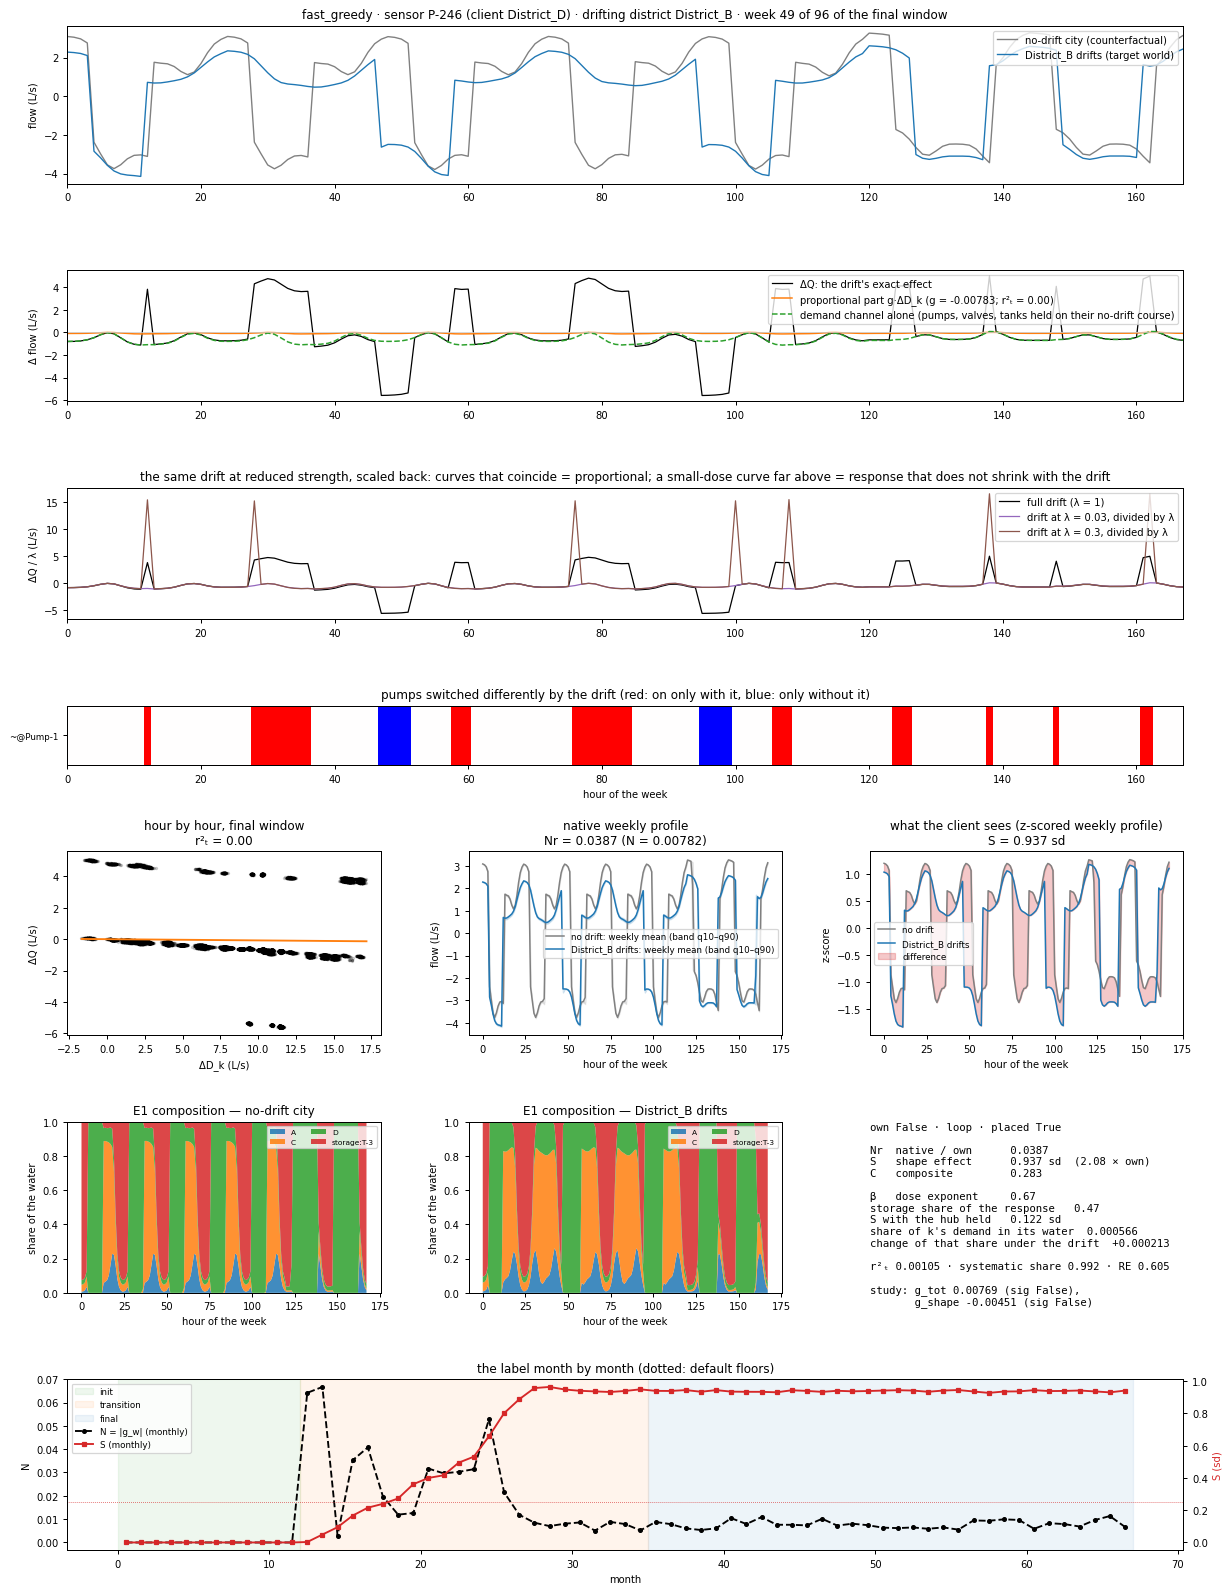

In [10]:
# P. sanity: how the numbers relate to what happens in the pipes (target worlds, final window)
TF = LF.copy()
TF["group"] = np.where(TF["own"], "own · ", "other · ") + TF["topo"]
order = [g for g in ("own · branch", "own · loop", "own · source_bridge", "other · loop", "other · source_bridge")
         if g in set(TF["group"])]
parts = sorted(TF["districting"].unique())
cols_ = [("r2_t", "r²ₜ — share of the hourly response proportional to k's demand change", (0, 1)),
         ("sys_share", "systematic share — part of the hourly change that repeats every week", (0, 1))]
if DOSE_OK:
    cols_.append(("beta", f"dose exponent β — 1: grows with the drift, 0: same response at any drift size", (-0.5, 1.5)))
fig, axes = plt.subplots(len(cols_), len(parts), figsize=(16, 4.3 * len(cols_)), squeeze=False)
rng = np.random.default_rng(0)
for j, m in enumerate(parts):
    q_ = TF[TF["districting"] == m]
    for i, (col, lab, lim) in enumerate(cols_):
        ax = axes[i, j]
        data = [q_[(q_["group"] == g_) & (q_["S"] >= (FLOOR["S"] if col == "beta" else -1))][col].dropna().clip(*lim)
                for g_ in order]
        ax.boxplot(data, widths=0.6, showfliers=False)
        for x_, d_ in enumerate(data, start=1):
            ax.scatter(rng.normal(x_, 0.06, len(d_)), d_, s=3, alpha=0.25, color="#555")
        if col == "beta":
            ax.axhline(1, color="#2ca02c", lw=0.8, ls="--"); ax.axhline(0, color="#d62728", lw=0.8, ls="--")
        ax.set_xticks(range(1, len(order) + 1), [o.replace(" · ", "\n") for o in order])
        ax.set(ylim=(lim[0] - 0.03, lim[1] + 0.03), title=f"{m} — {lab}" if j == 0 else m)
fig.suptitle("How proportional, how systematic and (β, responding cells only) how dose-driven each response is — "
             "own district vs other districts (points: links × drifting districts)")
fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

fig, axes = plt.subplots(1, len(parts), figsize=(16, 7), squeeze=False)
for j, m in enumerate(parts):
    ax = axes[0, j]
    q_ = TF[TF["districting"] == m]
    o_, x_ = q_[q_["own"]], q_[~q_["own"]]
    ax.scatter(o_["Nr"].clip(1e-5), o_["S"].clip(1e-3), s=6, color="0.8", label="own district (Nr = 1)")
    cval = x_["beta"].clip(-0.25, 1.25) if DOSE_OK else x_["sys_share"]
    sc = ax.scatter(x_["Nr"].clip(1e-5), x_["S"].clip(1e-3), s=7, c=cval, cmap="RdYlGn",
                    vmin=-0.25 if DOSE_OK else 0, vmax=1.25 if DOSE_OK else 1, label="other districts")
    pl = x_[x_["placed"]]
    ax.scatter(pl["Nr"].clip(1e-5), pl["S"].clip(1e-3), s=42, facecolors="none", edgecolors="k", lw=0.8, label="placed sensors")
    ax.axvline(FLOOR["Nr"], color="k", lw=0.7, ls="--"); ax.axhline(FLOOR["S"], color="k", lw=0.7, ls="--")
    ax.set(xscale="log", yscale="log", xlabel="Nr = |g_w| / own-district |g_w|", ylabel="S = SE (sd)", title=m)
    ax.legend(fontsize=7, loc="lower right")
fig.colorbar(sc, ax=axes.ravel().tolist(), shrink=0.8, label="dose exponent β" if DOSE_OK else "systematic share")
fig.suptitle("Native (relative) vs shape label of every link × drifting district — colour: " +
             ("green = grows with the drift, red = the same at any drift size" if DOSE_OK else "systematic share"))
plt.show()


# ---- sensor cards --------------------------------------------------------------------------------
_SER = {}


def _load(name):
    if name not in _SER:
        p = SERIES / f"{name}.npz"
        _SER[name] = dict(np.load(p, allow_pickle=False)) if p.exists() else None
    return _SER[name]


def sensor_card(m, k, element, week=None):
    """Everything one label summarises, for one sensor and one drifting district (target world, final window)."""
    n0, n1 = _load(f"{m}__nodrift"), _load(f"{m}__{k}")
    links = list(n1["links"])
    if element not in links:
        print(f"{element}: no saved series (only placed sensors are saved)"); return
    j = links.index(element)
    i0, i1, f0, f1 = map(int, n1["periods"])
    sd, sm = int(n1["sd"]), int(n1["sm"])
    Q0, Q1 = n0["Q"][:, j].astype(float), n1["Q"][:, j].astype(float)
    D0k, D1k = n0[f"D_{k}"].astype(float), n1["D"].astype(float)
    dQ, dD = Q1 - Q0, D1k - D0k
    W = slice(f0, f1)
    g_h = float(dQ[W] @ dD[W] / (dD[W] @ dD[W]))
    r2 = 1 - float(((dQ[W] - g_h * dD[W]) ** 2).sum() / max((dQ[W] ** 2).sum(), 1e-18))
    lab = LB[(LB["districting"] == m) & (LB["k"] == k) & (LB["element"] == element) & (LB["period"] == "final")]
    row = lab.iloc[0] if len(lab) else None
    nweeks = (f1 - f0) // (7 * sd)
    wk = nweeks // 2 if week is None else int(np.clip(week, 0, nweeks - 1))
    a = f0 + wk * 7 * sd
    t = np.arange(7 * sd)
    dose, e2, c0, c1 = _load(f"{m}__{k}__dose"), _load(f"{m}__{k}__e2"), _load(f"{m}__{k}__e1_nodrift"), _load(f"{m}__{k}__e1_drift")

    fig = plt.figure(figsize=(16, 22))
    gs = fig.add_gridspec(7, 3, height_ratios=[1.2, 1.0, 1.0, 0.45, 1.4, 1.3, 1.3], hspace=0.6, wspace=0.28)
    ax0 = fig.add_subplot(gs[0, :])
    ax0.plot(t, Q0[a:a + 7 * sd], color="0.5", lw=1.1, label="no-drift city (counterfactual)")
    ax0.plot(t, Q1[a:a + 7 * sd], color="#1f77b4", lw=1.1, label=f"{k} drifts (target world)")
    ax0.set(ylabel="flow (L/s)", xlim=(0, 7 * sd - 1),
            title=f"{m} · sensor {element} (client {row['home'] if row is not None else '?'}) · drifting district {k} · "
                  f"week {wk + 1} of {nweeks} of the final window")
    ax0.legend(fontsize=8, loc="upper right")
    ax = fig.add_subplot(gs[1, :], sharex=ax0)
    ax.plot(t, dQ[a:a + 7 * sd], color="k", lw=1.0, label="ΔQ: the drift's exact effect")
    ax.plot(t, g_h * dD[a:a + 7 * sd], color="#ff7f0e", lw=1.2, label=f"proportional part g·ΔD_k (g = {g_h:.3g}; r²ₜ = {r2:.2f})")
    if e2 is not None and element in list(e2["links"]):
        jj = list(e2["links"]).index(element)
        ax.plot(t, (e2["Qd"][:, jj] - e2["Q0"][:, jj])[a:a + 7 * sd], color="#2ca02c", lw=1.2, ls="--",
                label="demand channel alone (pumps, valves, tanks held on their no-drift course)")
    ax.axhline(0, color="0.8", lw=0.6); ax.set(ylabel="Δ flow (L/s)"); ax.legend(fontsize=8, loc="upper right")
    ax = fig.add_subplot(gs[2, :], sharex=ax0)
    if dose is not None:
        ax.plot(t, dQ[a:a + 7 * sd], color="k", lw=1.0, label="full drift (λ = 1)")
        for lam, c in zip(LAMBDAS, ("#9467bd", "#8c564b")):
            if f"Q_{lam}" in dose:
                dl = (dose[f"Q_{lam}"][:, j].astype(float) - Q0)[a:a + 7 * sd]
                ax.plot(t, dl / lam, color=c, lw=1.0, label=f"drift at λ = {lam:g}, divided by λ")
        ax.set(ylabel="ΔQ / λ (L/s)", title="the same drift at reduced strength, scaled back: curves that coincide = "
                                              "proportional; a small-dose curve far above = response that does not shrink with the drift")
        ax.legend(fontsize=8, loc="upper right")
    else:
        ax.axis("off")
    ax = fig.add_subplot(gs[3, :], sharex=ax0)
    dU = (n1["U"][a:a + 7 * sd].astype(int) - n0["U"][a:a + 7 * sd].astype(int)).T
    pumps = list(n1["pumps"])
    busy = np.abs(dU).sum(axis=1) > 0
    if busy.any():
        ax.imshow(dU[busy], aspect="auto", cmap="bwr", vmin=-1, vmax=1, interpolation="nearest",
                  extent=(-0.5, 7 * sd - 0.5, busy.sum() - 0.5, -0.5))
        ax.set_yticks(range(busy.sum()), [p for p, b in zip(pumps, busy) if b], fontsize=7)
    ax.set(xlabel="hour of the week", title="pumps switched differently by the drift (red: on only with it, blue: only without it)")

    P0, P1 = profile(Q0[W], sd, f0)[0], profile(Q1[W], sd, f0)[0]
    stack0 = np.stack([Q0[f0 + w * 7 * sd: f0 + (w + 1) * 7 * sd] for w in range(nweeks)])
    stack1 = np.stack([Q1[f0 + w * 7 * sd: f0 + (w + 1) * 7 * sd] for w in range(nweeks)])
    tt = np.arange(stack0.shape[1])
    ax = fig.add_subplot(gs[4, 0])
    ax.scatter(dD[W], dQ[W], s=3, alpha=0.15, color="k", rasterized=True)
    xx = np.linspace(dD[W].min(), dD[W].max(), 10)
    ax.plot(xx, g_h * xx, color="#ff7f0e", lw=1.5)
    ax.set(xlabel="ΔD_k (L/s)", ylabel="ΔQ (L/s)", title=f"hour by hour, final window\nr²ₜ = {r2:.2f}")
    ax = fig.add_subplot(gs[4, 1])
    for st, P, c, l in ((stack0, P0, "0.5", "no drift"), (stack1, P1, "#1f77b4", f"{k} drifts")):
        ax.fill_between(tt, np.quantile(st, 0.1, axis=0), np.quantile(st, 0.9, axis=0), color=c, alpha=0.18)
        ax.plot(tt, P, color=c, lw=1.2, label=f"{l}: weekly mean (band q10–q90)")
    ax.set(xlabel="hour of the week", ylabel="flow (L/s)",
           title=f"native weekly profile\nNr = {row['Nr']:.3g} (N = {row['N']:.3g})" if row is not None else "")
    ax.legend(fontsize=7)
    ax = fig.add_subplot(gs[4, 2])
    z0, z1 = zrows(P0[None])[0], zrows(P1[None])[0]
    ax.plot(tt, z0, color="0.5", lw=1.2, label="no drift"); ax.plot(tt, z1, color="#1f77b4", lw=1.2, label=f"{k} drifts")
    ax.fill_between(tt, z0, z1, color="#d62728", alpha=0.25, label="difference")
    ax.set(xlabel="hour of the week", ylabel="z-score",
           title=f"what the client sees (z-scored weekly profile)\nS = {row['S']:.3g} sd" if row is not None else "")
    ax.legend(fontsize=7)

    for col_, (cc, tag) in enumerate(((c0, "no-drift city"), (c1, f"{k} drifts"))):
        ax = fig.add_subplot(gs[5, col_])
        if cc is not None and element in list(cc["links"]):
            jj = list(cc["links"]).index(element)
            dests = list(cc["dests"])
            sh = np.nan_to_num(cc["how"][jj])                     # 7sd x K
            keepd = [i_ for i_, d_ in enumerate(dests) if sh[:, i_].max() > 0.01]
            ax.stackplot(np.arange(sh.shape[0]), *[sh[:, i_] for i_ in keepd],
                         labels=[dests[i_].replace("District_", "") for i_ in keepd], alpha=0.85)
            ax.set(ylim=(0, 1), xlabel="hour of the week", ylabel="share of the water",
                   title=f"E1 composition — {tag}")
            ax.legend(fontsize=6, ncol=2, loc="upper right")
        else:
            ax.axis("off")
    ax = fig.add_subplot(gs[5, 2]); ax.axis("off")
    if row is not None:
        st_ = SE[(SE["districting"] == m) & (SE["drift"] == k) & (SE["element"].astype(str) == element)]
        f = lambda v, fmt="{:.3g}": fmt.format(v) if (v is not None and np.isfinite(v)) else "—"
        txt = [f"own {row['own']} · {row['topo']} · placed {row['placed']}", "",
               f"Nr  native / own      {f(row['Nr'])}", f"S   shape effect      {f(row['S'])} sd  ({f(row.get('Sr', np.nan))} × own)",
               f"C   composite         {f(row['C'])}", "",
               f"β   dose exponent     {f(row.get('beta', np.nan))}",
               f"storage share of the response   {f(row.get('sto_share', np.nan))}",
               f"S with the hub held   {f(row.get('S_de0', np.nan))} sd",
               f"share of k's demand in its water  {f(row.get('m_k', np.nan))}",
               f"change of that share under the drift  {f(row.get('dm_k', np.nan), '{:+.3g}')}", "",
               f"r²ₜ {f(row['r2_t'])} · systematic share {f(row['sys_share'])} · RE {f(row['RE'])}"]
        if len(st_):
            txt += ["", f"study: g_tot {st_['g_tot'].iloc[0]:.3g} (sig {bool(st_['sig_tot'].iloc[0])}),",
                    f"       g_shape {st_['g_shape'].iloc[0]:.3g} (sig {bool(st_['sig_shape'].iloc[0])})"]
        ax.text(0, 1, "\n".join(txt), va="top", family="monospace", fontsize=8.5)

    ax = fig.add_subplot(gs[6, :])
    mo = E5M[(E5M["districting"] == m) & (E5M["k"] == k) & (E5M["element"] == element)].sort_values("month")
    for (lo_, hi_), c, l in (((i0, i1), "#2ca02c", "init"), ((i1, f0), "#ff7f0e", "transition"), ((f0, f1), "#1f77b4", "final")):
        ax.axvspan(lo_ / sm, hi_ / sm, color=c, alpha=0.08, label=l)
    ax.plot(mo["month"] + 0.5, mo["g_w"].abs(), color="k", ls="--", marker="o", ms=3, label="N = |g_w| (monthly)")
    ax.set(xlabel="month", ylabel="N", title="the label month by month (dotted: default floors)")
    ax2 = ax.twinx()
    ax2.plot(mo["month"] + 0.5, mo["SE"], color="#d62728", marker="s", ms=3, label="S (monthly)")
    ax2.axhline(FLOOR["S"], color="#d62728", lw=0.6, ls=":"); ax2.set_ylabel("S (sd)", color="#d62728")
    h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2, fontsize=7, loc="upper left")
    plt.show()


def gallery(m):
    """Placed sensors chosen by their numbers, each showing a different kind of label."""
    q_ = LF[(LF["districting"] == m) & LF["placed"]]
    o_, x_ = q_[q_["own"]], q_[~q_["own"]]
    picks, seen = [], set()

    def pick(df, by, asc, why):
        df = df[~df.apply(lambda r: (r["k"], r["element"]) in seen, axis=1)] if len(df) else df
        if len(df):
            r = df.sort_values(by, ascending=asc).iloc[0]
            seen.add((r["k"], r["element"])); picks.append((r["k"], r["element"], why))
    pick(o_[o_["topo"] == "branch"], "N", False, "own district, branch: exact and proportional")
    pick(o_[o_["topo"] != "branch"], "N", False, "own district, loop / source bridge")
    pick(x_, "C", False, "other district: strongest composite")
    if DOSE_OK:
        pick(x_[x_["S"] >= FLOOR["S"]], "beta", True, "other district: responds, least dose-driven (smallest β)")
        pick(x_[x_["S"] >= FLOOR["S"]], "beta", False, "other district: responds, most dose-driven (largest β)")
    nat = x_[(x_["Nr"] >= FLOOR["Nr"]) & (x_["S"] < FLOOR["S"])]
    pick(nat if len(nat) else x_.assign(r=x_["Nr"] / x_["S"].clip(1e-6)), "Nr" if len(nat) else "r", False,
         "other district: native only" if len(nat) else "other district: most native-dominated (no native-only case)")
    shp = x_[(x_["S"] >= FLOOR["S"]) & (x_["Nr"] < FLOOR["Nr"])]
    pick(shp if len(shp) else x_.assign(r=x_["S"] / x_["Nr"].clip(1e-6)), "S" if len(shp) else "r", False,
         "other district: shape only" if len(shp) else "other district: most shape-dominated (no shape-only case)")
    for k, e, why in picks:
        display(Markdown(f"#### {why}"))
        sensor_card(m, k, e)


if SAVE_SERIES:
    gallery(sorted(LF["districting"].unique())[0])

In [11]:
# interactive sensor cards (any partition, drifting district, placed sensor, week)
if SAVE_SERIES and len(LF):
    _pl = LF[LF["placed"]]
    w_m = ipw.Dropdown(options=sorted(_pl["districting"].unique()), description="partition")
    w_k = ipw.Dropdown(options=sorted(_pl["k"].unique()), description="drifting k")
    w_s = ipw.Dropdown(description="sensor")
    w_w = ipw.IntSlider(value=0, min=0, max=40, description="week")

    def _sensors(*_):
        q_ = _pl[_pl["districting"] == w_m.value].drop_duplicates("element").sort_values(["home", "element"])
        w_s.options = [(f"{h.replace('District_', '')} · {e}", e) for h, e in zip(q_["home"], q_["element"])]
        if w_s.options:
            w_s.value = w_s.options[0][1]
    w_m.observe(_sensors, "value"); _sensors()
    out = ipw.interactive_output(lambda m, k, s, w: sensor_card(m, k, s, w),
                                 {"m": w_m, "k": w_k, "s": w_s, "w": w_w})
    display(ipw.VBox([ipw.HBox([w_m, w_k, w_s, w_w]), out]))

## D · Dose: dependence or generic sensitivity? (E7)

For responding cells: the dose exponent β and the amplitude ratio $A(\lambda)/A(1)$ against λ. Proportional responses
follow the green line; responses that sit near 1 at every λ appear whatever the drift's size — the sensitivity of pump
and tank timing to any perturbation, not dependence on how much $k$ changes.

**Dose exponent of the responding cells** (S ≥ 0.25 or Nr ≥ 0.05). β = slope of log(response amplitude) on log(drift strength); A(λmin)/(λmin·A(1)) = 1 if the response is proportional, 1/λmin = 33 if it does not shrink at all

,districting,own,topo,storage class,responding cells,median β,share β < 0.5,median A(λmin) / (λmin A(1))
0,fast_greedy,False,loop,False,148,0.570,0.297,4.305
1,fast_greedy,False,loop,True,954,0.515,0.178,5.616
2,fast_greedy,False,source_bridge,True,36,0.512,0.000,5.654
3,fast_greedy,True,branch,False,165,1.000,0.000,1.000
4,fast_greedy,True,loop,False,99,0.954,0.000,1.167
5,fast_greedy,True,loop,True,318,0.643,0.013,3.473
6,fast_greedy,True,source_bridge,False,4,1.000,0.000,1.000
7,fast_greedy,True,source_bridge,True,12,0.643,0.333,3.472
8,girvan_newman,False,loop,False,180,0.446,0.606,6.770
9,girvan_newman,False,loop,True,901,0.430,0.675,7.087


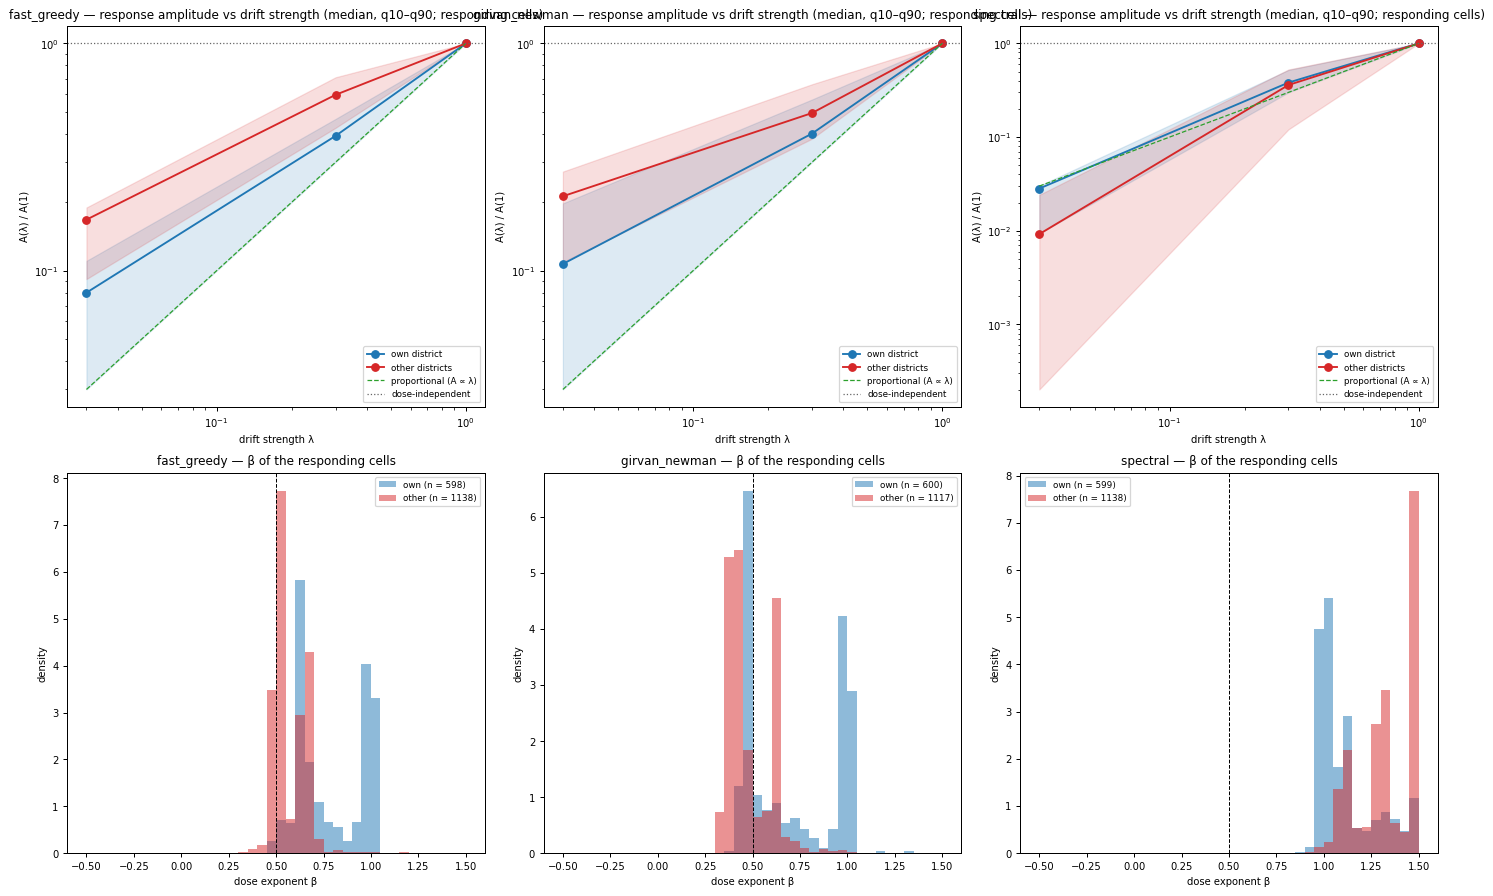

In [12]:
# D. is the response driven by the drift's size? (E7: the same drift at lambda = LAMBDAS and 1)
if not DOSE_OK:
    display(Markdown("**D skipped** (E7 off or a gate failed)."))
else:
    resp = LF[(LF["S"] >= FLOOR["S"]) | (LF["Nr"] >= FLOOR["Nr"])].copy()
    rows = []
    for (m, own, tp_, sto), g in resp.groupby(["districting", "own", "topo", "storage"], dropna=False):
        rows.append({"districting": m, "own": own, "topo": tp_, "storage class": sto, "responding cells": len(g),
                     "median β": g["beta"].median(), f"share β < {BETA_MIN}": float((g["beta"] < BETA_MIN).mean()),
                     "median A(λmin) / (λmin A(1))": g["floor_ratio"].median()})
    for (m, own), g in resp[resp["placed"]].groupby(["districting", "own"]):
        rows.append({"districting": m, "own": own, "topo": "placed", "storage class": "all", "responding cells": len(g),
                     "median β": g["beta"].median(), f"share β < {BETA_MIN}": float((g["beta"] < BETA_MIN).mean()),
                     "median A(λmin) / (λmin A(1))": g["floor_ratio"].median()})
    display(Markdown(f"**Dose exponent of the responding cells** (S ≥ {FLOOR['S']} or Nr ≥ {FLOOR['Nr']}). "
                     "β = slope of log(response amplitude) on log(drift strength); A(λmin)/(λmin·A(1)) = 1 if the response "
                     f"is proportional, 1/λmin = {1 / min(LAMBDAS):.0f} if it does not shrink at all"))
    display(pd.DataFrame(rows).round(3))
    AM = DOSE.pivot_table(index=["districting", "k", "element"], columns="lam", values="amp")
    AM = AM.div(AM[1.0], axis=0)
    AM = resp.join(AM, on=["districting", "k", "element"])
    parts = sorted(resp["districting"].unique())
    fig, axes = plt.subplots(2, len(parts), figsize=(16, 10), squeeze=False)
    lams = sorted(LAMBDAS) + [1.0]
    for j, m in enumerate(parts):
        ax = axes[0, j]
        for own, cc in ((True, "#1f77b4"), (False, "#d62728")):
            q_ = AM[(AM["districting"] == m) & (AM["own"] == own)]
            if not len(q_):
                continue
            Q_ = q_[lams].to_numpy(float)
            ax.plot(lams, np.nanmedian(Q_, 0), marker="o", color=cc, label="own district" if own else "other districts")
            ax.fill_between(lams, np.nanquantile(Q_, 0.1, 0), np.nanquantile(Q_, 0.9, 0), color=cc, alpha=0.15)
        ax.plot(lams, lams, color="#2ca02c", ls="--", lw=1, label="proportional (A ∝ λ)")
        ax.axhline(1, color="0.4", ls=":", lw=1, label="dose-independent")
        ax.set(xscale="log", yscale="log", xlabel="drift strength λ", ylabel="A(λ) / A(1)",
               title=f"{m} — response amplitude vs drift strength (median, q10–q90; responding cells)")
        ax.legend(fontsize=7)
        ax = axes[1, j]
        for own, cc in ((True, "#1f77b4"), (False, "#d62728")):
            q_ = resp[(resp["districting"] == m) & (resp["own"] == own)]["beta"].dropna().clip(-0.5, 1.5)
            ax.hist(q_, bins=np.linspace(-0.5, 1.5, 41), alpha=0.5, color=cc, density=True,
                    label=f"{'own' if own else 'other'} (n = {len(q_)})")
        ax.axvline(BETA_MIN, color="k", lw=0.8, ls="--")
        ax.set(xlabel="dose exponent β", ylabel="density", title=f"{m} — β of the responding cells")
        ax.legend(fontsize=7)
    fig.tight_layout(); plt.show()

## X · Demand / storage split on the real drift (E2, U2)

Per class: the storage share of the response, the interaction (if large, the split is not unique), how much of the shape
effect survives with the hub held, and the study's switch-fit estimator $\sum_p b_{s,p}\gamma_{p,k}$ against the exact
storage channel on the same drift.

**Channels** (links × districts with |g_tot| ≥ 1e-3, final window). storage share = |g_ie0| / (|g_de0| + |g_ie0|); interaction = |g_de1 − g_de0| on the same scale (large: the split is not unique); shape kept = the shape effect left when pumps, valves and tanks are held on their no-drift course; switch-fit = the study's Σ b·γ on this drift

,districting,own,topo,storage class,cells,median storage share,q90 storage share,median interaction,shape kept with hub held (median S_de0 / S),Spearman switch-fit vs exact storage,median |pred - exact| / scale
0,fast_greedy,False,loop,False,133,0.471,0.984,0.021,0.116,0.907,0.055
1,fast_greedy,False,loop,True,913,0.650,0.986,0.011,0.072,0.999,0.020
2,fast_greedy,False,source_bridge,True,36,0.919,0.994,0.007,0.013,0.968,0.010
3,fast_greedy,True,branch,False,162,0.000,0.000,0.000,1.000,0.085,0.000
4,fast_greedy,True,loop,False,98,0.024,0.071,0.017,0.989,0.896,0.010
5,fast_greedy,True,loop,True,303,0.451,0.741,0.023,0.158,0.990,0.024
6,fast_greedy,True,source_bridge,False,4,0.000,0.000,0.000,1.000,-1.000,0.000
7,fast_greedy,True,source_bridge,True,12,0.813,0.946,0.012,0.032,0.706,0.014
8,girvan_newman,False,loop,False,164,0.695,0.963,0.009,0.164,0.975,0.038
9,girvan_newman,False,loop,True,826,0.665,0.968,0.009,0.098,0.999,0.018


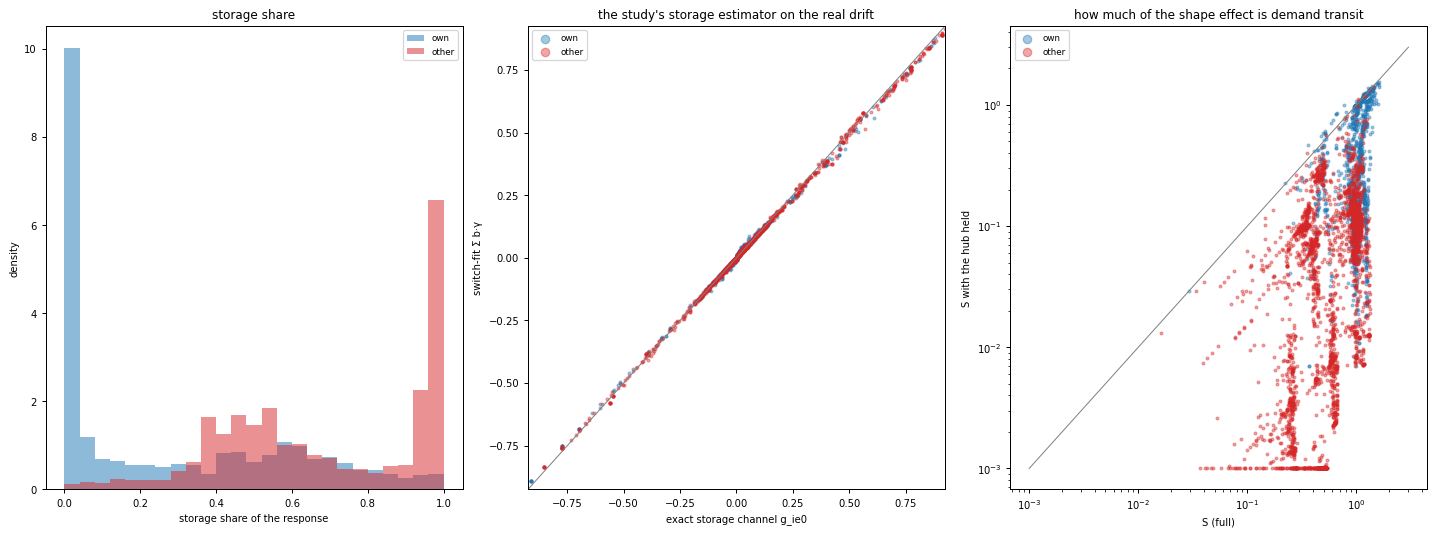

In [13]:
# X. demand / storage split on the real drift (E2, mediators held on the no-drift course)
if not E2_OK:
    display(Markdown("**X skipped** (E2 off or a gate failed)."))
else:
    xs = LF[LF["g_tot"].abs() >= 1e-3].copy()
    xs["S_kept"] = xs["S_de0"] / xs["S"].where(xs["S"] >= FLOOR["S"])
    rows = []
    for (m, own, tp_, sto), g in xs.groupby(["districting", "own", "topo", "storage"], dropna=False):
        ok = g["g_sto_pred"].notna()
        scale = (g["g_de0"].abs() + g["g_ie0"].abs())
        rows.append({"districting": m, "own": own, "topo": tp_, "storage class": sto, "cells": len(g),
                     "median storage share": g["sto_share"].median(), "q90 storage share": g["sto_share"].quantile(0.9),
                     "median interaction": g["interaction"].median(),
                     "shape kept with hub held (median S_de0 / S)": g["S_kept"].median(),
                     "Spearman switch-fit vs exact storage": spear(g[ok]["g_sto_pred"], g[ok]["g_ie0"]),
                     "median |pred - exact| / scale": float(((g[ok]["g_sto_pred"] - g[ok]["g_ie0"]).abs() / scale[ok]).median())})
    display(Markdown("**Channels** (links × districts with |g_tot| ≥ 1e-3, final window). storage share = "
                     "|g_ie0| / (|g_de0| + |g_ie0|); interaction = |g_de1 − g_de0| on the same scale (large: the split is "
                     "not unique); shape kept = the shape effect left when pumps, valves and tanks are held on their "
                     "no-drift course; switch-fit = the study's Σ b·γ on this drift"))
    XT = pd.DataFrame(rows)
    XT.to_parquet(OUT / "e2_summary.parquet", index=False)
    display(XT.round(3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    for own, cc in ((True, "#1f77b4"), (False, "#d62728")):
        q_ = xs[xs["own"] == own]
        axes[0].hist(q_["sto_share"].dropna(), bins=np.linspace(0, 1, 26), alpha=0.5, color=cc, density=True,
                     label="own" if own else "other")
        axes[1].scatter(q_["g_ie0"], q_["g_sto_pred"], s=5, alpha=0.4, color=cc, label="own" if own else "other")
        axes[2].scatter(q_["S"].clip(1e-3), q_["S_de0"].clip(1e-3), s=5, alpha=0.4, color=cc, label="own" if own else "other")
    lim = np.nanpercentile(np.abs(xs[["g_ie0", "g_sto_pred"]].to_numpy(float)), 99)
    axes[1].plot([-lim, lim], [-lim, lim], color="0.5", lw=0.8)
    axes[1].set(xlim=(-lim, lim), ylim=(-lim, lim), xlabel="exact storage channel g_ie0", ylabel="switch-fit Σ b·γ",
                title="the study's storage estimator on the real drift")
    axes[2].plot([1e-3, 3], [1e-3, 3], color="0.5", lw=0.8)
    axes[2].set(xscale="log", yscale="log", xlabel="S (full)", ylabel="S with the hub held",
                title="how much of the shape effect is demand transit")
    axes[0].set(xlabel="storage share of the response", ylabel="density", title="storage share")
    for ax in axes:
        ax.legend(fontsize=7, markerscale=3)
    fig.tight_layout(); plt.show()

## M · Composition as a mixture descriptor (E1)

**Quality:** gates G-E1a/b above (exact on branches, rows sum to 1, unaccounted water reported). **M1:** how mixed each
sensor's water is (own share, effective number of districts $e^{H}$, districts holding ≥ `M_FLOOR`) and the placed
sensors' composition. **M2:** stability — hour-of-week swing of the home share (alternation) and init vs later-window
composition. **M3:** power — does carrying $k$'s water ($m_k$), or its change under $k$'s drift ($\Delta m_k$), predict the
exact dependence on $k$?

**M1 · How mixed is each sensor's water?** (no-drift city, init window) — share of its own district, effective number of districts $e^{H}$, districts holding ≥ 5%

links  m_home_med  m_home_q10  n_eff_med  mixed_share  storage_water_med
districting   topo          storage                                                                          
fast_greedy   branch        False      165       1.000       1.000      1.000        0.000              0.000
              loop          False      103       0.988       0.665      1.049        0.252              0.027
                            True       318       0.479       0.215      2.528        0.931              0.445
              source_bridge False        5       1.000       1.000      1.000        0.000              0.507
                            True        12       0.205       0.202      3.926        1.000              0.495
girvan_newman branch        False      165       1.000       1.000      1.000        0.000              0.000
              loop          False      119       0.979       0.504      1.116        0.387              0.108
                            True       302       0.497       0.274      2.557        0.924              0.427
              source_bridge False        5       1.000       1.000      1.000        0.000              0.481
                            True        12       0.236       0.232      3.672        1.000              0.480
spectral      branch        False      165       1.000       1.000      1.000        0.000              0.000
              loop          False      110       0.973       0.676      1.136        0.364              0.104
                            True       311       0.541       0.221      2.492        0.961              0.424
              source_bridge False        5       1.000       1.000      1.000        0.000              0.478
                            True        12       0.087       0.081      3.645        1.000              0.473

placed sensors

,sensors,m_home_med,n_eff_med,mixed
districting,,,,
fast_greedy,16,0.971251,1.148571,7
girvan_newman,16,0.991088,1.047627,7
spectral,16,1.000000,1.000000,6


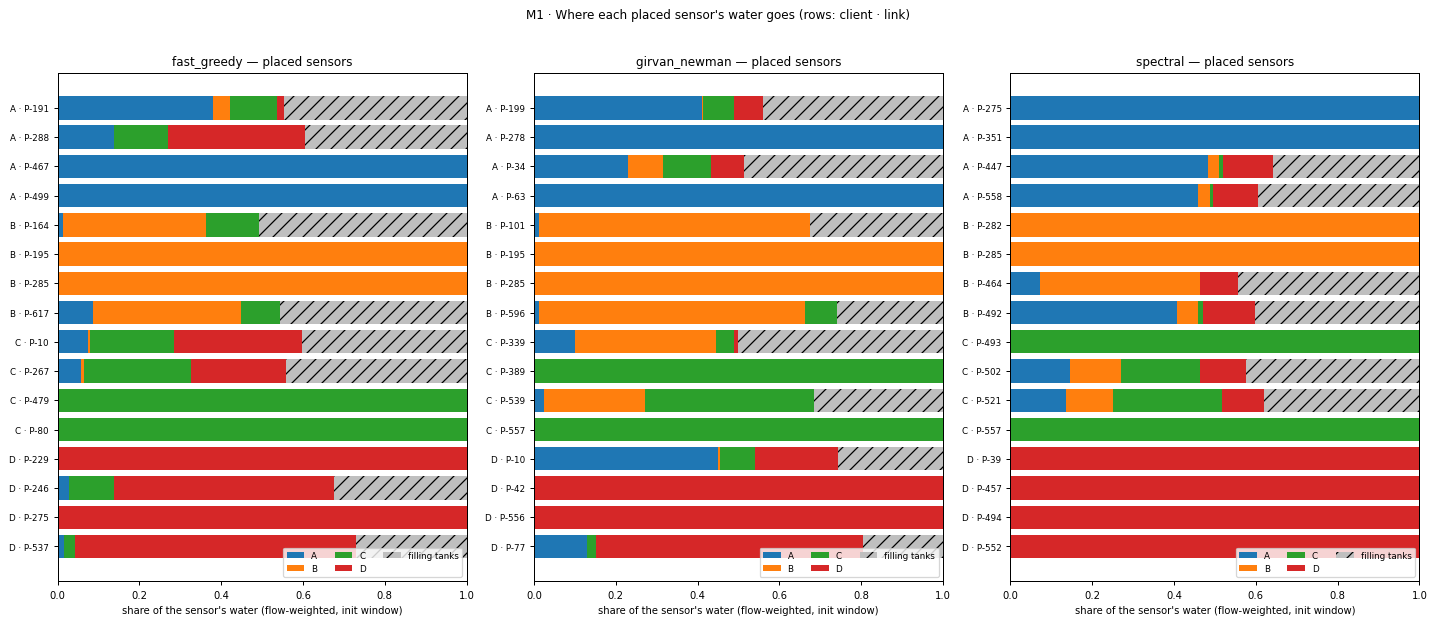

**M2 · Is the descriptor stable?** Hour-of-week swing of the home share (placed sensors: 0 = the same mix every hour, ≈1 = the pipe alternates between own and foreign water) and the change of the no-drift composition between the init window and a later window (½‖Δm‖₁; the city is stationary, so this measures how window-dependent the descriptor is)

,count,50%,90%,max
districting,,,,
fast_greedy,16.0,0.160,0.971,0.993
girvan_newman,16.0,0.151,0.910,0.997
spectral,16.0,0.000,0.966,0.987


,50%,90%,99%,max
districting,,,,
fast_greedy,0.0002,0.0026,0.0043,0.4548
girvan_newman,0.0006,0.0032,0.0049,0.0705
spectral,0.0005,0.0023,0.0041,0.3510


**M3 · Power: does the composition tell which drifts a sensor depends on?** (off-diagonal, final window; m_k = share of k's demand in the sensor's water without drift; Δm_k = its change under k's drift)

,districting,response,AUC m_k,P(responds | m_k ≥ 0.05),P(responds | m_k < 0.01),share of responding cells with m_k < 0.01,Spearman m_k vs S,Spearman |Δm_k| vs S
0,fast_greedy,S ≥ 0.25,0.969,0.990,0.312,0.266,0.698,0.711
1,fast_greedy,Nr ≥ 0.05,0.940,0.917,0.212,0.211,0.698,0.711
2,girvan_newman,S ≥ 0.25,0.900,0.889,0.206,0.204,0.741,0.783
3,girvan_newman,Nr ≥ 0.05,0.936,0.907,0.203,0.192,0.741,0.783
4,spectral,S ≥ 0.25,0.962,0.984,0.219,0.176,0.807,0.860
5,spectral,Nr ≥ 0.05,0.924,0.930,0.192,0.166,0.807,0.860


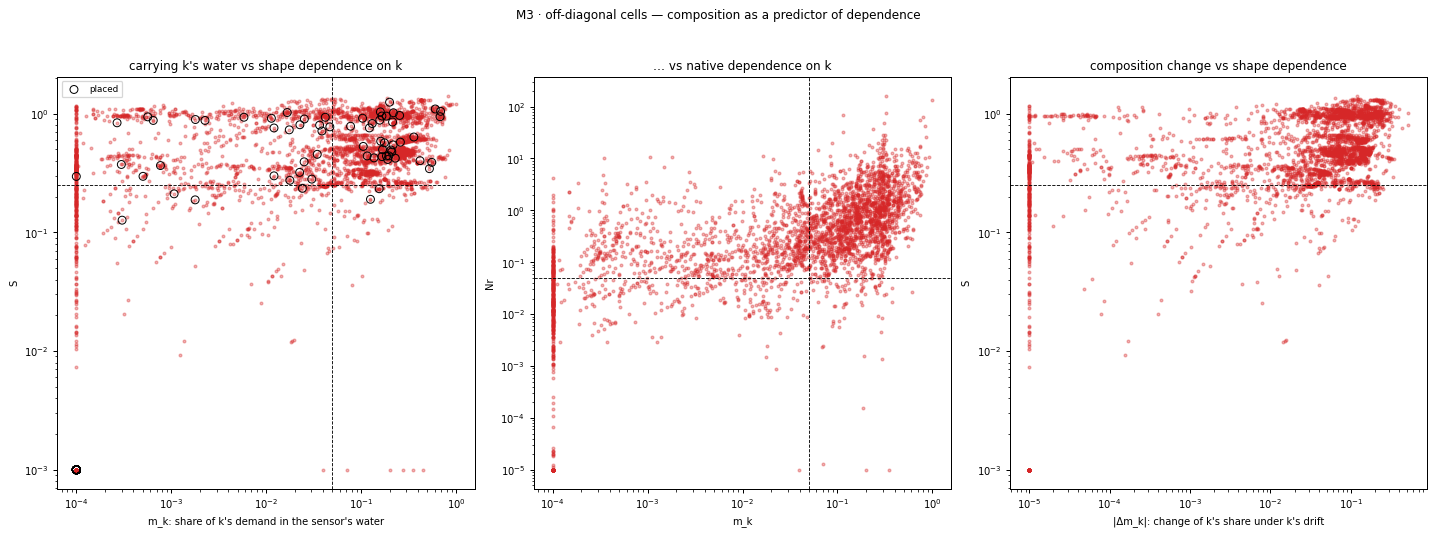

In [14]:
# M. composition (E1): whose water passes each sensor — quality and power of the mixture descriptor
if not E1_OK:
    display(Markdown("**M skipped** (E1 off or a gate failed)."))
else:
    base = E1L[(E1L["world"] == "no-drift") & (E1L["window"] == "init")].copy()
    base["topo"] = base["element"].map(tp).fillna("other")
    base["home"] = [home_of(m).get(e) for m, e in zip(base["districting"], base["element"])]
    base["storage"] = [storage_of(m).get(e, np.nan) for m, e in zip(base["districting"], base["element"])]
    base["placed"] = [e in set(PLACED.get(m, [])) for m, e in zip(base["districting"], base["element"])]
    base = base[base["home"].notna() & (base["volume"] > 0)
                & ~base.apply(lambda r: r["element"] in set(PUMPS.get(r["districting"], [])), axis=1)]
    Mx = base[[f"m_{d}" for d in dists]].to_numpy(float)
    base["m_home"] = [base.at[i, f"m_{h}"] if f"m_{h}" in base.columns else np.nan for i, h in zip(base.index, base["home"])]
    p = np.clip(np.nan_to_num(Mx), 1e-12, 1)
    base["n_eff"] = np.exp(-(p * np.log(p)).sum(axis=1))              # effective number of districts using the water
    base["n_users"] = (np.nan_to_num(Mx) >= M_FLOOR).sum(axis=1)
    display(Markdown(f"**M1 · How mixed is each sensor's water?** (no-drift city, init window) — share of its own "
                     f"district, effective number of districts $e^{{H}}$, districts holding ≥ {M_FLOOR:.0%}"))
    display(base.groupby(["districting", "topo", "storage"], dropna=False).agg(
        links=("element", "size"), m_home_med=("m_home", "median"), m_home_q10=("m_home", lambda x: x.quantile(0.1)),
        n_eff_med=("n_eff", "median"), mixed_share=("n_users", lambda x: (x >= 2).mean()),
        storage_water_med=("storage_water", "median")).round(3))
    display(Markdown("placed sensors"))
    display(base[base["placed"]].groupby("districting").agg(
        sensors=("element", "size"), m_home_med=("m_home", "median"), n_eff_med=("n_eff", "median"),
        mixed=("n_users", lambda x: int((x >= 2).sum()))))

    parts = sorted(base["districting"].unique())
    fig, axes = plt.subplots(1, len(parts), figsize=(16, 7), squeeze=False)
    cmap = plt.get_cmap("tab10")
    for j, m in enumerate(parts):
        ax = axes[0, j]
        q_ = base[(base["districting"] == m) & base["placed"]].sort_values(["home", "element"])
        y = np.arange(len(q_))
        left = np.zeros(len(q_))
        for i_, d in enumerate(dists):
            v = q_[f"m_{d}"].fillna(0).to_numpy() * (1 - q_["storage_water"].clip(0, 1).to_numpy())
            ax.barh(y, v, left=left, color=cmap(i_), label=d.replace("District_", ""))
            left += v
        ax.barh(y, q_["storage_water"].clip(0, 1).to_numpy(), left=left, color="0.75", hatch="//", label="filling tanks")
        ax.set_yticks(y, [f"{h.replace('District_', '')} · {e}" for h, e in zip(q_["home"], q_["element"])], fontsize=7)
        ax.invert_yaxis()
        ax.set(xlim=(0, 1), xlabel="share of the sensor's water (flow-weighted, init window)", title=f"{m} — placed sensors")
        ax.legend(fontsize=7, ncol=3, loc="lower right")
    fig.suptitle("M1 · Where each placed sensor's water goes (rows: client · link)")
    fig.tight_layout(rect=(0, 0, 1, 0.96)); plt.show()

    # M2: does the composition stay put? hour-of-week swing (alternation) and init vs final windows (stationarity)
    sw_rows = []
    for f in sorted(SERIES.glob("*__e1_nodrift_init.npz")):
        m = f.name.split("__")[0]
        z = np.load(f)
        dests = list(z["dests"])
        for jj, e in enumerate(z["links"]):
            h = home_of(m).get(str(e))
            if h in dests:
                sh = z["how"][jj][:, dests.index(h)]
                dsum = np.nansum(z["how"][jj][:, [dests.index(d) for d in dists if d in dests]], axis=1)
                hs = sh / np.where(dsum > 0, dsum, np.nan)
                sw_rows.append({"districting": m, "element": str(e), "home share q05": np.nanquantile(hs, 0.05),
                                "home share q95": np.nanquantile(hs, 0.95), "swing": np.nanquantile(hs, 0.95) - np.nanquantile(hs, 0.05)})
    SW_ = pd.DataFrame(sw_rows)
    nd = E1L[(E1L["world"] == "no-drift")].copy()
    i_ = nd[nd["window"] == "init"].set_index(["districting", "element"])[[f"m_{d}" for d in dists]]
    stat = []
    for (m, k), g in nd[nd["window"] == "final"].groupby(["districting", "k"]):
        gg = g.set_index(["districting", "element"])[[f"m_{d}" for d in dists]]
        common = gg.index.intersection(i_.index)
        L1 = 0.5 * (gg.loc[common] - i_.loc[common]).abs().sum(axis=1)
        stat.append(pd.DataFrame({"districting": m, "k_window": k, "element": [e for _, e in common], "L1 init vs final": L1.to_numpy()}))
    STAT = pd.concat(stat, ignore_index=True) if stat else pd.DataFrame()
    display(Markdown("**M2 · Is the descriptor stable?** Hour-of-week swing of the home share (placed sensors: 0 = the same "
                     "mix every hour, ≈1 = the pipe alternates between own and foreign water) and the change of the "
                     "no-drift composition between the init window and a later window (½‖Δm‖₁; the city is stationary, "
                     "so this measures how window-dependent the descriptor is)"))
    if len(SW_):
        display(SW_.groupby("districting")["swing"].describe(percentiles=[0.5, 0.9])[["count", "50%", "90%", "max"]].round(3))
    if len(STAT):
        display(STAT.groupby("districting")["L1 init vs final"].describe(percentiles=[0.5, 0.9, 0.99])[["50%", "90%", "99%", "max"]].round(4))

    # M3: power — does carrying k's water predict depending on k?
    xo = LF[~LF["own"]].dropna(subset=["m_k"])
    rows = []
    for m, g in xo.groupby("districting"):
        for lab, resp in ((f"S ≥ {FLOOR['S']}", g["S"] >= FLOOR["S"]), (f"Nr ≥ {FLOOR['Nr']}", g["Nr"] >= FLOOR["Nr"])):
            rows.append({"districting": m, "response": lab, "AUC m_k": auc(g[resp]["m_k"], g[~resp]["m_k"]),
                         f"P(responds | m_k ≥ {M_FLOOR})": float(resp[g["m_k"] >= M_FLOOR].mean()) if (g["m_k"] >= M_FLOOR).any() else np.nan,
                         "P(responds | m_k < 0.01)": float(resp[g["m_k"] < 0.01].mean()) if (g["m_k"] < 0.01).any() else np.nan,
                         "share of responding cells with m_k < 0.01": float((g[resp]["m_k"] < 0.01).mean()) if resp.any() else np.nan,
                         "Spearman m_k vs S": spear(g["m_k"], g["S"]), "Spearman |Δm_k| vs S": spear(g["dm_k"].abs(), g["S"])})
    display(Markdown("**M3 · Power: does the composition tell which drifts a sensor depends on?** (off-diagonal, final "
                     "window; m_k = share of k's demand in the sensor's water without drift; Δm_k = its change under k's drift)"))
    display(pd.DataFrame(rows).round(3))
    fig, axes = plt.subplots(1, 3, figsize=(16, 6))
    for own, cc in ((False, "#d62728"),):
        axes[0].scatter(xo["m_k"].clip(1e-4), xo["S"].clip(1e-3), s=5, alpha=0.35, color=cc)
        axes[1].scatter(xo["m_k"].clip(1e-4), xo["Nr"].clip(1e-5), s=5, alpha=0.35, color=cc)
        axes[2].scatter(xo["dm_k"].abs().clip(1e-5), xo["S"].clip(1e-3), s=5, alpha=0.35, color=cc)
    pl = xo[xo["placed"]]
    axes[0].scatter(pl["m_k"].clip(1e-4), pl["S"].clip(1e-3), s=40, facecolors="none", edgecolors="k", lw=0.8, label="placed")
    axes[0].set(xscale="log", yscale="log", xlabel="m_k: share of k's demand in the sensor's water", ylabel="S",
                title="carrying k's water vs shape dependence on k")
    axes[1].set(xscale="log", yscale="log", xlabel="m_k", ylabel="Nr", title="… vs native dependence on k")
    axes[2].set(xscale="log", yscale="log", xlabel="|Δm_k|: change of k's share under k's drift", ylabel="S",
                title="composition change vs shape dependence")
    for ax in axes[:2]:
        ax.axvline(M_FLOOR, color="k", lw=0.7, ls="--")
    for ax in axes:
        ax.axhline(FLOOR["S"] if ax is not axes[1] else FLOOR["Nr"], color="k", lw=0.7, ls="--")
    axes[0].legend(fontsize=7)
    fig.suptitle("M3 · off-diagonal cells — composition as a predictor of dependence")
    fig.tight_layout(rect=(0, 0, 1, 0.95)); plt.show()

## T · The target labels

Placed sensors (pumps excluded) × drifting district: Nr and S over init / transition / final, and the final β, storage
share and composition; then S and N month by month.

## Files

`labels` (everything per link × district × period), `matrix`, `sensitivity`, `gt_link`, `gt_monthly`, `e7_dose`,
`e2_link`, `e2_summary`, `e1_composition`, `branch_carries`, gates (`gt_gate`, `gt_splice`, `gt_branch`, `e7_gate`,
`e2_gate`, `e1_gate`, `e2_mediators`, `runs`), and `series/*.npz` (placed sensors: hourly flow, pumps, demand,
reduced-dose runs, blocked twins, hour-of-week composition).

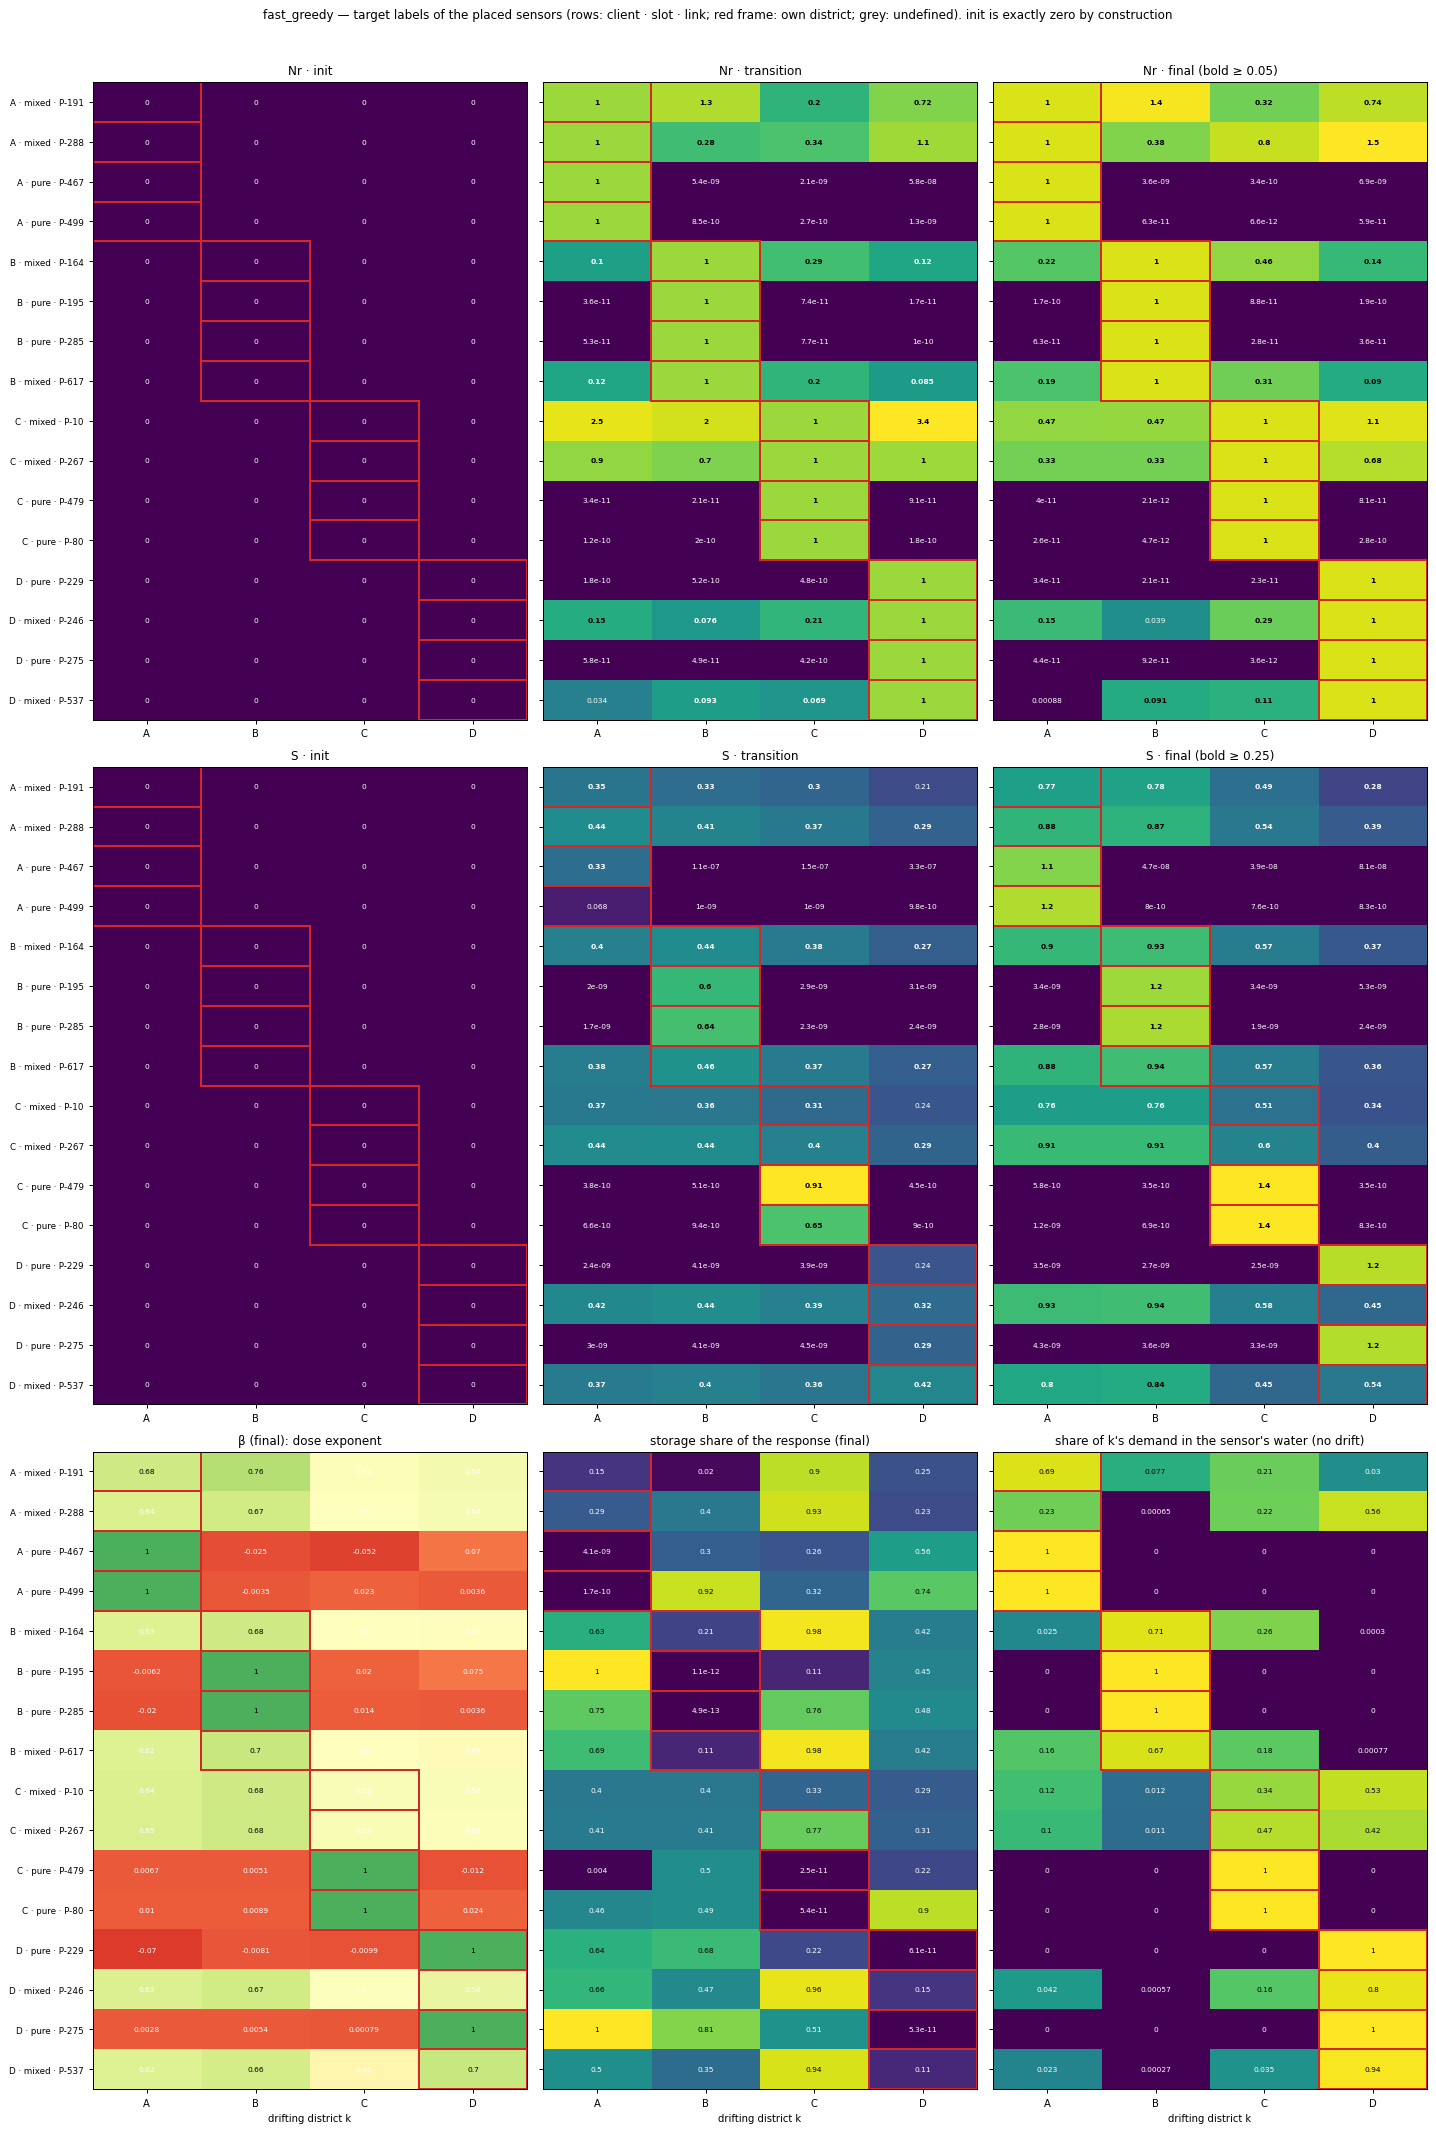

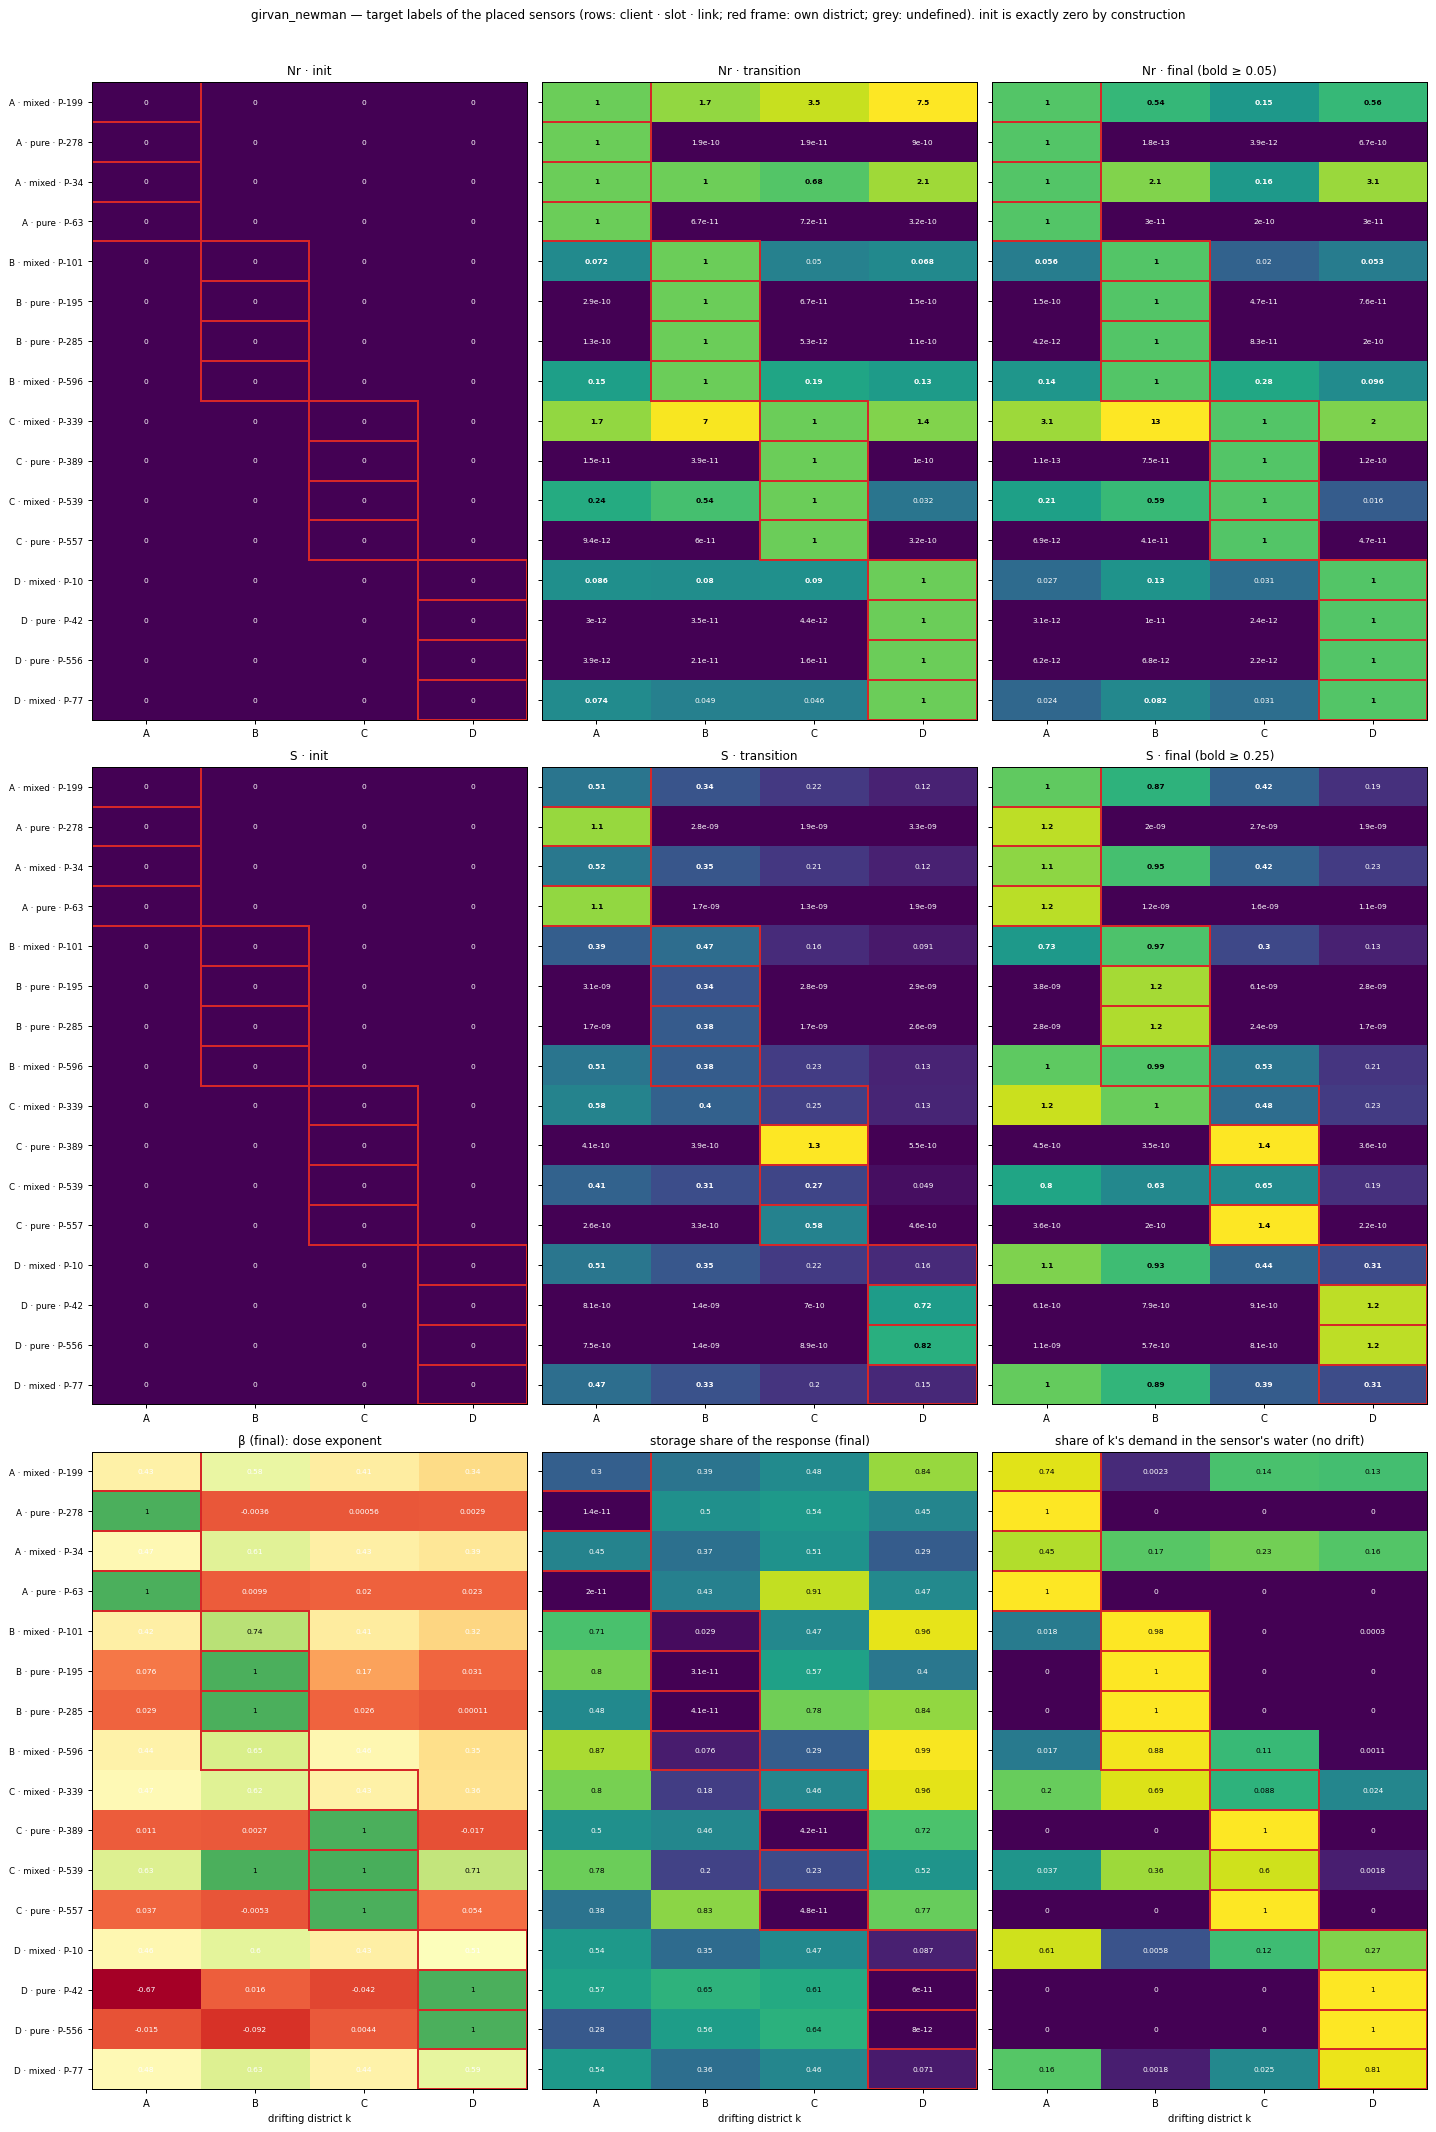

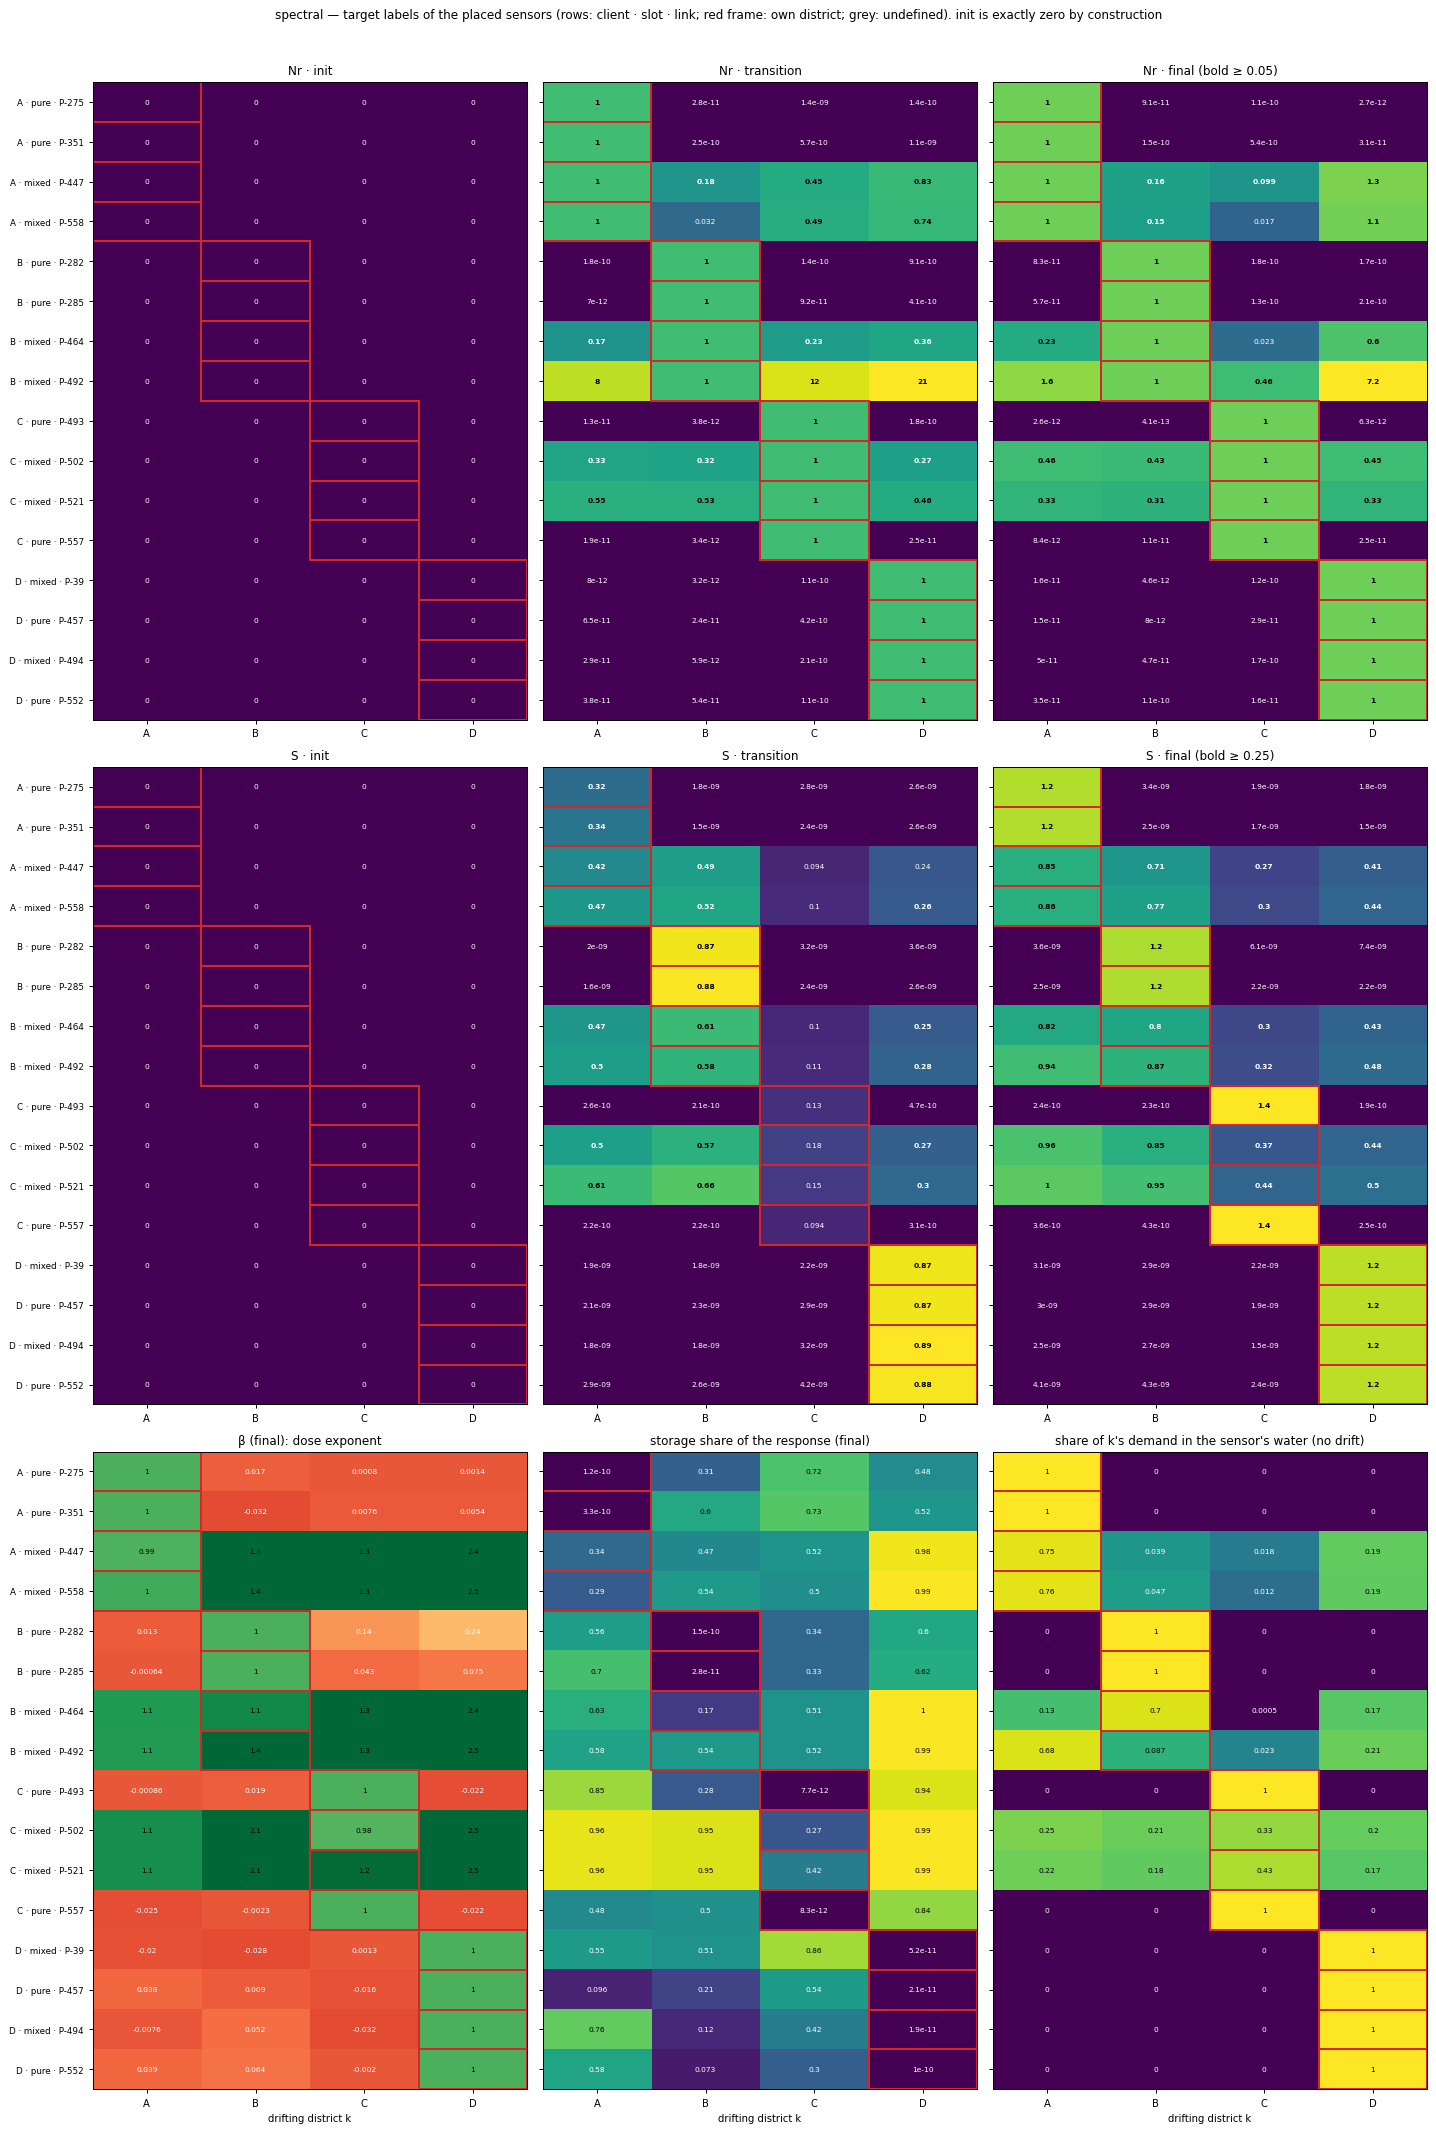

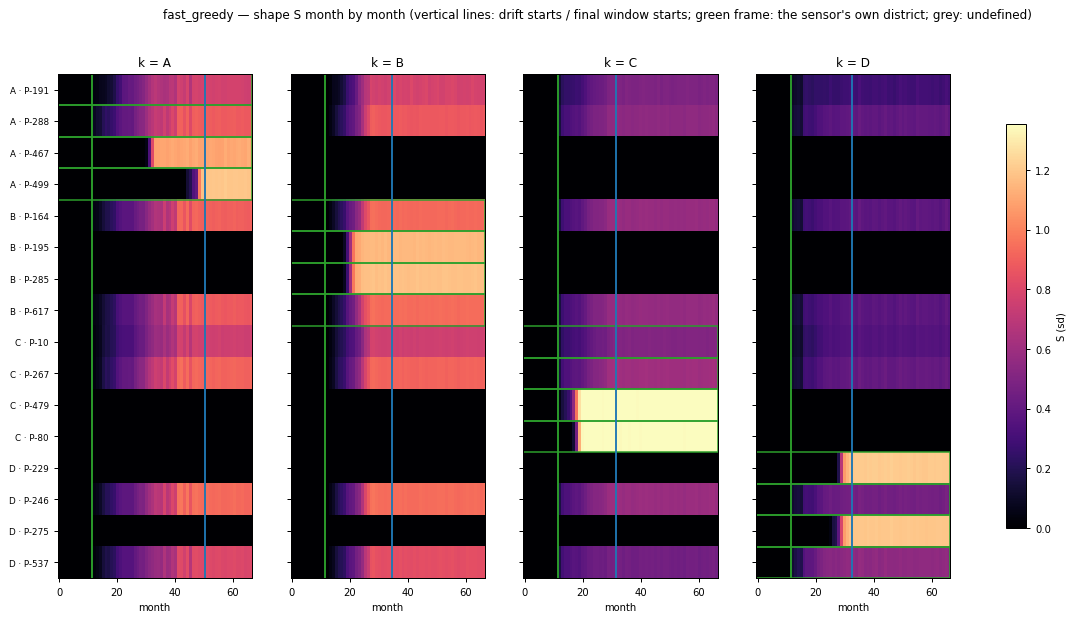

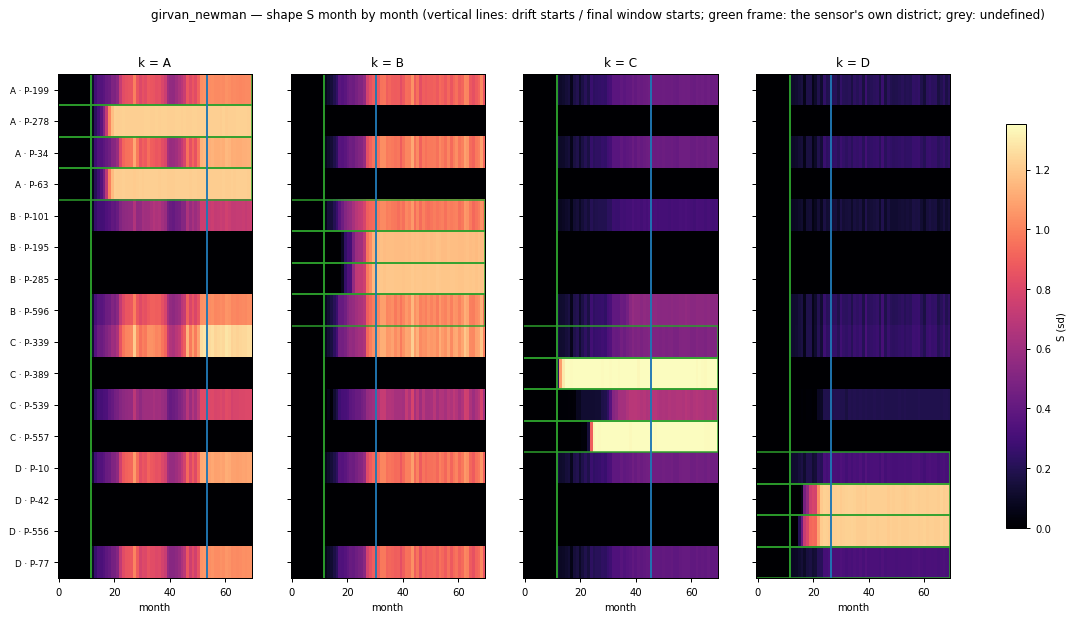

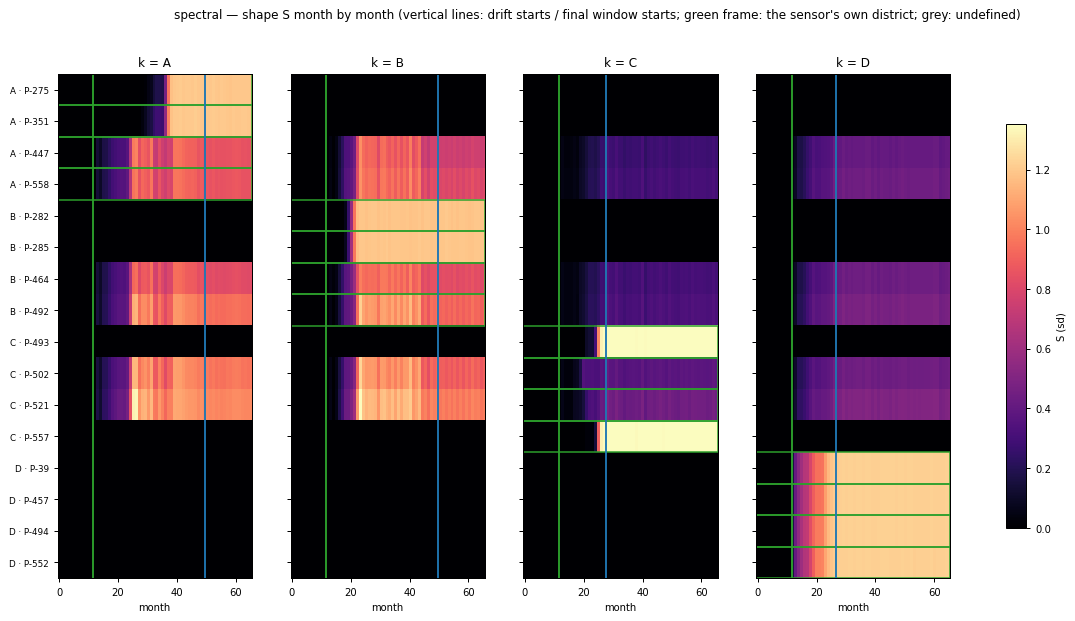

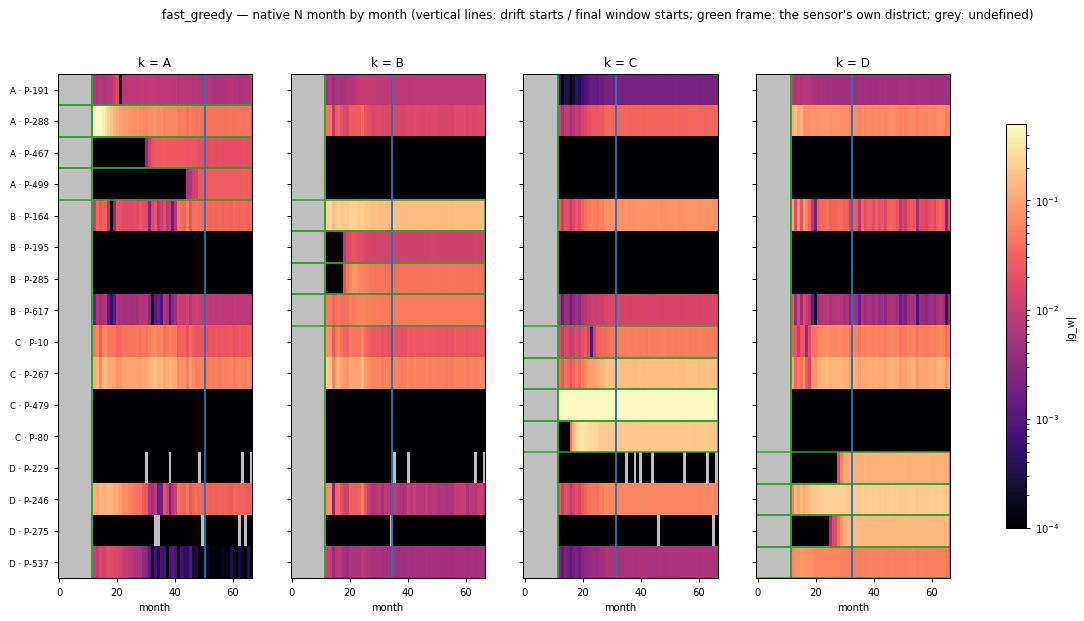

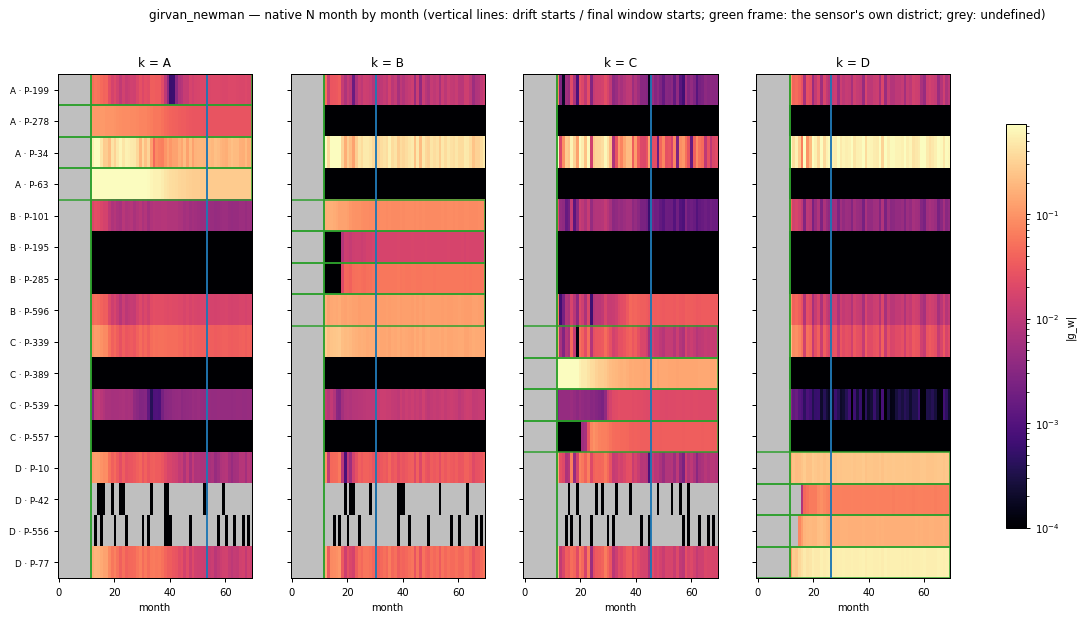

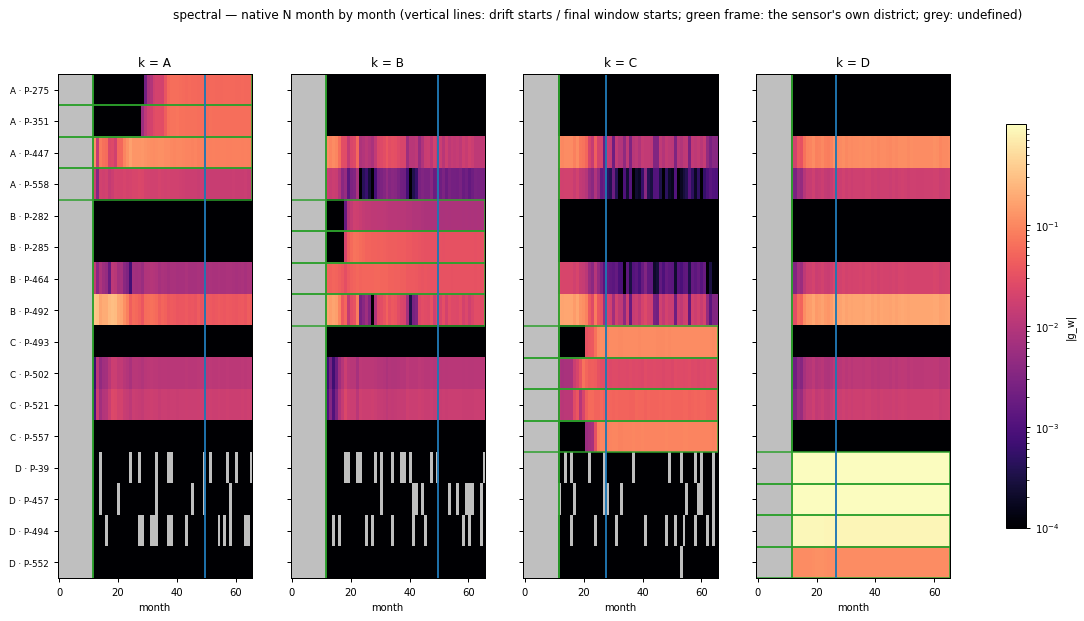

In [15]:
# T. the target labels of the placed sensors (pumps excluded): over init / transition / final, and month by month
TL = LB[LB["placed"]]
slot = PLC.assign(element=PLC["element"].astype(str)).drop_duplicates(["districting", "element"]).set_index(
    ["districting", "element"])["slot_class"]
ROWS = [("Nr", "period"), ("S", "period")]
FIN = [c for c, on in (("beta", DOSE_OK), ("sto_share", E2_OK), ("m_k", E1_OK)) if on]
NORM = {"Nr": lambda v: LogNorm(vmin=1e-3, vmax=max(np.nanmax(v), 1.0)),
        "S": lambda v: plt.Normalize(vmin=0, vmax=max(np.nanmax(v), 0.5)),
        "beta": lambda v: plt.Normalize(vmin=-0.25, vmax=1.25), "sto_share": lambda v: plt.Normalize(0, 1),
        "m_k": lambda v: LogNorm(vmin=1e-3, vmax=1.0)}
TITLE = {"beta": "β (final): dose exponent", "sto_share": "storage share of the response (final)",
         "m_k": "share of k's demand in the sensor's water (no drift)"}


def draw(ax, A, x, ks, hm, show_y, ylab):
    V = A.to_numpy(float)
    finite = V[np.isfinite(V)]
    nrm = NORM[x](finite if len(finite) else np.array([1.0]))
    lo_ = nrm.vmin
    Vp = np.where(np.isfinite(V), np.maximum(V, lo_), np.nan)
    cm = plt.get_cmap("RdYlGn" if x == "beta" else "viridis").copy(); cm.set_bad("0.88")
    ax.imshow(np.ma.masked_invalid(Vp), aspect="auto", cmap=cm, norm=nrm, interpolation="nearest")
    for (a_, b_), v in np.ndenumerate(V):
        if np.isfinite(v):
            light = nrm(max(v, lo_)) > 0.6
            ax.text(b_, a_, "0" if v == 0 else f"{v:.2g}", ha="center", va="center", fontsize=6,
                    color="k" if light else "w", fontweight="bold" if (x in FLOOR and v >= FLOOR[x]) else "normal")
    for a_, h in enumerate(hm):
        if h in ks:
            ax.add_patch(plt.Rectangle((ks.index(h) - 0.5, a_ - 0.5), 1, 1, fill=False, ec="#d62728", lw=1.6))
    ax.set_xticks(range(len(ks)), [c.replace("District_", "") for c in ks])
    ax.set_yticks(range(len(hm)), ylab if show_y else [], fontsize=7)


for m in sorted(TL["districting"].unique()):
    q_ = TL[TL["districting"] == m]
    rows_ = q_.drop_duplicates("element").sort_values(["home", "element"])
    order_e, hm = list(rows_["element"]), rows_["home"].tolist()
    ylab = [f"{h.replace('District_', '')} · {slot.get((m, e), '?')} · {e}" for h, e in zip(hm, order_e)]
    ks = sorted(q_["k"].unique())
    nr = 2 + (1 if FIN else 0)
    fig, axes = plt.subplots(nr, 3, figsize=(16, 2.5 + 0.9 * len(order_e) * nr / 2), squeeze=False)
    for i, x in enumerate(("Nr", "S")):
        for j, per in enumerate(("init", "transition", "final")):
            A = q_[q_["period"] == per].pivot_table(index="element", columns="k", values=x).reindex(index=order_e, columns=ks)
            draw(axes[i, j], A, x, ks, hm, j == 0, ylab)
            axes[i, j].set_title(f"{x} · {per}" + (f" (bold ≥ {FLOOR[x]:g})" if j == 2 else ""))
    for j in range(3):
        ax = axes[nr - 1, j] if FIN else None
        if FIN and j < len(FIN):
            x = FIN[j]
            A = q_[q_["period"] == "final"].pivot_table(index="element", columns="k", values=x).reindex(index=order_e, columns=ks)
            draw(ax, A, x, ks, hm, j == 0, ylab)
            ax.set_title(TITLE[x]); ax.set_xlabel("drifting district k")
        elif FIN:
            ax.axis("off")
    fig.suptitle(f"{m} — target labels of the placed sensors (rows: client · slot · link; red frame: own district; grey: "
                 "undefined). init is exactly zero by construction")
    fig.tight_layout(rect=(0, 0, 1, 0.97)); plt.show()

# month by month
for x, col in (("S", "SE"), ("N", "g_w")):
    for m in sorted(E5M["districting"].unique()):
        q_ = E5M[E5M["districting"] == m].merge(TL[["districting", "element", "home"]].drop_duplicates(),
                                               on=["districting", "element"])
        if not len(q_):
            continue
        order_e = list(q_.drop_duplicates("element").sort_values(["home", "element"])["element"])
        hm_ = q_.drop_duplicates("element").set_index("element")["home"]
        ks = sorted(q_["k"].unique())
        vals = q_[col].abs()
        vmax = float(np.nanquantile(vals, 0.99)) if vals.notna().any() else 1.0
        fig, axes = plt.subplots(1, len(ks), figsize=(16, 2 + 0.33 * len(order_e)), squeeze=False, sharey=True)
        cm = plt.get_cmap("magma").copy(); cm.set_bad("0.75")
        for j, k in enumerate(ks):
            ax = axes[0, j]
            A = q_[q_["k"] == k].assign(v=lambda d: d[col].abs()).pivot_table(
                index="element", columns="month", values="v").reindex(order_e)
            im = ax.imshow(np.ma.masked_invalid(A.to_numpy(float)), aspect="auto", cmap=cm, interpolation="nearest",
                           norm=LogNorm(vmin=1e-4, vmax=max(vmax, 1e-3)) if x == "N" else plt.Normalize(0, vmax))
            for a_, e in enumerate(order_e):
                if hm_.get(e) == k:
                    ax.add_patch(plt.Rectangle((-0.5, a_ - 0.5), A.shape[1], 1, fill=False, ec="#2ca02c", lw=1.2))
            per = PERIOD_OF.get((m, k))
            if per:
                sm_ = int(ATLAS.world(WORLDS[WORLDS["districting"] == m].iloc[0]["sim_hash"]).params["time"]["days_per_month"]) * 24
                for edge, c in ((per["transition"][0] / sm_, "#2ca02c"), (per["final"][0] / sm_, "#1f77b4")):
                    ax.axvline(edge - 0.5, color=c, lw=1.5)
            ax.set(title=f"k = {k.replace('District_', '')}", xlabel="month")
            if j == 0:
                ax.set_yticks(range(len(order_e)), [f"{hm_[e].replace('District_', '')} · {e}" for e in order_e], fontsize=7)
        fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label=("|g_w|" if x == "N" else "S (sd)"))
        fig.suptitle(f"{m} — {('shape S' if x == 'S' else 'native N')} month by month (vertical lines: drift starts / final "
                     "window starts; green frame: the sensor's own district; grey: undefined)")
        plt.show()